# Scoring multifuente para priorización de licitaciones — Los Tilos

**Trabajo Final de Máster (TFM)**  
**Objetivo:** priorizar licitaciones candidatas según su compatibilidad documental, semántica y estructurada con la experiencia histórica de Los Tilos.

Este notebook implementa un modelo de recomendación no supervisado basado en:

1. **Score base interpretable**, construido con variables estructuradas, evidencia documental y similitud textual.
2. **Embeddings multilingües**, para representar semánticamente los textos de cada licitación.
3. **kNN semántico no supervisado**, para recuperar licitaciones históricas similares.
4. **Novelty score**, como lectura inversa de la similitud semántica frente al histórico.
5. **Ranking final**, combinando score base y evidencia semántica.

> El resultado no debe interpretarse como probabilidad de adjudicación. Es un sistema de priorización para apoyar revisión humana.


## 0. Criterio metodológico

El problema se formula como un caso de **priorización documental y semántica de licitaciones**. No se dispone de una etiqueta supervisada confiable que indique si una licitación debe ser aceptada o rechazada; por tanto, no se entrena un clasificador supervisado.

La estrategia utilizada es:

| Bloque | Método | Propósito |
|---|---|---|
| Score base | Reglas y ponderaciones interpretables | Medir compatibilidad por variables observables |
| Similitud textual | TF-IDF + coseno | Comparar texto consolidado candidato vs histórico |
| Embeddings | Sentence Transformers multilingüe | Capturar similitud semántica no estrictamente literal |
| kNN semántico | Vecinos más cercanos con distancia coseno | Recuperar históricos similares de Los Tilos |
| Novelty score | 1 - similitud top-3 | Medir distancia semántica frente al histórico |

Se evaluó clustering como alternativa no supervisada, pero se descartó para el modelo final porque no generó agrupamientos temáticos útiles para las licitaciones candidatas y tendía a separar registros afectados por errores de extracción documental.


In [ ]:


from __future__ import annotations

from pathlib import Path
import json
import re
import unicodedata
import warnings
from typing import Iterable

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 180)
pd.set_option("display.width", 180)

In [2]:
# ===============================
# 2. Rutas del proyecto
# ===============================

# El notebook normalmente está dentro de la carpeta Notebooks.
# Por eso BASE_DIR sube un nivel a la raíz del proyecto.
BASE_DIR = Path("..").resolve()
SILVER_DIR = BASE_DIR / "data" / "Silver"

PATH_MUESTRA = SILVER_DIR / "muestra_20_segovia_18_madrid_2_restantes.parquet"
PATH_MADRID_SECCIONES = SILVER_DIR / "madrid_18_html_secciones.parquet"
PATH_CASTILLA_LEON = SILVER_DIR / "castilla_leon_html_info.parquet"

PATH_INDICE_TILOS = SILVER_DIR / "00_Indice_Licitaciones.xlsx"

# El inventario puede estar en Excel, parquet o CSV. Se busca por prefijo.
INVENTARIO_PATTERN = "Inventario_Documentos_Licitaciones_Los_Tilos*"

# Carpetas documentales.
PATH_DOCS_MADRID = SILVER_DIR / "documentos_madrid"
PATH_DOCS_TILOS = SILVER_DIR / "Licitaciones"

OUTPUT_PARQUET = SILVER_DIR / "scoring_multifuente_v4_presentacion_licitaciones_tilos.parquet"
OUTPUT_EXCEL = SILVER_DIR / "scoring_multifuente_v4_presentacion_licitaciones_tilos.xlsx"

# Caché para no releer PDFs cada vez.
CACHE_DIR = SILVER_DIR / "_cache_scoring"
CACHE_DOCS_MADRID = CACHE_DIR / "documentos_madrid_textos.parquet"
CACHE_DOCS_TILOS = CACHE_DIR / "documentos_tilos_textos.parquet"

# Cambiar a True solo si quieres obligar a releer todos los documentos.
FORZAR_RELECTURA_DOCUMENTOS = False

paths_to_check = {
    "Silver": SILVER_DIR,
    "muestra": PATH_MUESTRA,
    "madrid_secciones": PATH_MADRID_SECCIONES,
    "castilla_leon": PATH_CASTILLA_LEON,
    "indice_tilos": PATH_INDICE_TILOS,
    "docs_madrid": PATH_DOCS_MADRID,
    "docs_tilos": PATH_DOCS_TILOS,
    "cache_dir": CACHE_DIR,
}

print("BASE_DIR:", BASE_DIR)
for name, path in paths_to_check.items():
    print(f"{name:18s} | existe={path.exists()} | {path}")

inventarios = sorted(SILVER_DIR.glob(INVENTARIO_PATTERN)) if SILVER_DIR.exists() else []
print("Inventarios encontrados:", [p.name for p in inventarios])

BASE_DIR: C:\Users\Usuario\TFM\TFM_scraping_contratacion_estado
Silver             | existe=True | C:\Users\Usuario\TFM\TFM_scraping_contratacion_estado\data\Silver
muestra            | existe=True | C:\Users\Usuario\TFM\TFM_scraping_contratacion_estado\data\Silver\muestra_20_segovia_18_madrid_2_restantes.parquet
madrid_secciones   | existe=True | C:\Users\Usuario\TFM\TFM_scraping_contratacion_estado\data\Silver\madrid_18_html_secciones.parquet
castilla_leon      | existe=True | C:\Users\Usuario\TFM\TFM_scraping_contratacion_estado\data\Silver\castilla_leon_html_info.parquet
indice_tilos       | existe=True | C:\Users\Usuario\TFM\TFM_scraping_contratacion_estado\data\Silver\00_Indice_Licitaciones.xlsx
docs_madrid        | existe=True | C:\Users\Usuario\TFM\TFM_scraping_contratacion_estado\data\Silver\documentos_madrid
docs_tilos         | existe=True | C:\Users\Usuario\TFM\TFM_scraping_contratacion_estado\data\Silver\Licitaciones
cache_dir          | existe=True | C:\Users\Usuario\TFM\

## 1. Funciones generales de limpieza y carga

Estas funciones evitan depender de nombres exactos de columnas. Primero se normalizan columnas y luego se detectan equivalencias.

In [3]:
# ===============================
# 3. Limpieza y carga flexible
# ===============================


def remove_accents(value: str) -> str:
    """Elimina acentos de un texto."""
    if pd.isna(value):
        return ""

    normalized = unicodedata.normalize("NFKD", str(value))
    return "".join(char for char in normalized if not unicodedata.combining(char))


def clean_column_name(column: str) -> str:
    """Estandariza nombres de columnas."""
    column = remove_accents(column).lower().strip()
    column = re.sub(r"[^a-z0-9]+", "_", column)
    column = re.sub(r"_+", "_", column).strip("_")
    return column


def clean_text(value) -> str:
    """Limpia texto para comparación semántica simple."""
    if pd.isna(value):
        return ""

    value = remove_accents(str(value)).lower()
    value = re.sub(r"https?://\S+", " ", value)
    value = re.sub(r"[^a-z0-9ñ ]+", " ", value)
    value = re.sub(r"\s+", " ", value).strip()
    return value


def standardize_columns(df: pd.DataFrame) -> pd.DataFrame:
    """Devuelve una copia con columnas normalizadas."""
    df = df.copy()
    df.columns = [clean_column_name(column) for column in df.columns]
    return df


def load_table(path: Path, source_name: str) -> pd.DataFrame:
    """Carga parquet, Excel o CSV y agrega columna de fuente."""
    if not path.exists():
        print(f"No existe {source_name}: {path}")
        return pd.DataFrame()

    suffix = path.suffix.lower()

    if suffix == ".parquet":
        df = pd.read_parquet(path)
    elif suffix in [".xlsx", ".xls"]:
        df = pd.read_excel(path)
    elif suffix == ".csv":
        df = pd.read_csv(path)
    else:
        raise ValueError(f"Extensión no soportada para {path}")

    df = standardize_columns(df)
    df["fuente_origen"] = source_name
    print(f"{source_name:25s} | shape={df.shape} | {path.name}")
    return df


def load_first_matching_table(paths: list[Path], source_name: str) -> pd.DataFrame:
    """Carga el primer archivo existente de una lista."""
    for path in paths:
        if path.exists():
            return load_table(path, source_name)
    print(f"No se encontró archivo para {source_name}")
    return pd.DataFrame()

In [4]:
# ===============================
# 4. Carga de tablas principales
# ===============================

df_muestra_raw = load_table(PATH_MUESTRA, "muestra_20")
df_madrid_raw = load_table(PATH_MADRID_SECCIONES, "madrid_html_secciones")
df_castilla_raw = load_table(PATH_CASTILLA_LEON, "castilla_leon_html")
df_indice_tilos_raw = load_table(PATH_INDICE_TILOS, "indice_tilos")

df_inventario_raw = load_first_matching_table(inventarios, "inventario_tilos")

print("\nColumnas muestra:")
print(df_muestra_raw.columns.tolist())

print("\nColumnas Madrid secciones:")
print(df_madrid_raw.columns.tolist())

print("\nColumnas Castilla y León:")
print(df_castilla_raw.columns.tolist())

print("\nColumnas índice Tilos:")
print(df_indice_tilos_raw.columns.tolist())

print("\nColumnas inventario Tilos:")
print(df_inventario_raw.columns.tolist())


muestra_20                | shape=(20, 44) | muestra_20_segovia_18_madrid_2_restantes.parquet
madrid_html_secciones     | shape=(18, 24) | madrid_18_html_secciones.parquet
castilla_leon_html        | shape=(1, 29) | castilla_leon_html_info.parquet
indice_tilos              | shape=(25, 16) | 00_Indice_Licitaciones.xlsx
inventario_tilos          | shape=(274, 10) | Inventario_Documentos_Licitaciones_Los_Tilos.xlsx

Columnas muestra:
['licitacion_id', 'titulo', 'detail_url', 'updated', 'expediente', 'tipo_contrato_codigo', 'lugar_ejecucion_codigo', 'cpv_codes', 'organo_contratacion', 'estado_codigo', 'fecha_publicacion', 'procedimiento_codigo', 'importe_sin_impuestos', 'fuente_publicacion', 'presentacion_hasta', 'presentacion_hora', 'notice_types', 'organo_dir3', 'contrato_duracion', 'contrato_duracion_unidad', 'ofertas_recibidas', 'adjudicatario', 'adjudicatario_nif', 'estado', 'tipo_contrato', 'url', 'cpv_descripcion', 'cpv_nivel', 'presentacion_hasta_dt', 'fecha_vigente', 'portal', 'd

## 2. Detección de columnas analíticas

El diccionario se puede ajustar si alguna fuente trae nombres distintos. La prioridad es `id_licitacion`, porque es la llave para consolidar las fuentes.

In [5]:
# ===============================
# 5. Detección de columnas equivalentes
# ===============================

COLUMN_CANDIDATES = {
    "id": [
        "id_licitacion", "licitacion_id", "id", "expediente",
        "numero_expediente", "codigo_expediente", "id_expediente",
        "id_licitaciones", "identificador", "cod_expediente",
    ],
    "titulo": [
        "titulo", "title", "nombre", "objeto", "objeto_contrato",
        "objeto_contractual", "descripcion", "denominacion", "resumen",
    ],
    "texto": [
        "texto", "texto_completo", "texto_html", "texto_limpio", "contenido",
        "contenido_html", "secciones_texto", "seccion_texto", "descripcion",
        "objeto", "objeto_contrato", "objeto_contractual", "titulo",
        "cpv_descripcion", "observaciones", "ficha", "informacion_extraida",
    ],
    "actividad": [
        "cpv_descripcion", "descripcion_cpv", "cpv_desc", "descripcion",
        "objeto", "objeto_contrato", "objeto_contractual", "titulo",
        "denominacion", "tipo_servicio", "servicio", "actividad",
    ],
    "cpv": [
        "cpv", "cpv_code", "cpv_codes", "codigo_cpv", "codigos_cpv",
        "clasificacion_cpv", "cpv_principal", "cpv_secundario",
    ],
    "importe": [
        "importe", "importe_sin_impuestos", "valor_estimado", "presupuesto",
        "presupuesto_base", "presupuesto_base_licitacion", "valor_contrato",
        "importe_total", "valor_estimado_contrato", "presupuesto_licitacion",
    ],
    "tipo_contrato": [
        "tipo_contrato", "tipo_de_contrato", "contrato_tipo", "naturaleza",
    ],
    "procedimiento": [
        "procedimiento", "procedimiento_codigo", "tipo_procedimiento",
        "sistema_contratacion", "tramitacion", "forma_adjudicacion",
    ],
    "region": [
        "region", "comunidad_autonoma", "lugar_ejecucion", "lugar_ejecucion_codigo",
        "provincia", "municipio", "localidad", "pais", "ambito_geografico",
    ],
    "organo": [
        "organo_contratacion", "organo", "entidad", "entidad_adjudicadora",
        "poder_adjudicador", "organismo", "contratante", "administracion",
    ],
    "url": [
        "url", "detail_url", "url_detail", "url_detalle", "enlace", "link",
    ],
    "ruta_documento": [
        "ruta", "path", "filepath", "file_path", "ruta_documento",
        "documento_ruta", "archivo", "filename", "nombre_archivo", "file_name",
        "documento", "nombre_documento",
    ],
}


def find_first_existing_column(df: pd.DataFrame, candidates: list[str]) -> str | None:
    """Devuelve la primera columna candidata existente."""
    if df.empty:
        return None

    for column in candidates:
        if column in df.columns:
            return column
    return None


def detect_columns(df: pd.DataFrame) -> dict[str, str | None]:
    """Detecta columnas por rol analítico."""
    return {
        key: find_first_existing_column(df, candidates)
        for key, candidates in COLUMN_CANDIDATES.items()
    }


column_maps = {
    "muestra": detect_columns(df_muestra_raw),
    "madrid": detect_columns(df_madrid_raw),
    "castilla_leon": detect_columns(df_castilla_raw),
    "indice_tilos": detect_columns(df_indice_tilos_raw),
    "inventario_tilos": detect_columns(df_inventario_raw),
}

for name, mapping in column_maps.items():
    print(f"\n{name}")
    for key, value in mapping.items():
        if value is not None:
            print(f"  {key:16s}: {value}")



muestra
  id              : licitacion_id
  titulo          : titulo
  texto           : titulo
  actividad       : cpv_descripcion
  cpv             : cpv_codes
  importe         : importe_sin_impuestos
  tipo_contrato   : tipo_contrato
  procedimiento   : procedimiento_codigo
  region          : lugar_ejecucion_codigo
  organo          : organo_contratacion
  url             : url

madrid
  id              : licitacion_id
  url             : detail_url

castilla_leon
  id              : licitacion_id
  titulo          : descripcion
  texto           : descripcion
  actividad       : descripcion
  cpv             : cpv
  importe         : valor_estimado
  tipo_contrato   : tipo_contrato
  procedimiento   : forma_adjudicacion
  url             : detail_url

indice_tilos
  id              : expediente
  titulo          : descripcion
  texto           : descripcion
  actividad       : descripcion
  importe         : importe
  tipo_contrato   : tipo_de_contrato

inventario_tilos
  organo

In [6]:
# ===============================
# 6. Normalización de identificadores
# ===============================


def normalize_id(value) -> str:
    """Normaliza identificadores para usar como llave."""
    if pd.isna(value):
        return ""

    value = remove_accents(str(value)).strip().lower()
    value = re.sub(r"\s+", "", value)
    value = value.replace("/", "_").replace("\\", "_")
    value = re.sub(r"[^a-z0-9_\-.]+", "", value)
    return value


def ensure_id_column(df: pd.DataFrame, mapping: dict[str, str | None], source_name: str) -> pd.DataFrame:
    """Agrega id_licitacion_norm. Si no hay id, deja vacío y avisa."""
    df = df.copy()
    id_col = mapping.get("id")

    if id_col is None or id_col not in df.columns:
        df["id_licitacion_norm"] = ""
        print(f"ADVERTENCIA: {source_name} no tiene columna id detectada.")
        return df

    df["id_licitacion_norm"] = df[id_col].map(normalize_id)
    n_empty = (df["id_licitacion_norm"] == "").sum()
    print(f"{source_name:25s} | id_col={id_col} | ids vacíos={n_empty} de {len(df)}")
    return df


df_muestra = ensure_id_column(df_muestra_raw, column_maps["muestra"], "muestra")
df_madrid = ensure_id_column(df_madrid_raw, column_maps["madrid"], "madrid")
df_castilla = ensure_id_column(df_castilla_raw, column_maps["castilla_leon"], "castilla_leon")
df_indice_tilos = ensure_id_column(df_indice_tilos_raw, column_maps["indice_tilos"], "indice_tilos")
df_inventario = ensure_id_column(df_inventario_raw, column_maps["inventario_tilos"], "inventario_tilos")


muestra                   | id_col=licitacion_id | ids vacíos=0 de 20
madrid                    | id_col=licitacion_id | ids vacíos=0 de 18
castilla_leon             | id_col=licitacion_id | ids vacíos=0 de 1
indice_tilos              | id_col=expediente | ids vacíos=0 de 25
ADVERTENCIA: inventario_tilos no tiene columna id detectada.


## 3. Consolidación de licitaciones candidatas

Se unen las fuentes de licitaciones por `id_licitacion`. No se descarta información textual: se concatena todo lo disponible por fuente y se conserva el primer valor no vacío para campos estructurados.

In [7]:
# ===============================
# 7. Texto consolidado por fila y agregación por id
# ===============================

TECHNICAL_EXCLUDE_COLUMNS = {
    "fuente_origen", "id_licitacion_norm", "texto_fila", "texto_scoring",
}


def is_useful_text_column(column: str) -> bool:
    """Filtra columnas técnicas o poco útiles para texto."""
    if column in TECHNICAL_EXCLUDE_COLUMNS:
        return False
    if column.startswith("unnamed"):
        return False
    return True


def build_row_text(df: pd.DataFrame) -> pd.Series:
    """Concatena información textual de todas las columnas útiles de una fila."""
    if df.empty:
        return pd.Series(dtype="object")

    selected_columns = [col for col in df.columns if is_useful_text_column(col)]
    return (
        df[selected_columns]
        .fillna("")
        .astype(str)
        .agg(" | ".join, axis=1)
        .map(clean_text)
    )


def first_non_empty(values: Iterable) -> object:
    """Devuelve el primer valor no vacío/no NA."""
    for value in values:
        if pd.notna(value) and str(value).strip() != "":
            return value
    return np.nan


def aggregate_sources_by_id(frames: list[pd.DataFrame]) -> pd.DataFrame:
    """Agrega varias fuentes por id_licitacion_norm."""
    non_empty_frames = [df.copy() for df in frames if not df.empty]

    if not non_empty_frames:
        return pd.DataFrame()

    for df in non_empty_frames:
        df["texto_fila"] = build_row_text(df)

    long_df = pd.concat(non_empty_frames, ignore_index=True, sort=False)
    long_df = long_df[long_df["id_licitacion_norm"].astype(str).str.len() > 0].copy()

    if long_df.empty:
        return pd.DataFrame()

    text_by_id = (
        long_df.groupby("id_licitacion_norm", as_index=False)
        .agg(
            texto_fuentes=("texto_fila", lambda x: clean_text(" ".join(x.dropna().astype(str)))),
            fuentes_utilizadas=("fuente_origen", lambda x: ", ".join(sorted(set(x.dropna().astype(str))))),
        )
    )

    # Para columnas estructuradas, se toma el primer valor no vacío.
    structured_cols = [
        col for col in long_df.columns
        if col not in ["texto_fila", "fuente_origen"]
    ]

    structured = (
        long_df[structured_cols]
        .groupby("id_licitacion_norm", as_index=False)
        .agg(first_non_empty)
    )

    result = structured.merge(text_by_id, on="id_licitacion_norm", how="left")
    return result


df_candidatas = aggregate_sources_by_id([df_muestra, df_madrid, df_castilla])

print("Shape candidatas consolidadas:", df_candidatas.shape)
print("Fuentes usadas:")
print(df_candidatas["fuentes_utilizadas"].value_counts(dropna=False))

display(df_candidatas.head(5))

Shape candidatas consolidadas: (20, 85)
Fuentes usadas:
fuentes_utilizadas
madrid_html_secciones, muestra_20    18
castilla_leon_html, muestra_20        1
muestra_20                            1
Name: count, dtype: int64


,id_licitacion_norm,licitacion_id,titulo,detail_url,updated,expediente,tipo_contrato_codigo,lugar_ejecucion_codigo,cpv_codes,organo_contratacion,estado_codigo,fecha_publicacion,procedimiento_codigo,importe_sin_impuestos,fuente_publicacion,presentacion_hasta,presentacion_hora,notice_types,organo_dir3,contrato_duracion,contrato_duracion_unidad,ofertas_recibidas,adjudicatario,adjudicatario_nif,estado,tipo_contrato,url,cpv_descripcion,cpv_nivel,presentacion_hasta_dt,fecha_vigente,portal,dominio_url,cercania_segovia,orden_prioridad_geo,url_extraccion,url_origen_valida,status_detail_url,status_url,titulo_html_revision,url_final_revision,error_revision,url_ok,orden_no_madrid,url_response,status_code,content_type,titulo_html,n_secciones_encontradas,n_documentos_detectados,documentos_detectados_json,texto_html_organizado,error,datos_del_expediente,division_en_lotes,preparacion_del_contrato,convocatoria,pliegos_de_condiciones,informacion_adicional_y_puntos_de_contacto,licitadores_mesas_de_contratacion_e_informes,tablon_de_anuncios_electronico,resultados_de_la_licitacion,ejecucion_del_contrato,otra_informacion,tipo_contenido,titulo_licitacion,estado_licitacion,organismo_promotor,descripcion,numero_expediente,tipo_tramitacion,procedimiento_adjudicacion,forma_adjudicacion,valor_estimado,importe_licitacion_sin_iva,cpv,publicidad_perfil_contratante,publicidad_boletines,lotes,datos_presentacion_ofertas,apertura_criterios_no_evaluables,texto_principal_html,n_descargas_detectadas,texto_fuentes,fuentes_utilizadas
0,09997144df2170de,09997144df2170de,Servicio médico para la realización de una campaña de prevención de cáncer ginecológico y de mama en trabajadoras de Metro de Madrid,https://contratos-publicos.comunidad.madrid/contrato-publico/servicio-medico-realizacion-campana-prevencion-cancer-ginecologico-mama-1,2023-09-08,6012300268,Servicios,ES300,85121200,"Metro de Madrid, S.A.",PUB,2023-09-08,9,77306.57,PCPCM – Perfil contratante,2023-09-25,12:00:00,DOC_CN,NaN,2.0,ANN,NaN,NaN,NaN,Publicada,Servicios,https://contratos-publicos.comunidad.madrid/contrato-publico/servicio-medico-realizacion-campana-prevencion-cancer-ginecologico-mama-1,Servicios de médicos especialistas,Detalle,2023-09-25,False,madrid,contratos-publicos.comunidad.madrid,madrid,3.0,https://contratos-publicos.comunidad.madrid/contrato-publico/servicio-medico-realizacion-campana-prevencion-cancer-ginecologico-mama-1,detail_url,200.0,NaN,Servicio médico para la realización de una campaña de prevención de cáncer ginecológico y de mama en trabajadoras de Metro de Madrid,https://contratos-publicos.comunidad.madrid/contrato-publico/servicio-medico-realizacion-campana-prevencion-cancer-ginecologico-mama-1,NaN,True,NaN,https://contratos-publicos.comunidad.madrid/contrato-publico/servicio-medico-realizacion-campana-prevencion-cancer-ginecologico-mama-1,200.0,text/html; charset=UTF-8,Servicio médico para la realización de una campaña de prevención de cáncer ginecológico y de mama en trabajadoras de Metro de Madrid,7.0,11.0,"[{""licitacion_id"": ""09997144df2170de"", ""seccion"": ""Preparación del contrato"", ""texto_enlace"": ""Descargar"", ""nombre_documento"": ""Memoria justificativa del contrato (Publicado el...",## Datos del expediente\nSuscríbase a las alertas\nTipo de publicación\nConvocatoria anunciada a licitación\nSituación\nResuelta\nTipo de resolución\nDesierto\nNúmero de expedi...,NaN,Suscríbase a las alertas\nTipo de publicación\nConvocatoria anunciada a licitación\nSituación\nResuelta\nTipo de resolución\nDesierto\nNúmero de expediente\n6012300268\nReferen...,NaN,Memoria justificativa del contrato (Publicado el 8 de septiembre del 2023 07:11)\nDescargar\n1.94 MB\nAprobación del expediente de contratación (Publicado el 8 de septiembre d...,Anuncio de licitación (Publicado el 8 de septiembre del 2023 07:11)\nDescargar\n578.74 KB\nDescargar todos los archivos,Pliego de cláusulas administrativas particulares (Publicado el 8 de septiembre del 2023 07:11)\nDescargar\n1.23 MB\nPliego 

## 4. Lectura de documentos

Se leen documentos PDF, HTML, TXT y DOCX cuando las librerías están disponibles. Si un archivo no puede leerse, no se detiene todo el notebook: se registra el error para diagnóstico.

La relación con licitaciones se hace de dos formas:

1. Por `id_licitacion` dentro del inventario, cuando existe.
2. Por coincidencia del identificador dentro del nombre/ruta del archivo, cuando no hay inventario suficiente.

In [8]:
# ===============================
# 8. Funciones para lectura de documentos con caché
# ===============================

DOCUMENT_EXTENSIONS = {".pdf", ".txt", ".html", ".htm", ".docx"}


def list_documents(folder: Path) -> pd.DataFrame:
    """Lista documentos dentro de una carpeta de forma recursiva."""
    if not folder.exists():
        print(f"No existe carpeta documental: {folder}")
        return pd.DataFrame(columns=["document_path", "document_name", "extension"])

    records = []
    for path in folder.rglob("*"):
        if path.is_file() and path.suffix.lower() in DOCUMENT_EXTENSIONS:
            records.append(
                {
                    "document_path": str(path),
                    "document_name": path.name,
                    "extension": path.suffix.lower(),
                    "document_size": path.stat().st_size,
                    "document_mtime_ns": path.stat().st_mtime_ns,
                }
            )

    df_docs = pd.DataFrame(records)
    print(f"{folder.name:25s} | documentos encontrados={len(df_docs)}")
    return df_docs


def read_pdf_text(path: Path, max_pages: int | None = None) -> str:
    """Extrae texto de PDF usando pypdf o PyPDF2 si están instalados."""
    try:
        try:
            from pypdf import PdfReader
        except ImportError:
            from PyPDF2 import PdfReader

        reader = PdfReader(str(path))
        pages = reader.pages if max_pages is None else reader.pages[:max_pages]
        text_parts = []
        for page in pages:
            text_parts.append(page.extract_text() or "")
        return "\n".join(text_parts)
    except Exception as exc:
        return f"__ERROR_LECTURA_PDF__ {type(exc).__name__}: {exc}"


def read_docx_text(path: Path) -> str:
    """Extrae texto de DOCX si python-docx está instalado."""
    try:
        import docx

        document = docx.Document(str(path))
        return "\n".join(paragraph.text for paragraph in document.paragraphs)
    except Exception as exc:
        return f"__ERROR_LECTURA_DOCX__ {type(exc).__name__}: {exc}"


def read_document_text(path: Path) -> str:
    """Lee texto de documentos soportados."""
    suffix = path.suffix.lower()

    if suffix == ".pdf":
        return read_pdf_text(path)
    if suffix in [".txt", ".html", ".htm"]:
        try:
            return path.read_text(encoding="utf-8", errors="ignore")
        except Exception as exc:
            return f"__ERROR_LECTURA_TXT__ {type(exc).__name__}: {exc}"
    if suffix == ".docx":
        return read_docx_text(path)

    return ""


def extract_id_from_path(path: Path, valid_ids: set[str]) -> str:
    """Busca el id_licitacion en toda la ruta del documento."""
    if not valid_ids:
        return ""

    normalized_parts = [normalize_id(part) for part in path.parts]
    normalized_full_path = normalize_id(str(path))

    for part in reversed(normalized_parts):
        if part in valid_ids:
            return part

    for licitacion_id in sorted(valid_ids, key=len, reverse=True):
        if licitacion_id and licitacion_id in normalized_full_path:
            return licitacion_id

    return ""


def resolve_document_path(raw_value, base_folder: Path) -> Path | None:
    """Resuelve rutas de documentos desde inventario."""
    if pd.isna(raw_value) or str(raw_value).strip() == "":
        return None

    candidate = Path(str(raw_value))

    if candidate.exists():
        return candidate

    candidate_from_base = base_folder / candidate
    if candidate_from_base.exists():
        return candidate_from_base

    if base_folder.exists():
        matches = list(base_folder.rglob(candidate.name))
        if matches:
            return matches[0]

    return None


def add_document_signature(df_docs: pd.DataFrame) -> pd.DataFrame:
    """Agrega firma de archivo para detectar cambios."""
    if df_docs.empty:
        return df_docs.copy()

    df = df_docs.copy()
    df["document_path"] = df["document_path"].astype(str)
    df["document_path_str"] = df["document_path"].astype(str)

    sizes = []
    mtimes = []
    for value in df["document_path_str"]:
        path = Path(value)
        if path.exists():
            sizes.append(path.stat().st_size)
            mtimes.append(path.stat().st_mtime_ns)
        else:
            sizes.append(np.nan)
            mtimes.append(np.nan)

    df["document_size"] = sizes
    df["document_mtime_ns"] = mtimes
    return df


def read_documents_dataframe(df_docs: pd.DataFrame, max_documents: int | None = None) -> pd.DataFrame:
    """Lee texto de una tabla con columna document_path."""
    if df_docs.empty:
        return df_docs.assign(texto_documento=pd.Series(dtype="object"))

    df_docs = add_document_signature(df_docs)
    records = []
    iterable = df_docs.head(max_documents) if max_documents is not None else df_docs

    for _, row in iterable.iterrows():
        path = Path(row["document_path_str"])
        raw_text = read_document_text(path)
        clean_doc_text = clean_text(raw_text)
        records.append(
            {
                **row.to_dict(),
                "document_path": str(path),
                "document_path_str": str(path),
                "texto_documento": clean_doc_text,
                "n_caracteres_documento": len(clean_doc_text),
                "lectura_ok": not raw_text.startswith("__ERROR_LECTURA"),
                "error_lectura": raw_text if raw_text.startswith("__ERROR_LECTURA") else "",
            }
        )

    return pd.DataFrame(records)


def read_documents_dataframe_cached(
    df_docs: pd.DataFrame,
    cache_path: Path,
    force_reload: bool = False,
    cache_label: str = "documentos",
) -> pd.DataFrame:
    """
    Lee documentos usando caché parquet.

    Reglas:
    - Si el documento ya fue leído y no cambió tamaño/mtime, se reutiliza.
    - Si es nuevo o cambió, se vuelve a leer.
    - Si desapareció de la carpeta, se elimina del resultado final.
    """
    if df_docs.empty:
        print(f"{cache_label}: no hay documentos para leer.")
        return pd.DataFrame()

    CACHE_DIR.mkdir(parents=True, exist_ok=True)
    current = add_document_signature(df_docs)

    if cache_path.exists() and not force_reload:
        cached = pd.read_parquet(cache_path)
        cached["document_path_str"] = cached["document_path_str"].astype(str)
        print(f"{cache_label}: caché encontrado -> {cache_path.name} | filas={len(cached)}")
    else:
        cached = pd.DataFrame()
        if force_reload:
            print(f"{cache_label}: FORZAR_RELECTURA_DOCUMENTOS=True. Se releerán todos los documentos.")
        else:
            print(f"{cache_label}: no hay caché. Se leerán todos los documentos una vez.")

    if not cached.empty:
        signature_cols = ["document_path_str", "document_size", "document_mtime_ns"]
        reusable = current.merge(
            cached,
            on=signature_cols,
            how="left",
            suffixes=("", "_cache"),
            indicator=True,
        )
        cached_ok = reusable[reusable["_merge"] == "both"].copy()
        to_read = reusable[reusable["_merge"] == "left_only"][current.columns].copy()

        # Mantener columnas del caché donde existen.
        cache_payload_cols = [
            "document_path_str", "texto_documento", "n_caracteres_documento",
            "lectura_ok", "error_lectura"
        ]
        cached_keep = cached_ok.drop(columns=["_merge"], errors="ignore")

        # Quitar columnas cache duplicadas no necesarias.
        cached_keep = cached_keep[[col for col in cached_keep.columns if not col.endswith("_cache")]]
    else:
        cached_keep = pd.DataFrame()
        to_read = current.copy()

    print(f"{cache_label}: reutilizados={len(cached_keep)} | por leer={len(to_read)}")

    newly_read = read_documents_dataframe(to_read) if not to_read.empty else pd.DataFrame()

    frames = [df for df in [cached_keep, newly_read] if not df.empty]
    if frames:
        result = pd.concat(frames, ignore_index=True, sort=False)
        result = result.drop_duplicates("document_path_str", keep="last")
    else:
        result = pd.DataFrame()

    # Mantener solo documentos actualmente existentes.
    current_paths = set(current["document_path_str"].astype(str))
    result = result[result["document_path_str"].astype(str).isin(current_paths)].copy()

    # Guardar caché.
    result.to_parquet(cache_path, index=False)
    print(f"{cache_label}: caché actualizado -> {cache_path} | filas={len(result)}")

    return result


In [9]:
# ===============================
# 9. Documentos de Madrid para candidatas
# ===============================

df_docs_madrid = list_documents(PATH_DOCS_MADRID)
valid_candidate_ids = set(df_candidatas["id_licitacion_norm"].dropna().astype(str)) if not df_candidatas.empty else set()

if not df_docs_madrid.empty:
    df_docs_madrid["id_licitacion_norm"] = df_docs_madrid["document_path"].apply(
        lambda path: extract_id_from_path(Path(path), valid_candidate_ids)
    )
    df_docs_madrid_read = read_documents_dataframe_cached(
        df_docs_madrid,
        CACHE_DOCS_MADRID,
        force_reload=FORZAR_RELECTURA_DOCUMENTOS,
        cache_label="documentos_madrid",
    )
else:
    df_docs_madrid_read = pd.DataFrame()

if not df_docs_madrid_read.empty:
    print("Documentos Madrid leídos:", df_docs_madrid_read.shape)
    print("Con id asignado:", (df_docs_madrid_read["id_licitacion_norm"].str.len() > 0).sum())
    df_docs_madrid_read["carpeta_padre"] = df_docs_madrid_read["document_path"].apply(lambda p: Path(p).parent.name)
    display(df_docs_madrid_read[["carpeta_padre", "document_name", "id_licitacion_norm", "n_caracteres_documento", "lectura_ok", "error_lectura"]].head(15))
else:
    print("No hay documentos Madrid para leer o no se encontraron archivos soportados.")

documentos_madrid         | documentos encontrados=342
documentos_madrid: caché encontrado -> documentos_madrid_textos.parquet | filas=342
documentos_madrid: reutilizados=342 | por leer=0
documentos_madrid: caché actualizado -> C:\Users\Usuario\TFM\TFM_scraping_contratacion_estado\data\Silver\_cache_scoring\documentos_madrid_textos.parquet | filas=342
Documentos Madrid leídos: (342, 11)
Con id asignado: 342


,carpeta_padre,document_name,id_licitacion_norm,n_caracteres_documento,lectura_ok,error_lectura
0,09997144df2170de,01_Memoria_justificativa_del_contrato_Publicado_el_8_de_septiembre_del_2023_0711.pdf,09997144df2170de,0,True,
1,09997144df2170de,02_Aprobación_del_expediente_de_contratación_Publicado_el_8_de_septiembre_del_2023_0711.pdf,09997144df2170de,520,True,
2,09997144df2170de,03_Anuncio_de_licitación_Publicado_el_8_de_septiembre_del_2023_0711.pdf,09997144df2170de,6882,True,
3,09997144df2170de,04_Pliego_de_cláusulas_administrativas_particulares_Publicado_el_8_de_septiembre_del_2023_071.pdf,09997144df2170de,238741,True,
4,09997144df2170de,05_Pliego_de_prescripciones_técnicas_particulares_Publicado_el_8_de_septiembre_del_2023_0711.pdf,09997144df2170de,8799,True,
5,09997144df2170de,06_httpswwwmetromadridesesperfil-del-contratantedescargar-pliegos-.html,09997144df2170de,110804,True,
6,09997144df2170de,07_Informe_sobre_los_criterios_de_adjudicación_con_juicio_de_valor_Publicado_el_6_de_noviembr.pdf,09997144df2170de,311,True,
7,09997144df2170de,08_Manifestar_Interés_Publicado_el_8_de_septiembre_del_2023_0711.pdf,09997144df2170de,1416,True,
8,09997144df2170de,09_Declaración_de_desierto_Publicado_el_6_de_noviembre_del_2023_0852.pdf,09997144df2170de,725,True,
9,09997144df2170de,10_Certificado_de_Aprobación_de_Desierto_Publicado_el_6_de_noviembre_del_2023_0852.pdf,09997144df2170de,490,True,


In [10]:
# ===============================
# 10. Documentos de Los Tilos
# ===============================

df_docs_tilos_folder = list_documents(PATH_DOCS_TILOS)

# 10.1. Documentos desde inventario, si existe ruta/archivo.
df_docs_tilos_inventory = pd.DataFrame()
route_col = column_maps["inventario_tilos"].get("ruta_documento") if not df_inventario.empty else None
id_col_inventory = column_maps["inventario_tilos"].get("id") if not df_inventario.empty else None

if not df_inventario.empty and route_col is not None and route_col in df_inventario.columns:
    inv_records = []
    for _, row in df_inventario.iterrows():
        resolved_path = resolve_document_path(row[route_col], PATH_DOCS_TILOS)
        if resolved_path is not None and resolved_path.suffix.lower() in DOCUMENT_EXTENSIONS:
            inv_records.append(
                {
                    "document_path": resolved_path,
                    "document_name": resolved_path.name,
                    "extension": resolved_path.suffix.lower(),
                    "id_licitacion_norm": normalize_id(row[id_col_inventory]) if id_col_inventory else "",
                    "origen_documento": "inventario",
                }
            )
    df_docs_tilos_inventory = pd.DataFrame(inv_records)

# 10.2. Documentos desde carpeta. Si no hay id en inventario, se intenta por nombre.
valid_tilos_ids = set(df_indice_tilos["id_licitacion_norm"].dropna().astype(str)) if not df_indice_tilos.empty else set()

if not df_docs_tilos_folder.empty:
    df_docs_tilos_folder = df_docs_tilos_folder.copy()
    df_docs_tilos_folder["id_licitacion_norm"] = df_docs_tilos_folder["document_path"].apply(
        lambda path: extract_id_from_path(Path(path), valid_tilos_ids)
    )
    df_docs_tilos_folder["origen_documento"] = "carpeta"

# 10.3. Unión y eliminación de duplicados por ruta.
docs_tilos_frames = [df for df in [df_docs_tilos_inventory, df_docs_tilos_folder] if not df.empty]
if docs_tilos_frames:
    df_docs_tilos = pd.concat(docs_tilos_frames, ignore_index=True, sort=False)
    df_docs_tilos["document_path_str"] = df_docs_tilos["document_path"].astype(str)
    df_docs_tilos = df_docs_tilos.drop_duplicates("document_path_str")
    df_docs_tilos_read = read_documents_dataframe_cached(
        df_docs_tilos,
        CACHE_DOCS_TILOS,
        force_reload=FORZAR_RELECTURA_DOCUMENTOS,
        cache_label="documentos_tilos",
    )
else:
    df_docs_tilos_read = pd.DataFrame()

if not df_docs_tilos_read.empty:
    print("Documentos Tilos leídos:", df_docs_tilos_read.shape)
    print("Con id asignado:", (df_docs_tilos_read["id_licitacion_norm"].astype(str).str.len() > 0).sum())
    df_docs_tilos_read["carpeta_padre"] = df_docs_tilos_read["document_path"].apply(lambda p: Path(p).parent.name)
    display(df_docs_tilos_read[["carpeta_padre", "document_name", "id_licitacion_norm", "n_caracteres_documento", "lectura_ok", "origen_documento", "error_lectura"]].head(15))
else:
    print("No hay documentos Tilos para leer o no se encontraron archivos soportados.")

Licitaciones              | documentos encontrados=245
documentos_tilos: caché encontrado -> documentos_tilos_textos.parquet | filas=245
documentos_tilos: reutilizados=245 | por leer=0
documentos_tilos: caché actualizado -> C:\Users\Usuario\TFM\TFM_scraping_contratacion_estado\data\Silver\_cache_scoring\documentos_tilos_textos.parquet | filas=245
Documentos Tilos leídos: (245, 12)
Con id asignado: 0


,carpeta_padre,document_name,id_licitacion_norm,n_caracteres_documento,lectura_ok,origen_documento,error_lectura
0,07_INSS_Reconocimientos_Medicos_2025,Acta_Mesa_Contratacion_n1.pdf,,6607,True,carpeta,
1,07_INSS_Reconocimientos_Medicos_2025,Acta_Mesa_Contratacion_n2.pdf,,4776,True,carpeta,
2,07_INSS_Reconocimientos_Medicos_2025,Anuncio_de_Licitacion.pdf,,10077,True,carpeta,
3,07_INSS_Reconocimientos_Medicos_2025,Anuncio_Formalizacion.pdf,,7856,True,carpeta,
4,07_INSS_Reconocimientos_Medicos_2025,Anuncio_Formalizacion_02.pdf,,5471,True,carpeta,
5,07_INSS_Reconocimientos_Medicos_2025,Cancelacion_Adjudicacion.pdf,,4568,True,carpeta,
6,07_INSS_Reconocimientos_Medicos_2025,Cancelacion_Adjudicacion_02.pdf,,4454,True,carpeta,
7,07_INSS_Reconocimientos_Medicos_2025,Cancelacion_Adjudicacion_03.pdf,,5198,True,carpeta,
8,07_INSS_Reconocimientos_Medicos_2025,Cancelacion_Adjudicacion_04.pdf,,4460,True,carpeta,
9,07_INSS_Reconocimientos_Medicos_2025,Convocatoria_Adjudicacion.pdf,,10253,True,carpeta,


## 5. Integración de documentos al texto de scoring

Los documentos se agregan por `id_licitacion`. Si algunos documentos de Los Tilos no tienen ID, se conservan como registros históricos documentales independientes para alimentar la similitud textual.

In [11]:
# ===============================
# 11. Agregación documental por id
# ===============================


def aggregate_documents_by_id(df_docs: pd.DataFrame, prefix: str) -> pd.DataFrame:
    """Agrupa texto documental por id."""
    if df_docs.empty or "texto_documento" not in df_docs.columns:
        return pd.DataFrame(columns=["id_licitacion_norm", f"texto_documentos_{prefix}", f"n_documentos_{prefix}"])

    df = df_docs.copy()
    df["id_licitacion_norm"] = df["id_licitacion_norm"].fillna("").astype(str)
    df = df[df["id_licitacion_norm"].str.len() > 0].copy()

    if df.empty:
        return pd.DataFrame(columns=["id_licitacion_norm", f"texto_documentos_{prefix}", f"n_documentos_{prefix}"])

    return (
        df.groupby("id_licitacion_norm", as_index=False)
        .agg(
            **{
                f"texto_documentos_{prefix}": ("texto_documento", lambda x: clean_text(" ".join(x.dropna().astype(str)))),
                f"n_documentos_{prefix}": ("document_name", "count"),
                f"documentos_{prefix}": ("document_name", lambda x: "; ".join(x.dropna().astype(str).head(20))),
            }
        )
    )


df_docs_madrid_agg = aggregate_documents_by_id(df_docs_madrid_read, "candidata")
df_docs_tilos_agg = aggregate_documents_by_id(df_docs_tilos_read, "tilos")

# Candidatas + documentos Madrid.
if not df_candidatas.empty and not df_docs_madrid_agg.empty:
    df_candidatas = df_candidatas.merge(df_docs_madrid_agg, on="id_licitacion_norm", how="left")
else:
    df_candidatas["texto_documentos_candidata"] = ""
    df_candidatas["n_documentos_candidata"] = 0
    df_candidatas["documentos_candidata"] = ""

for col in ["texto_documentos_candidata", "documentos_candidata"]:
    if col in df_candidatas.columns:
        df_candidatas[col] = df_candidatas[col].fillna("")
if "n_documentos_candidata" in df_candidatas.columns:
    df_candidatas["n_documentos_candidata"] = df_candidatas["n_documentos_candidata"].fillna(0).astype(int)

print("Candidatas con documentos:", (df_candidatas["n_documentos_candidata"] > 0).sum(), "de", len(df_candidatas))

Candidatas con documentos: 18 de 20


In [12]:
# ===============================
# 12. Construcción del histórico Los Tilos enriquecido
# ===============================

# Índice Los Tilos como base estructurada.
if not df_indice_tilos.empty:
    df_indice_tilos = df_indice_tilos.copy()
    df_indice_tilos["texto_fuentes"] = build_row_text(df_indice_tilos)
else:
    df_indice_tilos = pd.DataFrame(columns=["id_licitacion_norm", "texto_fuentes"])

# Se agrega texto documental por id cuando existe.
if not df_docs_tilos_agg.empty:
    df_tilos_hist = df_indice_tilos.merge(df_docs_tilos_agg, on="id_licitacion_norm", how="outer")
else:
    df_tilos_hist = df_indice_tilos.copy()
    df_tilos_hist["texto_documentos_tilos"] = ""
    df_tilos_hist["n_documentos_tilos"] = 0
    df_tilos_hist["documentos_tilos"] = ""

for col in ["texto_fuentes", "texto_documentos_tilos", "documentos_tilos"]:
    if col in df_tilos_hist.columns:
        df_tilos_hist[col] = df_tilos_hist[col].fillna("")

if "n_documentos_tilos" in df_tilos_hist.columns:
    df_tilos_hist["n_documentos_tilos"] = df_tilos_hist["n_documentos_tilos"].fillna(0).astype(int)

# Documentos Tilos sin id: entran como registros históricos documentales independientes.
if not df_docs_tilos_read.empty:
    docs_no_id = df_docs_tilos_read[
        df_docs_tilos_read["id_licitacion_norm"].fillna("").astype(str).str.len() == 0
    ].copy()
else:
    docs_no_id = pd.DataFrame()

if not docs_no_id.empty:
    docs_no_id_hist = docs_no_id.assign(
        id_licitacion_norm=lambda x: "doc_tilos_sin_id_" + x.index.astype(str),
        texto_fuentes="",
        texto_documentos_tilos=lambda x: x["texto_documento"].fillna(""),
        n_documentos_tilos=1,
        documentos_tilos=lambda x: x["document_name"].fillna(""),
        fuente_origen="documento_tilos_sin_id",
    )
    common_cols = sorted(set(df_tilos_hist.columns).union(set(docs_no_id_hist.columns)))
    df_tilos_hist = pd.concat(
        [df_tilos_hist.reindex(columns=common_cols), docs_no_id_hist.reindex(columns=common_cols)],
        ignore_index=True,
        sort=False,
    )

print("Shape histórico Tilos enriquecido:", df_tilos_hist.shape)
print("Registros con documentos Tilos:", (df_tilos_hist["n_documentos_tilos"].fillna(0) > 0).sum())
display(df_tilos_hist.head(5))

Shape histórico Tilos enriquecido: (270, 33)
Registros con documentos Tilos: 245


,adjudicado,carpeta_padre,consecutivo,cpv_codigo,cpv_nombre,descripcion,document_mtime_ns,document_name,document_path,document_path_str,document_size,documentos_tilos,error_lectura,estado,expediente,extension,fuente_origen,id_licitacion_norm,importe,lectura_ok,lote,n_caracteres_documento,n_documentos_tilos,organo_de_contratacion,origen_documento,presentacion,texto_documento,texto_documentos_tilos,texto_fuentes,tipo_de_contrato,unnamed_13,unnamed_14,zip
0,58217.25,NaN,1.0,NaN,NaN,"Contratación del servicio de Diagnóstico por la Imagen en el ámbito territorial de la Comunidad Autónoma de Castilla y León, de Andalucía y de Ceuta para el colectivo protegido...",NaN,NaN,NaN,NaN,NaN,,NaN,Parcialmente Resuelta,LICT/99/139/2018/0009,NaN,indice_tilos,lict_99_139_2018_0009,882636.70,NaN,Lote 15,NaN,0,Director Gerente de FREMAP,NaN,2018-08-13 00:00:00,NaN,,1 lict 99 139 2018 0009 2018 08 13 00 00 00 lote 15 contratacion del servicio de diagnostico por la imagen en el ambito territorial de la comunidad autonoma de castilla y leon ...,Servicios sociales y de salud,"web de fremap 58.217,25€ en segovia segun contratos son 2.910,86+52.345,58€",https://licitacion.fremap.es/licitacion/licitaciones/detalle?id=374318,NaN
1,NaN,NaN,2.0,NaN,NaN,"Servicio de asistencia, urgencias ambulatorias y rehabilitacion en la ciudad de Segovia, para Mutua Intecomarcal",NaN,NaN,NaN,NaN,NaN,,NaN,Resuelta,ASS-0136/2019,NaN,indice_tilos,ass-0136_2019,2777.00,NaN,NaN,NaN,0,Director Gerente de Mutua Intercomarcal MATEPSS Nº 39,NaN,2019-12-02 00:00:00,NaN,,2 ass 0136 2019 2019 12 02 00 00 00 servicio de asistencia urgencias ambulatorias y rehabilitacion en la ciudad de segovia para mutua intecomarcal servicios sociales y de salud...,Servicios sociales y de salud,NaN,NaN,NaN
2,56985.50,NaN,3.0,NaN,NaN,"Contratación del servicio de Diagnóstico por la imagen en el ámbito territorial de las Comunidades Autónomas de Andalucía y de Castilla y León para FREMAP, Mutua Colaboradora c...",NaN,NaN,NaN,NaN,NaN,,NaN,Resuelta,LICT/99/139/2020/0123,NaN,indice_tilos,lict_99_139_2020_0123,631666.90,NaN,NaN,NaN,0,Director Gerente de FREMAP,NaN,2020-10-21 00:00:00,NaN,,3 lict 99 139 2020 0123 2020 10 21 00 00 00 contratacion del servicio de diagnostico por la imagen en el ambito territorial de las comunidades autonomas de andalucia y de casti...,Servicios sociales y de salud,NaN,NaN,NaN
3,NaN,NaN,4.0,NaN,NaN,"Servicio de Diagnóstico por la Imagen para la realización de TAC, Ecografías y Radiología Simple o Convencional, en régimen ambulatorio, en el ámbito territorial de Burgos, Pal...",NaN,NaN,NaN,NaN,NaN,,NaN,Resuelta,SP00117/2020,NaN,indice_tilos,sp00117_2020,99000.00,NaN,NaN,NaN,0,Subdirección General Sanitaria de ASEPEYO. Mutua Colaboradora con la Seguridad Social. num. 151,NaN,2020-12-10 00:00:00,NaN,,4 sp00117 2020 2020 12 10 00 00 00 servicio de diagnostico por la imagen para la realizacion de tac ecografias y radiologia simple o convencional en regimen ambulatorio en el a...,Servicios sociales y de salud,NaN,NaN,NaN
4,NaN,NaN,5.0,NaN,NaN,"Contratación de los servicios de fisioterapia en Segovia (Segovia), Briviesca (Burgos) y Arenas de San Pedro (Ávila).",NaN,NaN,NaN,NaN,NaN,,NaN,Parcialmente Resuelta,029-2021-0327,NaN,indice_tilos,029-2021-0327,44560.95,NaN,NaN,NaN,0,"Mutua Universal Mugenat, Mutua Colaboradora con la Seguridad Social nº 10",NaN,2021-09-01 00:00:00,NaN,,5 029 2021 0327 2021 09 01 00 00 00 contratacion de los servicios de fisioterapia en segovia segovia briviesca burgos y arenas de san pedro avila otros servicios parcialmente r...,Otros servicios,NaN,NaN,NaN


## 6. Texto final de comparación

El texto de scoring se compone de:

- texto estructurado de la licitación;
- texto de secciones HTML;
- texto extraído de PDFs/documentos;
- texto del índice e inventario de Los Tilos.

In [13]:
# ===============================
# 13. Texto final para scoring
# ===============================


def concat_clean_columns(df: pd.DataFrame, columns: list[str]) -> pd.Series:
    """Concatena columnas existentes y limpia texto."""
    existing = [col for col in columns if col in df.columns]

    if not existing:
        return pd.Series([""] * len(df), index=df.index)

    return (
        df[existing]
        .fillna("")
        .astype(str)
        .agg(" ".join, axis=1)
        .map(clean_text)
    )


def columns_containing(df: pd.DataFrame, patterns: list[str]) -> list[str]:
    """Selecciona columnas cuyo nombre contiene alguno de los patrones."""
    selected = []
    for column in df.columns:
        for pattern in patterns:
            if pattern in column:
                selected.append(column)
                break
    return list(dict.fromkeys(selected))


# Texto completo: usa todo lo estructurado + documentos.
df_candidatas["texto_scoring"] = concat_clean_columns(
    df_candidatas,
    ["texto_fuentes", "texto_documentos_candidata"],
)

df_tilos_hist["texto_scoring"] = concat_clean_columns(
    df_tilos_hist,
    ["texto_fuentes", "texto_documentos_tilos"],
)

# Texto de actividad: prioriza CPV descripción, objeto, título y servicio.
activity_patterns = [
    "cpv_descripcion", "descripcion_cpv", "cpv_desc", "objeto",
    "titulo", "denominacion", "servicio", "actividad", "descripcion",
]

candidate_activity_cols = columns_containing(df_candidatas, activity_patterns)
history_activity_cols = columns_containing(df_tilos_hist, activity_patterns)

# Si no detecta columnas específicas, usa el texto completo como respaldo.
df_candidatas["texto_actividad"] = concat_clean_columns(df_candidatas, candidate_activity_cols)
df_tilos_hist["texto_actividad"] = concat_clean_columns(df_tilos_hist, history_activity_cols)

df_candidatas.loc[df_candidatas["texto_actividad"].str.len() == 0, "texto_actividad"] = df_candidatas["texto_scoring"]
df_tilos_hist.loc[df_tilos_hist["texto_actividad"].str.len() == 0, "texto_actividad"] = df_tilos_hist["texto_scoring"]

print("Candidatas con texto completo:", (df_candidatas["texto_scoring"].str.len() > 0).sum(), "de", len(df_candidatas))
print("Histórico Tilos con texto completo:", (df_tilos_hist["texto_scoring"].str.len() > 0).sum(), "de", len(df_tilos_hist))
print("Candidatas con texto de actividad:", (df_candidatas["texto_actividad"].str.len() > 0).sum(), "de", len(df_candidatas))
print("Histórico Tilos con texto de actividad:", (df_tilos_hist["texto_actividad"].str.len() > 0).sum(), "de", len(df_tilos_hist))

print("\nColumnas actividad candidatas:")
print(candidate_activity_cols)

print("\nColumnas actividad histórico:")
print(history_activity_cols)

print("\nEjemplo texto candidata:")
print(df_candidatas["texto_scoring"].head(1).to_string(index=False)[:1500])


Candidatas con texto completo: 20 de 20
Histórico Tilos con texto completo: 267 de 270
Candidatas con texto de actividad: 20 de 20
Histórico Tilos con texto de actividad: 267 de 270

Columnas actividad candidatas:
['titulo', 'cpv_descripcion', 'titulo_html_revision', 'titulo_html', 'titulo_licitacion', 'descripcion']

Columnas actividad histórico:
['descripcion']

Ejemplo texto candidata:
09997144df2170de servicio medico para la realizacion de una campana de prevencion de cancer ginecologico y de mama en trabajadoras de metro de madrid 2023 09 08 6012300268 servi...


## 7. Funciones de scoring

Cada subscore queda entre 0 y 1. `NaN` significa que la dimensión no se pudo calcular por falta de datos.

In [14]:
# ===============================
# 14. Funciones auxiliares de scoring estructurado
# ===============================


def extract_cpv_codes(value) -> list[str]:
    """Extrae posibles códigos CPV numéricos."""
    if pd.isna(value):
        return []

    if isinstance(value, (list, tuple, set)):
        raw_text = " ".join(map(str, value))
    else:
        raw_text = str(value)

    codes = re.findall(r"\d{2,8}", raw_text)
    return sorted(set(codes))


def cpv_pair_score(codes_a: list[str], codes_b: list[str]) -> float:
    """Compatibilidad entre listas de CPV."""
    if not codes_a or not codes_b:
        return np.nan

    best_score = 0.0
    for code_a in codes_a:
        for code_b in codes_b:
            if code_a == code_b:
                best_score = max(best_score, 1.0)
            elif len(code_a) >= 4 and len(code_b) >= 4 and code_a[:4] == code_b[:4]:
                best_score = max(best_score, 0.75)
            elif len(code_a) >= 3 and len(code_b) >= 3 and code_a[:3] == code_b[:3]:
                best_score = max(best_score, 0.55)
            elif len(code_a) >= 2 and len(code_b) >= 2 and code_a[:2] == code_b[:2]:
                best_score = max(best_score, 0.35)

    return best_score


def score_against_history_by_cpv(value, history_values: pd.Series) -> float:
    """Score CPV de una licitación contra todos los CPV históricos."""
    candidate_codes = extract_cpv_codes(value)
    if not candidate_codes:
        return np.nan

    history_codes = []
    for item in history_values.dropna():
        history_codes.extend(extract_cpv_codes(item))

    history_codes = sorted(set(history_codes))
    return cpv_pair_score(candidate_codes, history_codes)


def safe_numeric(series: pd.Series) -> pd.Series:
    """
    Convierte importes a numérico manejando formatos comunes:
    - 1.234,56 -> 1234.56
    - 1,234.56 -> 1234.56
    - 1234,56  -> 1234.56
    - 1234.56  -> 1234.56
    """

    def parse_number(value):
        if pd.isna(value):
            return np.nan

        text = str(value).strip()
        text = re.sub(r"[^0-9,.-]", "", text)

        if text in ["", ".", ",", "-", "-.", "-,"]:
            return np.nan

        if "." in text and "," in text:
            last_dot = text.rfind(".")
            last_comma = text.rfind(",")

            if last_comma > last_dot:
                text = text.replace(".", "")
                text = text.replace(",", ".")
            else:
                text = text.replace(",", "")
        elif "," in text and "." not in text:
            text = text.replace(",", ".")

        try:
            return float(text)
        except ValueError:
            return np.nan

    return series.apply(parse_number)

def amount_score(value, history_values: pd.Series) -> float:
    """Score de importe contra rango histórico p10-p90 y p25-p75."""
    if pd.isna(value):
        return np.nan

    history_numeric = safe_numeric(history_values).dropna()
    history_numeric = history_numeric[history_numeric > 0]

    if history_numeric.empty:
        return np.nan

    q10, q25, q75, q90 = history_numeric.quantile([0.10, 0.25, 0.75, 0.90])

    if q25 <= value <= q75:
        return 1.0
    if q10 <= value <= q90:
        return 0.7

    median = history_numeric.median()
    if median <= 0:
        return np.nan

    relative_distance = abs(value - median) / median
    return max(0.0, 1.0 - relative_distance)


def categorical_exact_score(value, history_values: pd.Series) -> float:
    """Score categórico contra histórico."""
    value_clean = clean_text(value)
    if value_clean == "":
        return np.nan

    history_clean = history_values.dropna().map(clean_text)
    history_clean = history_clean[history_clean != ""]

    if history_clean.empty:
        return np.nan

    if value_clean in set(history_clean):
        return 1.0

    # Coincidencia parcial por tokens principales.
    value_tokens = set(value_clean.split())
    best_overlap = 0.0
    for hist_value in history_clean:
        hist_tokens = set(hist_value.split())
        if not value_tokens or not hist_tokens:
            continue
        overlap = len(value_tokens & hist_tokens) / len(value_tokens | hist_tokens)
        best_overlap = max(best_overlap, overlap)

    if best_overlap >= 0.6:
        return 0.7
    if best_overlap >= 0.3:
        return 0.4
    return 0.0


def document_evidence_score(n_documents: int, text: str) -> float:
    """Mide si hay evidencia documental utilizable para la candidata."""
    if n_documents <= 0:
        return 0.0

    text_len = len(str(text))
    if text_len >= 3000:
        return 1.0
    if text_len >= 1000:
        return 0.8
    if text_len >= 300:
        return 0.5
    return 0.2

In [15]:
# ===============================
# 15. Similitud textual TF-IDF + coseno
# ===============================


def compute_text_similarity_scores(
    df_candidates: pd.DataFrame,
    df_history: pd.DataFrame,
    text_col: str = "texto_scoring",
    history_id_col: str = "id_licitacion_norm",
    top_k: int = 3,
    prefix: str = "texto",
) -> pd.DataFrame:
    """Calcula similitud textual de candidatas contra histórico."""
    candidate_texts = df_candidates[text_col].fillna("").astype(str)
    history_texts = df_history[text_col].fillna("").astype(str)

    valid_candidate = candidate_texts.str.len() > 0
    valid_history = history_texts.str.len() > 0

    empty_result = {
        f"score_{prefix}_max": [np.nan] * len(df_candidates),
        f"score_{prefix}_top3": [np.nan] * len(df_candidates),
        f"id_tilos_mas_similar_{prefix}": [np.nan] * len(df_candidates),
        f"texto_tilos_mas_similar_{prefix}": [np.nan] * len(df_candidates),
    }

    if not valid_candidate.any() or not valid_history.any():
        return pd.DataFrame(empty_result, index=df_candidates.index)

    vectorizer = TfidfVectorizer(
        min_df=1,
        max_df=0.95,
        ngram_range=(1, 2),
        stop_words=None,
    )

    all_texts = pd.concat([candidate_texts, history_texts], ignore_index=True)
    matrix = vectorizer.fit_transform(all_texts)

    candidate_matrix = matrix[: len(candidate_texts)]
    history_matrix = matrix[len(candidate_texts):]

    similarities = cosine_similarity(candidate_matrix, history_matrix)

    results = []
    history_ids = df_history[history_id_col].fillna("").astype(str).tolist()
    history_previews = df_history[text_col].fillna("").astype(str).str.slice(0, 500).tolist()

    for row_idx in range(similarities.shape[0]):
        row = similarities[row_idx]

        if row.size == 0 or np.all(np.isnan(row)):
            results.append((np.nan, np.nan, np.nan, np.nan))
            continue

        sorted_idx = np.argsort(row)[::-1]
        top_idx = sorted_idx[:top_k]
        best_idx = sorted_idx[0]

        results.append(
            (
                float(row[best_idx]),
                float(np.mean(row[top_idx])),
                history_ids[best_idx],
                history_previews[best_idx],
            )
        )

    return pd.DataFrame(
        results,
        columns=[
            f"score_{prefix}_max",
            f"score_{prefix}_top3",
            f"id_tilos_mas_similar_{prefix}",
            f"texto_tilos_mas_similar_{prefix}",
        ],
        index=df_candidates.index,
    )


def compute_similarity_to_global_profile(
    df_candidates: pd.DataFrame,
    df_history: pd.DataFrame,
    text_col: str = "texto_scoring",
) -> pd.Series:
    """Compara cada candidata contra un perfil global de Los Tilos."""
    candidate_texts = df_candidates[text_col].fillna("").astype(str)
    global_profile = clean_text(" ".join(df_history[text_col].fillna("").astype(str)))

    if global_profile == "" or (candidate_texts.str.len() == 0).all():
        return pd.Series([np.nan] * len(df_candidates), index=df_candidates.index)

    all_texts = pd.concat(
        [candidate_texts, pd.Series([global_profile])],
        ignore_index=True,
    )

    vectorizer = TfidfVectorizer(
        min_df=1,
        max_df=1.0,
        ngram_range=(1, 2),
    )
    matrix = vectorizer.fit_transform(all_texts)

    candidate_matrix = matrix[: len(candidate_texts)]
    profile_matrix = matrix[len(candidate_texts):]

    scores = cosine_similarity(candidate_matrix, profile_matrix).ravel()
    return pd.Series(scores, index=df_candidates.index)


text_scores = compute_text_similarity_scores(
    df_candidatas,
    df_tilos_hist,
    text_col="texto_scoring",
    top_k=3,
    prefix="texto",
)

activity_scores = compute_text_similarity_scores(
    df_candidatas,
    df_tilos_hist,
    text_col="texto_actividad",
    top_k=3,
    prefix="actividad",
)

profile_scores = compute_similarity_to_global_profile(
    df_candidatas,
    df_tilos_hist,
    text_col="texto_scoring",
).rename("score_perfil_global_tilos")

df_candidatas = pd.concat([df_candidatas, text_scores, activity_scores, profile_scores], axis=1)
df_candidatas["score_texto_max"] = df_candidatas["score_texto_max"]
df_candidatas["score_texto_top3"] = df_candidatas["score_texto_top3"]
df_candidatas["id_tilos_mas_similar"] = df_candidatas["id_tilos_mas_similar_texto"]
df_candidatas["texto_tilos_mas_similar"] = df_candidatas["texto_tilos_mas_similar_texto"]

print("Resumen similitud textual y actividad:")
display(
    df_candidatas[
        [
            "id_licitacion_norm",
            "score_texto_top3",
            "score_actividad_top3",
            "score_perfil_global_tilos",
            "id_tilos_mas_similar_texto",
            "id_tilos_mas_similar_actividad",
        ]
    ].head(10)
)


Resumen similitud textual y actividad:


,id_licitacion_norm,score_texto_top3,score_actividad_top3,score_perfil_global_tilos,id_tilos_mas_similar_texto,id_tilos_mas_similar_actividad
0,09997144df2170de,0.479935,0.232974,0.699789,doc_tilos_sin_id_68,doc_tilos_sin_id_124
1,1f3087dbf11096cb,0.763920,0.160020,0.874581,doc_tilos_sin_id_33,doc_tilos_sin_id_178
2,232fe0822fec79be,0.165189,0.142336,0.318633,doc_tilos_sin_id_179,doc_tilos_sin_id_68
3,2c18e78f636b0802,0.891046,0.166703,0.944911,doc_tilos_sin_id_68,doc_tilos_sin_id_159
4,45c562700448b4d5,0.796589,0.250041,0.924191,doc_tilos_sin_id_68,40_vc-270_22
5,4baa1777d8d98739,0.538957,0.232974,0.753282,doc_tilos_sin_id_68,doc_tilos_sin_id_124
6,52b45b5b3037f962,0.682418,0.349262,0.844579,doc_tilos_sin_id_68,doc_tilos_sin_id_124
7,5cdfd7522b148081,0.685406,0.166486,0.885436,doc_tilos_sin_id_68,doc_tilos_sin_id_123
8,69f1c717a376311d,0.300429,0.139112,0.450174,doc_tilos_sin_id_178,cs-2022_4002_0004
9,71cae23f7e6127fd,0.539764,0.155500,0.768664,doc_tilos_sin_id_179,doc_tilos_sin_id_69


## 8. Cálculo del scoring por dimensión

Para las dimensiones estructuradas, primero se detectan columnas en las tablas consolidadas. Como se agregaron varias fuentes, puede ser necesario ajustar `COLUMN_CANDIDATES` si algún campo queda con otro nombre.

In [16]:
# ===============================
# 16. Detección final de columnas para candidatas e histórico
# ===============================

cols_candidates = detect_columns(df_candidatas)
cols_history = detect_columns(df_tilos_hist)

print("Columnas finales candidatas:")
for key, value in cols_candidates.items():
    if value is not None:
        print(f"  {key:16s}: {value}")

print("\nColumnas finales histórico Tilos:")
for key, value in cols_history.items():
    if value is not None:
        print(f"  {key:16s}: {value}")


Columnas finales candidatas:
  id              : licitacion_id
  titulo          : titulo
  texto           : descripcion
  actividad       : cpv_descripcion
  cpv             : cpv
  importe         : importe_sin_impuestos
  tipo_contrato   : tipo_contrato
  procedimiento   : procedimiento_codigo
  region          : lugar_ejecucion_codigo
  organo          : organo_contratacion
  url             : url

Columnas finales histórico Tilos:
  id              : expediente
  titulo          : descripcion
  texto           : descripcion
  actividad       : descripcion
  importe         : importe
  tipo_contrato   : tipo_de_contrato


In [17]:
# ===============================
# 17. Scores por dimensión
# ===============================

score_df = df_candidatas.copy()

score_df["score_texto_completo"] = score_df["score_texto_top3"]
score_df["score_actividad"] = score_df["score_actividad_top3"]

score_df["score_mejores_historicos"] = score_df[
    ["score_texto_top3", "score_perfil_global_tilos"]
].mean(axis=1, skipna=True)

if cols_candidates["importe"] is not None and cols_history["importe"] is not None:
    score_df["importe_numerico"] = safe_numeric(score_df[cols_candidates["importe"]])
    score_df["score_importe"] = score_df["importe_numerico"].apply(
        lambda value: amount_score(value, df_tilos_hist[cols_history["importe"]])
    )
else:
    score_df["importe_numerico"] = np.nan
    score_df["score_importe"] = np.nan

territory_org_columns = []

if cols_candidates["region"] is not None and cols_history["region"] is not None:
    score_df["score_region"] = score_df[cols_candidates["region"]].apply(
        lambda value: categorical_exact_score(value, df_tilos_hist[cols_history["region"]])
    )
    territory_org_columns.append("score_region")
else:
    score_df["score_region"] = np.nan

if cols_candidates["organo"] is not None and cols_history["organo"] is not None:
    score_df["score_organo"] = score_df[cols_candidates["organo"]].apply(
        lambda value: categorical_exact_score(value, df_tilos_hist[cols_history["organo"]])
    )
    territory_org_columns.append("score_organo")
else:
    score_df["score_organo"] = np.nan

if territory_org_columns:
    score_df["score_territorio_organo"] = score_df[territory_org_columns].mean(axis=1, skipna=True)
else:
    score_df["score_territorio_organo"] = np.nan

score_df["score_evidencia_documental"] = score_df.apply(
    lambda row: document_evidence_score(
        int(row.get("n_documentos_candidata", 0)),
        row.get("texto_documentos_candidata", ""),
    ),
    axis=1,
)

score_columns = [
    "score_texto_completo",
    "score_actividad",
    "score_mejores_historicos",
    "score_importe",
    "score_territorio_organo",
    "score_evidencia_documental",
]

print("Disponibilidad de dimensiones:")
print(score_df[score_columns].notna().sum().sort_values(ascending=False))

display(score_df[["id_licitacion_norm"] + score_columns].head(10))


Disponibilidad de dimensiones:
score_texto_completo          20
score_actividad               20
score_mejores_historicos      20
score_importe                 20
score_evidencia_documental    20
score_territorio_organo        0
dtype: int64


,id_licitacion_norm,score_texto_completo,score_actividad,score_mejores_historicos,score_importe,score_territorio_organo,score_evidencia_documental
0,09997144df2170de,0.479935,0.232974,0.589862,1.0,NaN,1.0
1,1f3087dbf11096cb,0.763920,0.160020,0.819251,1.0,NaN,1.0
2,232fe0822fec79be,0.165189,0.142336,0.241911,0.0,NaN,1.0
3,2c18e78f636b0802,0.891046,0.166703,0.917978,1.0,NaN,1.0
4,45c562700448b4d5,0.796589,0.250041,0.860390,1.0,NaN,1.0
5,4baa1777d8d98739,0.538957,0.232974,0.646120,1.0,NaN,1.0
6,52b45b5b3037f962,0.682418,0.349262,0.763499,1.0,NaN,1.0
7,5cdfd7522b148081,0.685406,0.166486,0.785421,0.7,NaN,1.0
8,69f1c717a376311d,0.300429,0.139112,0.375301,0.7,NaN,0.0
9,71cae23f7e6127fd,0.539764,0.155500,0.654214,0.7,NaN,1.0


## 9. Score total ponderado

El score total se calcula con pesos base, pero se renormaliza por fila usando solo dimensiones calculables. La variable `n_dimensiones_disponibles` permite detectar licitaciones donde el score se apoya en poca evidencia.

In [18]:
# ===============================
# 18. Score total ponderado
# ===============================

BASE_WEIGHTS = {
    "score_texto_completo": 0.40,
    "score_actividad": 0.25,
    "score_mejores_historicos": 0.15,
    "score_importe": 0.07,
    "score_territorio_organo": 0.05,
    "score_evidencia_documental": 0.08,
}


def weighted_score(row: pd.Series, weights: dict[str, float]) -> float:
    """Calcula score ponderado renormalizando pesos disponibles."""
    numerator = 0.0
    denominator = 0.0

    for column, weight in weights.items():
        value = row.get(column, np.nan)
        if pd.notna(value):
            numerator += value * weight
            denominator += weight

    if denominator == 0:
        return np.nan

    return numerator / denominator


score_df["score_total"] = score_df.apply(lambda row: weighted_score(row, BASE_WEIGHTS), axis=1)
score_df["score_total_0_100"] = score_df["score_total"] * 100
score_df["n_dimensiones_disponibles"] = score_df[score_columns].notna().sum(axis=1)

score_df["nivel_compatibilidad"] = pd.cut(
    score_df["score_total_0_100"],
    bins=[-np.inf, 40, 60, 75, np.inf],
    labels=["Baja", "Media", "Alta", "Muy alta"],
)

print("Pesos usados:")
print(pd.Series(BASE_WEIGHTS).sort_values(ascending=False))

print("\nResumen score total:")
print(score_df[["score_total", "score_total_0_100", "n_dimensiones_disponibles"]].describe())

print("\nDistribución niveles:")
print(score_df["nivel_compatibilidad"].value_counts(dropna=False))


Pesos usados:
score_texto_completo          0.40
score_actividad               0.25
score_mejores_historicos      0.15
score_evidencia_documental    0.08
score_importe                 0.07
score_territorio_organo       0.05
dtype: float64

Resumen score total:
       score_total  score_total_0_100  n_dimensiones_disponibles
count    20.000000          20.000000                       20.0
mean      0.518175          51.817544                        5.0
std       0.154077          15.407680                        0.0
min       0.229417          22.941719                        5.0
25%       0.434412          43.441250                        5.0
50%       0.513950          51.395010                        5.0
75%       0.652682          65.268152                        5.0
max       0.728272          72.827186                        5.0

Distribución niveles:
nivel_compatibilidad
Media       10
Alta         6
Baja         4
Muy alta     0
Name: count, dtype: int64


## 10. Tabla final de revisión

La tabla final deja visibles los componentes del score y el registro/documento histórico más similar de Los Tilos.

In [19]:
# ===============================
# 19. Tabla final de scoring
# ===============================

review_columns = [
    "id_licitacion_norm",
    "fuentes_utilizadas",
    "n_documentos_candidata",
    "documentos_candidata",
    "id_tilos_mas_similar_texto",
    "id_tilos_mas_similar_actividad",
    "texto_tilos_mas_similar_texto",
    "texto_tilos_mas_similar_actividad",
]

for key in ["id", "titulo", "actividad", "cpv", "importe", "tipo_contrato", "procedimiento", "region", "organo", "url"]:
    column = cols_candidates.get(key)
    if column is not None and column in score_df.columns and column not in review_columns:
        review_columns.append(column)

review_columns += score_columns + [
    "score_texto_max",
    "score_actividad_max",
    "score_perfil_global_tilos",
    "score_total_0_100",
    "nivel_compatibilidad",
    "n_dimensiones_disponibles",
]

review_columns = [column for column in review_columns if column in score_df.columns]

df_scoring_revision = (
    score_df[review_columns]
    .sort_values("score_total_0_100", ascending=False)
    .reset_index(drop=True)
)

print("Tabla final de scoring para revisión:")
display(df_scoring_revision)


Tabla final de scoring para revisión:


,id_licitacion_norm,fuentes_utilizadas,n_documentos_candidata,documentos_candidata,id_tilos_mas_similar_texto,id_tilos_mas_similar_actividad,texto_tilos_mas_similar_texto,texto_tilos_mas_similar_actividad,licitacion_id,titulo,cpv_descripcion,cpv,importe_sin_impuestos,tipo_contrato,procedimiento_codigo,lugar_ejecucion_codigo,organo_contratacion,url,score_texto_completo,score_actividad,score_mejores_historicos,score_importe,score_territorio_organo,score_evidencia_documental,score_texto_max,score_actividad_max,score_perfil_global_tilos,score_total_0_100,nivel_compatibilidad,n_dimensiones_disponibles
0,a7cdeece28ca4b5a,"madrid_html_secciones, muestra_20",20,01_Memoria_justificativa_del_contrato_Publicado_el_15_de_abril_del_2024_1521.pdf; 02_Iniciación_del_expediente_de_contratación_Publicado_el_15_de_abril_del_2024_1521.pdf; 03_Ap...,doc_tilos_sin_id_33,doc_tilos_sin_id_126,ministerio de inclusion seguridad social y migraciones pinar de valsain no 1 40005 segovia tel921 41 44 52 codigo dir3 ea0042182 direccion provincial de segovia pliego servicio...,ministerio de inclusion seguridad social y migraciones direccion provincial de segovia secretaria provincial pagina 1 de 5 buzon tgss segovia licitaciones seg social es c pinar...,a7cdeece28ca4b5a,"Contrato de servicio de prevención ajeno en las especialidades de vigilancia de la salud y seguridad en el trabajo, para la Fundación para la Investigación Biomédica del Hospit...",Servicios de salud; Servicios de sanidad de las empresas,NaN,105000.0,Servicios,1,ES300,Fundación para la Investigación Biomédica del Hospital Universitario La Paz,https://contratos-publicos.comunidad.madrid/contrato-publico/contrato-servicio-prevencion-ajeno-especialidades-vigilancia-salud-seguridad-0,0.862464,0.247528,0.899938,1.0,NaN,1.0,0.865922,0.248283,0.937412,72.827186,Alta,5
1,2c18e78f636b0802,"madrid_html_secciones, muestra_20",7,01_Iniciación_del_expediente_de_contratación_Publicado_el_7_de_febrero_del_2024_1401.pdf; 02_Aprobación_del_expediente_de_contratación_Publicado_el_7_de_febrero_del_2024_1401.p...,doc_tilos_sin_id_68,doc_tilos_sin_id_159,pliego modelo de servicios procedimiento abierto simplificado 1 58 gerencia regional de salud pliego modelo de clausulas administrativas particul ares para la contratacion de s...,pagina 1 de 64 pliego de prescripciones tecnicas para la realizacion de procedimientos quirurgicos y procedimientos de diagnostico para pacientes con derecho a prestacion sanit...,2c18e78f636b0802,P.A.S.A. 8/2024. Servicio para la realización de pruebas de diagnóstico oftalmológico basado en inteligencia artificial para el Servicio de Oftalmología del Hospital Universita...,Servicios oftalmológicos,NaN,59992.0,Servicios,9,ES300,Hospital Universitario La Paz,https://contratos-publicos.comunidad.madrid/contrato-publico/pasa-82024-servicio-realizacion-pruebas-diagnostico-oftalmologico-basado,0.891046,0.166703,0.917978,1.0,NaN,1.0,0.898737,0.167846,0.944911,72.188510,Alta,5
2,94a81b068981bfd1,"madrid_html_secciones, muestra_20",7,01_Iniciación_del_expediente_de_contratación_Publicado_el_18_de_agosto_del_2023_1438.pdf; 02_Aprobación_del_expediente_de_contratación_Publicado_el_18_de_agosto_del_2023_1438.p...,doc_tilos_sin_id_68,sp00145_2024,pliego modelo de servicios procedimiento abierto simplificado 1 58 gerencia regional de salud pliego modelo de clausulas administrativas particul ares para la contratacion de s...,asistencia sanitaria ambulatoria para la realizacion de pruebas de electromiografias en segovia,94a81b068981bfd1,P.A.S.A. 44/2023 servicio para la realización de pruebas de diagnóstico oftalmológico basado en inteligencia artificial,Servicios oftalmológicos,NaN,59992.0,Servicios,9,ES300,Hospital Universitario La Paz,https://contratos-publicos.comunidad.madrid/contrato-publico/pasa-442023-servicio-realizacion-pruebas-diagnostico-oftalmologico-basado,0.875902,0.147783,0.907067,1.0,NaN,1.0,0.884848,0.181895,0.938232,70.880720,Alta,5
3,45c562700448b4d5,"madrid_html_secciones, muest

## 10.1. Tablas analíticas para revisión del scoring

Estas tablas resumen el scoring por nivel, por disponibilidad de evidencia y por dimensión. Sirven para interpretar si el ranking está siendo dominado por una variable o si hay problemas de cobertura documental.

In [20]:
# ===============================
# 19.1. Tablas analíticas del scoring
# ===============================

# Tabla resumen por nivel de compatibilidad.
tabla_resumen_nivel = (
    score_df
    .groupby("nivel_compatibilidad", dropna=False)
    .agg(
        n_licitaciones=("id_licitacion_norm", "count"),
        score_promedio=("score_total_0_100", "mean"),
        score_mediana=("score_total_0_100", "median"),
        score_min=("score_total_0_100", "min"),
        score_max=("score_total_0_100", "max"),
        documentos_promedio=("n_documentos_candidata", "mean"),
        dimensiones_promedio=("n_dimensiones_disponibles", "mean"),
    )
    .reset_index()
)

print("Resumen por nivel de compatibilidad:")
display(tabla_resumen_nivel)

# Tabla resumen por dimensión.
tabla_dimensiones = pd.DataFrame(
    {
        "dimension": score_columns,
        "n_no_nulos": [score_df[col].notna().sum() for col in score_columns],
        "porcentaje_no_nulo": [score_df[col].notna().mean() * 100 for col in score_columns],
        "promedio_0_100": [score_df[col].mean(skipna=True) * 100 for col in score_columns],
        "mediana_0_100": [score_df[col].median(skipna=True) * 100 for col in score_columns],
        "min_0_100": [score_df[col].min(skipna=True) * 100 for col in score_columns],
        "max_0_100": [score_df[col].max(skipna=True) * 100 for col in score_columns],
    }
).sort_values("promedio_0_100", ascending=False)

print("Resumen por dimensión:")
display(tabla_dimensiones)

# Ranking compacto para revisión ejecutiva.
cols_ranking_compacto = [
    "id_licitacion_norm",
    "score_total_0_100",
    "nivel_compatibilidad",
    "score_texto_completo",
    "score_actividad",
    "score_mejores_historicos",
    "score_importe",
    "score_territorio_organo",
    "score_evidencia_documental",
    "n_documentos_candidata",
    "n_dimensiones_disponibles",
    "id_tilos_mas_similar_texto",
    "id_tilos_mas_similar_actividad",
]
cols_ranking_compacto = [col for col in cols_ranking_compacto if col in score_df.columns]

ranking_compacto = (
    score_df[cols_ranking_compacto]
    .sort_values("score_total_0_100", ascending=False)
    .reset_index(drop=True)
)

print("Ranking compacto:")
display(ranking_compacto)


Resumen por nivel de compatibilidad:


,nivel_compatibilidad,n_licitaciones,score_promedio,score_mediana,score_min,score_max,documentos_promedio,dimensiones_promedio
0,Baja,4,28.853959,26.822183,22.941719,38.829748,14.25,5.0
1,Media,10,50.467307,51.037933,40.098825,59.220756,19.80,5.0
2,Alta,6,69.376997,70.187967,65.101125,72.827186,14.50,5.0
3,Muy alta,0,NaN,NaN,NaN,NaN,NaN,NaN


Resumen por dimensión:


,dimension,n_no_nulos,porcentaje_no_nulo,promedio_0_100,mediana_0_100,min_0_100,max_0_100
5,score_evidencia_documental,20,100.0,90.000000,100.000000,0.000000,100.000000
3,score_importe,20,100.0,77.500000,100.000000,0.000000,100.000000
2,score_mejores_historicos,20,100.0,63.822491,64.769652,24.191138,91.797839
0,score_texto_completo,20,100.0,54.950171,53.936029,16.518929,89.104609
1,score_actividad,20,100.0,20.192900,19.652445,13.911187,34.926244
4,score_territorio_organo,0,0.0,NaN,NaN,NaN,NaN


Ranking compacto:


,id_licitacion_norm,score_total_0_100,nivel_compatibilidad,score_texto_completo,score_actividad,score_mejores_historicos,score_importe,score_territorio_organo,score_evidencia_documental,n_documentos_candidata,n_dimensiones_disponibles,id_tilos_mas_similar_texto,id_tilos_mas_similar_actividad
0,a7cdeece28ca4b5a,72.827186,Alta,0.862464,0.247528,0.899938,1.0,NaN,1.0,20,5,doc_tilos_sin_id_33,doc_tilos_sin_id_126
1,2c18e78f636b0802,72.188510,Alta,0.891046,0.166703,0.917978,1.0,NaN,1.0,7,5,doc_tilos_sin_id_68,doc_tilos_sin_id_159
2,94a81b068981bfd1,70.880720,Alta,0.875902,0.147783,0.907067,1.0,NaN,1.0,7,5,doc_tilos_sin_id_68,sp00145_2024
3,45c562700448b4d5,69.495213,Alta,0.796589,0.250041,0.860390,1.0,NaN,1.0,17,5,doc_tilos_sin_id_68,40_vc-270_22
4,52b45b5b3037f962,65.769230,Alta,0.682418,0.349262,0.763499,1.0,NaN,1.0,14,5,doc_tilos_sin_id_68,doc_tilos_sin_id_124
5,1f3087dbf11096cb,65.101125,Alta,0.763920,0.160020,0.819251,1.0,NaN,1.0,22,5,doc_tilos_sin_id_33,doc_tilos_sin_id_178
6,5cdfd7522b148081,59.220756,Media,0.685406,0.166486,0.785421,0.7,NaN,1.0,17,5,doc_tilos_sin_id_68,doc_tilos_sin_id_123
7,9cbdf64556b6a65a,58.816633,Media,0.662086,0.199721,0.766623,0.7,NaN,1.0,21,5,doc_tilos_sin_id_68,doc_tilos_sin_id_123
8,4baa1777d8d98739,54.815187,Media,0.538957,0.232974,0.646120,1.0,NaN,1.0,19,5,doc_tilos_sin_id_68,doc_tilos_sin_id_124
9,09997144df2170de,51.441795,Media,0.479935,0.232974,0.589862,1.0,NaN,1.0,11,5,doc_tilos_sin_id_68,doc_tilos_sin_id_124


## 11. Exportación

Se exporta el resultado a `Silver` para que quede trazabilidad del scoring multifuente.

In [21]:
# ===============================
# 20. Exportar resultados
# ===============================

if df_scoring_revision.empty:
    print("No hay resultados para exportar.")
else:
    OUTPUT_PARQUET.parent.mkdir(parents=True, exist_ok=True)
    df_scoring_revision.to_parquet(OUTPUT_PARQUET, index=False)
    df_scoring_revision.to_excel(OUTPUT_EXCEL, index=False)

    print("Exportado parquet:", OUTPUT_PARQUET)
    print("Exportado Excel:", OUTPUT_EXCEL)

Exportado parquet: C:\Users\Usuario\TFM\TFM_scraping_contratacion_estado\data\Silver\scoring_multifuente_v4_presentacion_licitaciones_tilos.parquet
Exportado Excel: C:\Users\Usuario\TFM\TFM_scraping_contratacion_estado\data\Silver\scoring_multifuente_v4_presentacion_licitaciones_tilos.xlsx


## 12. Gráficas diagnósticas mejoradas

Las gráficas se enfocan en tres aspectos: distribución del score, ranking de licitaciones y comportamiento por dimensión. No reemplazan la revisión de casos, pero ayudan a detectar concentración, dispersión y dimensiones dominantes.

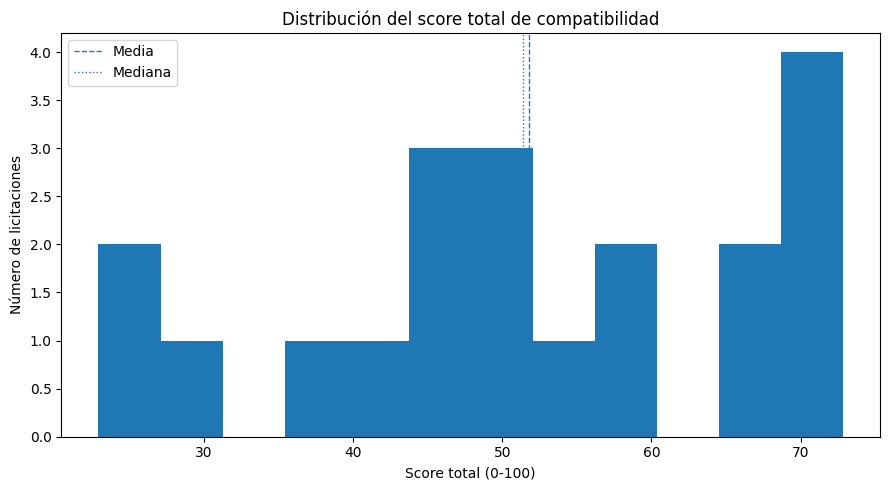

Métricas del score total:


,score_total_0_100
count,20.000000
mean,51.817544
std,15.407680
min,22.941719
25%,43.441250
50%,51.395010
75%,65.268152
max,72.827186


In [22]:
# ===============================
# 21. Distribución del score total
# ===============================

valid_scores = score_df["score_total_0_100"].dropna()

if valid_scores.empty:
    print("No hay scores totales válidos para graficar.")
else:
    plt.figure(figsize=(9, 5))
    plt.hist(valid_scores, bins=min(12, max(4, len(valid_scores))))
    plt.axvline(valid_scores.mean(), linestyle="--", linewidth=1, label="Media")
    plt.axvline(valid_scores.median(), linestyle=":", linewidth=1, label="Mediana")
    plt.title("Distribución del score total de compatibilidad")
    plt.xlabel("Score total (0-100)")
    plt.ylabel("Número de licitaciones")
    plt.legend()
    plt.tight_layout()
    plt.show()

    print("Métricas del score total:")
    display(valid_scores.describe().to_frame(name="score_total_0_100"))


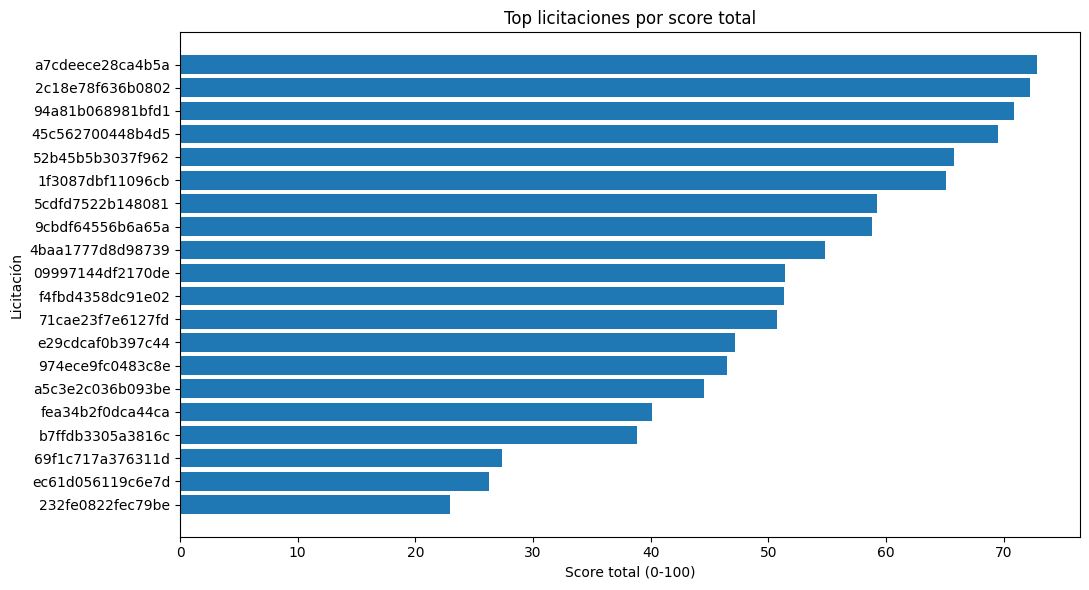

Lectura:
- Esta gráfica prioriza revisión manual, no decide automáticamente si aplicar.
- Si varias licitaciones quedan muy cerca, se requiere mirar los componentes del score.


In [23]:
# ===============================
# 22. Top licitaciones por score total
# ===============================

if valid_scores.empty:
    print("No hay scores totales válidos para graficar.")
else:
    plot_df = df_scoring_revision.head(20).copy()
    labels = plot_df["id_licitacion_norm"].astype(str)

    plt.figure(figsize=(11, 6))
    plt.barh(labels[::-1], plot_df["score_total_0_100"][::-1])
    plt.title("Top licitaciones por score total")
    plt.xlabel("Score total (0-100)")
    plt.ylabel("Licitación")
    plt.tight_layout()
    plt.show()

    print("Lectura:")
    print("- Esta gráfica prioriza revisión manual, no decide automáticamente si aplicar.")
    print("- Si varias licitaciones quedan muy cerca, se requiere mirar los componentes del score.")


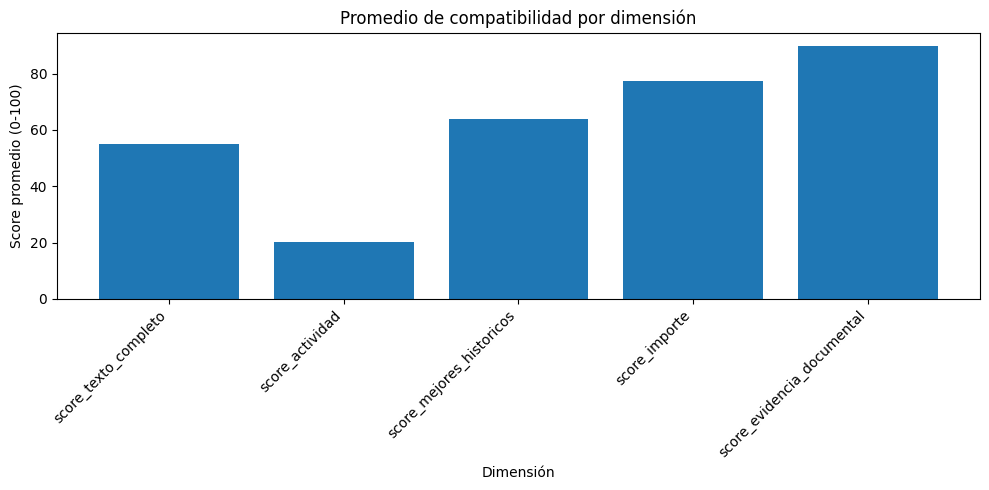

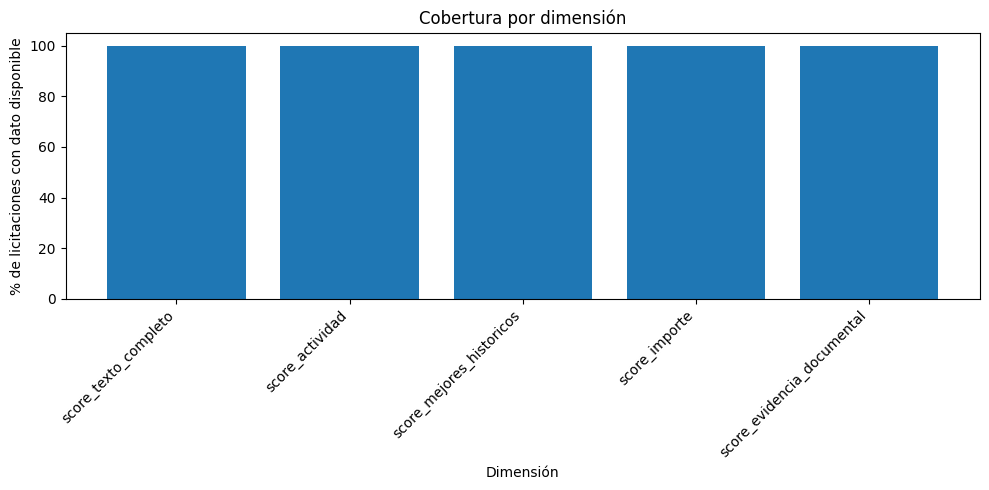

Tabla dimensión: promedio y cobertura


,dimension,n_no_nulos,porcentaje_no_nulo,promedio_0_100,mediana_0_100,min_0_100,max_0_100
5,score_evidencia_documental,20,100.0,90.000000,100.000000,0.000000,100.000000
3,score_importe,20,100.0,77.500000,100.000000,0.000000,100.000000
2,score_mejores_historicos,20,100.0,63.822491,64.769652,24.191138,91.797839
0,score_texto_completo,20,100.0,54.950171,53.936029,16.518929,89.104609
1,score_actividad,20,100.0,20.192900,19.652445,13.911187,34.926244
4,score_territorio_organo,0,0.0,NaN,NaN,NaN,NaN


In [24]:
# ===============================
# 23. Promedio y cobertura por dimensión
# ===============================

mean_scores = score_df[score_columns].mean(skipna=True).dropna()
coverage_scores = score_df[score_columns].notna().mean().reindex(mean_scores.index)

if mean_scores.empty:
    print("No hay scores por dimensión válidos para graficar.")
else:
    plt.figure(figsize=(10, 5))
    plt.bar(mean_scores.index, mean_scores.values * 100)
    plt.title("Promedio de compatibilidad por dimensión")
    plt.xlabel("Dimensión")
    plt.ylabel("Score promedio (0-100)")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(10, 5))
    plt.bar(coverage_scores.index, coverage_scores.values * 100)
    plt.title("Cobertura por dimensión")
    plt.xlabel("Dimensión")
    plt.ylabel("% de licitaciones con dato disponible")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

    print("Tabla dimensión: promedio y cobertura")
    display(tabla_dimensiones)


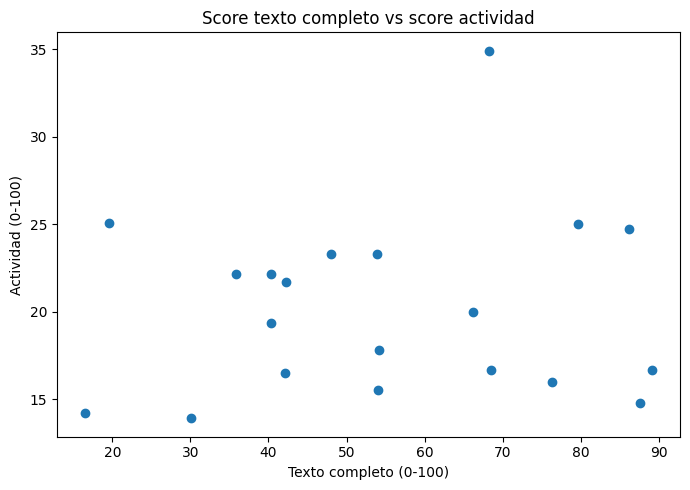

Lectura:
- Arriba a la derecha: licitaciones fuertes tanto en texto completo como en actividad.
- Alto texto y baja actividad: puede haber similitud documental general, pero menor coincidencia del servicio específico.
Correlación entre scores:


,score_texto_completo,score_actividad,score_mejores_historicos,score_importe,score_territorio_organo,score_evidencia_documental,score_total
score_texto_completo,1.000000,0.086508,0.990133,0.440508,NaN,0.466497,0.973256
score_actividad,0.086508,1.000000,0.102317,0.297571,NaN,0.046062,0.220314
score_mejores_historicos,0.990133,0.102317,1.000000,0.441815,NaN,0.538904,0.983154
score_importe,0.440508,0.297571,0.441815,1.000000,NaN,-0.071611,0.544149
score_territorio_organo,NaN,NaN,NaN,NaN,NaN,NaN,NaN
score_evidencia_documental,0.466497,0.046062,0.538904,-0.071611,NaN,1.000000,0.554803
score_total,0.973256,0.220314,0.983154,0.544149,NaN,0.554803,1.000000


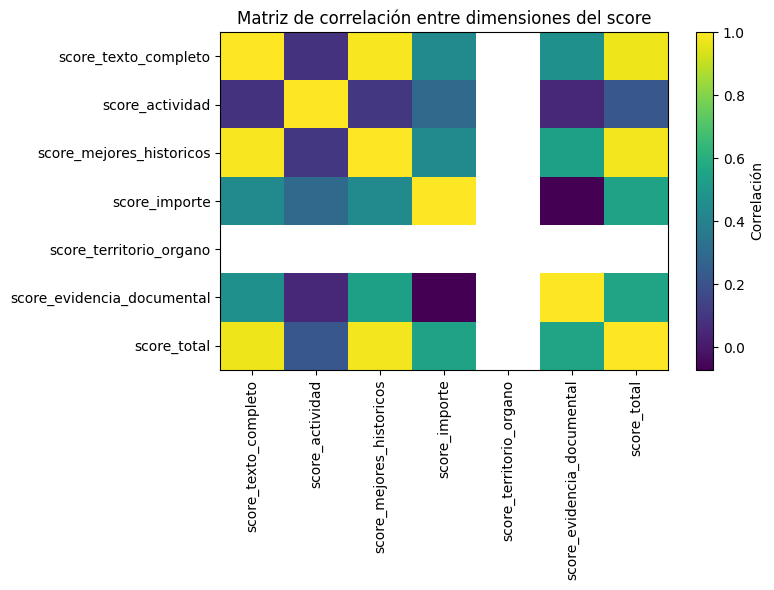

In [25]:
# ===============================
# 23.1. Relación entre dimensiones principales
# ===============================

required_cols = ["score_texto_completo", "score_actividad", "score_total_0_100"]
if all(col in score_df.columns for col in required_cols):
    scatter_df = score_df[required_cols + ["id_licitacion_norm"]].dropna()

    if scatter_df.empty:
        print("No hay datos suficientes para graficar texto vs actividad.")
    else:
        plt.figure(figsize=(7, 5))
        plt.scatter(
            scatter_df["score_texto_completo"] * 100,
            scatter_df["score_actividad"] * 100,
        )
        plt.title("Score texto completo vs score actividad")
        plt.xlabel("Texto completo (0-100)")
        plt.ylabel("Actividad (0-100)")
        plt.tight_layout()
        plt.show()

        print("Lectura:")
        print("- Arriba a la derecha: licitaciones fuertes tanto en texto completo como en actividad.")
        print("- Alto texto y baja actividad: puede haber similitud documental general, pero menor coincidencia del servicio específico.")
else:
    print("Faltan columnas para graficar texto vs actividad.")

corr_cols = [col for col in score_columns + ["score_total"] if col in score_df.columns]
if len(corr_cols) >= 2:
    corr = score_df[corr_cols].corr()
    print("Correlación entre scores:")
    display(corr)

    plt.figure(figsize=(8, 6))
    plt.imshow(corr, aspect="auto")
    plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
    plt.yticks(range(len(corr.index)), corr.index)
    plt.colorbar(label="Correlación")
    plt.title("Matriz de correlación entre dimensiones del score")
    plt.tight_layout()
    plt.show()


## 13. Revisión de casos extremos

Se revisan las licitaciones con mayor y menor score para validar si el comportamiento de la fórmula es razonable.

In [26]:
# ===============================
# 24. Top y bottom para revisión manual
# ===============================

print("Top 5 licitaciones con mayor compatibilidad:")
display(df_scoring_revision.head(5))

print("Top 5 licitaciones con menor compatibilidad:")
display(df_scoring_revision.tail(5))

Top 5 licitaciones con mayor compatibilidad:


,id_licitacion_norm,fuentes_utilizadas,n_documentos_candidata,documentos_candidata,id_tilos_mas_similar_texto,id_tilos_mas_similar_actividad,texto_tilos_mas_similar_texto,texto_tilos_mas_similar_actividad,licitacion_id,titulo,cpv_descripcion,cpv,importe_sin_impuestos,tipo_contrato,procedimiento_codigo,lugar_ejecucion_codigo,organo_contratacion,url,score_texto_completo,score_actividad,score_mejores_historicos,score_importe,score_territorio_organo,score_evidencia_documental,score_texto_max,score_actividad_max,score_perfil_global_tilos,score_total_0_100,nivel_compatibilidad,n_dimensiones_disponibles
0,a7cdeece28ca4b5a,"madrid_html_secciones, muestra_20",20,01_Memoria_justificativa_del_contrato_Publicado_el_15_de_abril_del_2024_1521.pdf; 02_Iniciación_del_expediente_de_contratación_Publicado_el_15_de_abril_del_2024_1521.pdf; 03_Ap...,doc_tilos_sin_id_33,doc_tilos_sin_id_126,ministerio de inclusion seguridad social y migraciones pinar de valsain no 1 40005 segovia tel921 41 44 52 codigo dir3 ea0042182 direccion provincial de segovia pliego servicio...,ministerio de inclusion seguridad social y migraciones direccion provincial de segovia secretaria provincial pagina 1 de 5 buzon tgss segovia licitaciones seg social es c pinar...,a7cdeece28ca4b5a,"Contrato de servicio de prevención ajeno en las especialidades de vigilancia de la salud y seguridad en el trabajo, para la Fundación para la Investigación Biomédica del Hospit...",Servicios de salud; Servicios de sanidad de las empresas,NaN,105000.0,Servicios,1,ES300,Fundación para la Investigación Biomédica del Hospital Universitario La Paz,https://contratos-publicos.comunidad.madrid/contrato-publico/contrato-servicio-prevencion-ajeno-especialidades-vigilancia-salud-seguridad-0,0.862464,0.247528,0.899938,1.0,NaN,1.0,0.865922,0.248283,0.937412,72.827186,Alta,5
1,2c18e78f636b0802,"madrid_html_secciones, muestra_20",7,01_Iniciación_del_expediente_de_contratación_Publicado_el_7_de_febrero_del_2024_1401.pdf; 02_Aprobación_del_expediente_de_contratación_Publicado_el_7_de_febrero_del_2024_1401.p...,doc_tilos_sin_id_68,doc_tilos_sin_id_159,pliego modelo de servicios procedimiento abierto simplificado 1 58 gerencia regional de salud pliego modelo de clausulas administrativas particul ares para la contratacion de s...,pagina 1 de 64 pliego de prescripciones tecnicas para la realizacion de procedimientos quirurgicos y procedimientos de diagnostico para pacientes con derecho a prestacion sanit...,2c18e78f636b0802,P.A.S.A. 8/2024. Servicio para la realización de pruebas de diagnóstico oftalmológico basado en inteligencia artificial para el Servicio de Oftalmología del Hospital Universita...,Servicios oftalmológicos,NaN,59992.0,Servicios,9,ES300,Hospital Universitario La Paz,https://contratos-publicos.comunidad.madrid/contrato-publico/pasa-82024-servicio-realizacion-pruebas-diagnostico-oftalmologico-basado,0.891046,0.166703,0.917978,1.0,NaN,1.0,0.898737,0.167846,0.944911,72.188510,Alta,5
2,94a81b068981bfd1,"madrid_html_secciones, muestra_20",7,01_Iniciación_del_expediente_de_contratación_Publicado_el_18_de_agosto_del_2023_1438.pdf; 02_Aprobación_del_expediente_de_contratación_Publicado_el_18_de_agosto_del_2023_1438.p...,doc_tilos_sin_id_68,sp00145_2024,pliego modelo de servicios procedimiento abierto simplificado 1 58 gerencia regional de salud pliego modelo de clausulas administrativas particul ares para la contratacion de s...,asistencia sanitaria ambulatoria para la realizacion de pruebas de electromiografias en segovia,94a81b068981bfd1,P.A.S.A. 44/2023 servicio para la realización de pruebas de diagnóstico oftalmológico basado en inteligencia artificial,Servicios oftalmológicos,NaN,59992.0,Servicios,9,ES300,Hospital Universitario La Paz,https://contratos-publicos.comunidad.madrid/contrato-publico/pasa-442023-servicio-realizacion-pruebas-diagnostico-oftalmologico-basado,0.875902,0.147783,0.907067,1.0,NaN,1.0,0.884848,0.181895,0.938232,70.880720,Alta,5
3,45c562700448b4d5,"madrid_html_secciones, muest

Top 5 licitaciones con menor compatibilidad:


,id_licitacion_norm,fuentes_utilizadas,n_documentos_candidata,documentos_candidata,id_tilos_mas_similar_texto,id_tilos_mas_similar_actividad,texto_tilos_mas_similar_texto,texto_tilos_mas_similar_actividad,licitacion_id,titulo,cpv_descripcion,cpv,importe_sin_impuestos,tipo_contrato,procedimiento_codigo,lugar_ejecucion_codigo,organo_contratacion,url,score_texto_completo,score_actividad,score_mejores_historicos,score_importe,score_territorio_organo,score_evidencia_documental,score_texto_max,score_actividad_max,score_perfil_global_tilos,score_total_0_100,nivel_compatibilidad,n_dimensiones_disponibles
15,fea34b2f0dca44ca,"madrid_html_secciones, muestra_20",21,01_Memoria_justificativa_del_contrato_Publicado_el_16_de_febrero_del_2024_0931.pdf; 02_Iniciación_del_expediente_de_contratación_Publicado_el_16_de_febrero_del_2024_0931.pdf; 0...,doc_tilos_sin_id_68,doc_tilos_sin_id_178,pliego modelo de servicios procedimiento abierto simplificado 1 58 gerencia regional de salud pliego modelo de clausulas administrativas particul ares para la contratacion de s...,c luis erik claveria neurologo s n 40002 segovia p a g i n a 1 18 memoria justificativa expediente 6301 631 1 2025 15479 procedimiento abierto servicios para realizacion de pro...,fea34b2f0dca44ca,Contrato de Servicios de 30 plazas de ingreso y 20 plazas de Hospital de día en hospital de Salud Mental y Tratamiento de adicciones,Servicios varios de salud,NaN,3848160.0,Servicios,1,ES300,Servicio Madrileño de Salud,https://contratos-publicos.comunidad.madrid/contrato-publico/contrato-servicios-30-plazas-ingreso-20-plazas-hospital-dia-hospital-salud-mental,0.422156,0.217108,0.518664,0.0,NaN,1.0,0.426346,0.222876,0.615172,40.098825,Media,5
16,b7ffdb3305a3816c,"madrid_html_secciones, muestra_20",26,01_Memoria_justificativa_del_contrato_Publicado_el_22_de_abril_del_2024_1021.pdf; 02_Informe_de_insuficiencia_de_medios_Publicado_el_22_de_abril_del_2024_1021.pdf; 03_Iniciació...,doc_tilos_sin_id_68,doc_tilos_sin_id_178,pliego modelo de servicios procedimiento abierto simplificado 1 58 gerencia regional de salud pliego modelo de clausulas administrativas particul ares para la contratacion de s...,c luis erik claveria neurologo s n 40002 segovia p a g i n a 1 18 memoria justificativa expediente 6301 631 1 2025 15479 procedimiento abierto servicios para realizacion de pro...,b7ffdb3305a3816c,"PA SER 4/2024 Servicio para la detección de drogas en orina, por laboratorio externo, para los centros de tratamiento de adicciones de la Comunidad de Madrid",Servicios prestados por laboratorios médicos,NaN,1043000.0,Servicios,1,ES300,Servicio Madrileño de Salud,https://contratos-publicos.comunidad.madrid/contrato-publico/pa-ser-42024-servicio-deteccion-drogas-orina-laboratorio-externo-centros,0.403526,0.193328,0.527602,0.0,NaN,1.0,0.405654,0.198358,0.651678,38.829748,Baja,5
17,69f1c717a376311d,"castilla_leon_html, muestra_20",0,,doc_tilos_sin_id_178,cs-2022_4002_0004,c luis erik claveria neurologo s n 40002 segovia p a g i n a 1 18 memoria justificativa expediente 6301 631 1 2025 15479 procedimiento abierto servicios para realizacion de pro...,servicio de asistencia sanitaria especializada en pruebas de diagnostico por imagen en regimen ambulatorio en la localidad de segovia,69f1c717a376311d,asistencia sanitaria diagnóstico por resonancia magnética,Servicios de salud,85100000-0,402336.32,Servicios,1,ES414,Gerencia de Atención Especializada de Palencia,https://contratacion.jcyl.es/web/jcyl/ContratacionAdministrativa/es/Plantilla100Detalle/1284152328311/_/1284788405462/Propuesta,0.300429,0.139112,0.375301,0.7,NaN,0.0,0.306438,0.154037,0.450174,27.394176,Baja,5
18,ec61d056119c6e7d,muestra_20,0,,doc_tilos_sin_id_178,doc_tilos_sin_id_124,c luis erik claveria neurologo s n 40002 segovia p a g i n a 1 18 memoria justificativa expediente 6301 631 1 2025 15479 procedimiento abierto servicios para realizacion de pro...,ministerio de inclusion seguridad social y migraciones tesoreria general de la seguridad social di

## 14. Diagnóstico de calidad de evidencia

Esta parte no cambia el score. Sirve para revisar si el resultado se apoya en suficiente información.

In [27]:
# ===============================
# 25. Diagnóstico de evidencia disponible
# ===============================

print("Dimensiones disponibles por licitación:")
print(score_df["n_dimensiones_disponibles"].value_counts().sort_index())

print("\nDocumentos candidatos:")
print(score_df["n_documentos_candidata"].describe())

print("\nDocumentos asociados por licitación:")
docs_por_licitacion = (
    score_df[["id_licitacion_norm", "n_documentos_candidata", "score_total_0_100", "nivel_compatibilidad"]]
    .sort_values(["n_documentos_candidata", "score_total_0_100"], ascending=[False, False])
)
display(docs_por_licitacion)

print("\nLicitaciones con menos de 3 dimensiones disponibles:")
display(
    score_df.loc[
        score_df["n_dimensiones_disponibles"] < 3,
        ["id_licitacion_norm", "score_total_0_100", "nivel_compatibilidad", "n_dimensiones_disponibles"]
    ].sort_values("score_total_0_100", ascending=False)
)

print("\nRegistros con menor evidencia documental o textual:")
cols_evidencia = [
    "id_licitacion_norm",
    "n_documentos_candidata",
    "score_evidencia_documental",
    "score_texto_completo",
    "score_actividad",
    "score_total_0_100",
]
cols_evidencia = [col for col in cols_evidencia if col in score_df.columns]
display(
    score_df[cols_evidencia]
    .sort_values(["n_documentos_candidata", "score_texto_completo"], ascending=[True, True])
    .head(10)
)


Dimensiones disponibles por licitación:
n_dimensiones_disponibles
5    20
Name: count, dtype: int64

Documentos candidatos:
count    20.000000
mean     17.100000
std      10.269526
min       0.000000
25%      11.750000
50%      17.000000
75%      21.000000
max      45.000000
Name: n_documentos_candidata, dtype: float64

Documentos asociados por licitación:


,id_licitacion_norm,n_documentos_candidata,score_total_0_100,nivel_compatibilidad
9,71cae23f7e6127fd,45,50.727642,Media
2,232fe0822fec79be,31,22.941719,Baja
15,b7ffdb3305a3816c,26,38.829748,Baja
1,1f3087dbf11096cb,22,65.101125,Alta
12,9cbdf64556b6a65a,21,58.816633,Media
11,974ece9fc0483c8e,21,46.509663,Media
19,fea34b2f0dca44ca,21,40.098825,Media
14,a7cdeece28ca4b5a,20,72.827186,Alta
5,4baa1777d8d98739,19,54.815187,Media
4,45c562700448b4d5,17,69.495213,Alta



Licitaciones con menos de 3 dimensiones disponibles:


,id_licitacion_norm,score_total_0_100,nivel_compatibilidad,n_dimensiones_disponibles



Registros con menor evidencia documental o textual:


,id_licitacion_norm,n_documentos_candidata,score_evidencia_documental,score_texto_completo,score_actividad,score_total_0_100
17,ec61d056119c6e7d,0,0.0,0.195281,0.250886,26.250191
8,69f1c717a376311d,0,0.0,0.300429,0.139112,27.394176
10,94a81b068981bfd1,7,1.0,0.875902,0.147783,70.880720
3,2c18e78f636b0802,7,1.0,0.891046,0.166703,72.188510
0,09997144df2170de,11,1.0,0.479935,0.232974,51.441795
16,e29cdcaf0b397c44,12,1.0,0.403335,0.221870,47.138954
13,a5c3e2c036b093be,14,1.0,0.358644,0.221870,44.555392
6,52b45b5b3037f962,14,1.0,0.682418,0.349262,65.769230
18,f4fbd4358dc91e02,17,1.0,0.542161,0.178211,51.348225
7,5cdfd7522b148081,17,1.0,0.685406,0.166486,59.220756


## 15. Conclusión operativa

Esta versión incorpora caché documental. La primera ejecución puede tardar porque lee los PDFs, pero las siguientes deberían cargar desde parquet y evitar la espera larga, salvo que cambien los documentos o se active `FORZAR_RELECTURA_DOCUMENTOS=True`.

Sobre IA externa: no es necesaria todavía para calcular el scoring base. Primero debe validarse si este ranking discrimina bien y si los casos con mayor score tienen sentido. Una IA externa puede aportar después en tres usos concretos:

1. Extraer requisitos técnicos y administrativos de pliegos largos.
2. Generar explicación textual del match.
3. Probar embeddings semánticos para mejorar similitud conceptual.

No conviene reemplazar el scoring auditable por un agente externo sin una validación previa, porque perderíamos trazabilidad y sería más difícil defender el resultado metodológicamente.

## 16. Bloque final TFM: score final, tablas y gráficas de presentación

Este bloque toma los resultados ya calculados (`score_df`) y genera una salida final para el TFM.

Criterios incorporados:

1. **No se habla de probabilidad** porque no existe una variable objetivo observada de éxito, adjudicación o decisión de Los Tilos.
2. El resultado se presenta como **score de compatibilidad documental**.
3. Se conserva el `id_licitacion_norm` para trazabilidad, pero se crea un `nombre_licitacion` interpretable para análisis y presentación.
4. La dimensión `Territorio/órgano` solo se usa si tiene datos. Si está completamente vacía, se excluye automáticamente del score final y de las gráficas.
5. Se mantiene el scoring base para presentación, porque `score_actividad` todavía es conservador con TF-IDF y no debe penalizar en exceso el ranking.
6. Las gráficas se generan con etiquetas numéricas y se exportan a PNG para usar en el documento o presentación.

Pesos finales usados:


,peso
score_texto_completo,0.40
score_actividad,0.25
score_mejores_historicos,0.15
score_importe,0.07
score_evidencia_documental,0.08


Dimensiones excluidas por falta total de datos:
['score_territorio_organo']
Ranking final para presentación:


,nombre_licitacion,id_licitacion_norm,score_final_0_100,nivel_final,score_texto_completo,score_actividad,score_mejores_historicos,score_importe,score_territorio_organo,score_evidencia_documental,n_documentos_candidata,n_dimensiones_finales,id_tilos_mas_similar_texto,id_tilos_mas_similar_actividad
0,Contrato de servicio de prevención ajeno en las especialidades de vigilancia de la sa...,a7cdeece28ca4b5a,72.827,Alta,0.862,0.248,0.900,1.0,NaN,1.0,20,5,doc_tilos_sin_id_33,doc_tilos_sin_id_126
1,P.A.S.A. 8/2024. Servicio para la realización de pruebas de diagnóstico oftalmológico...,2c18e78f636b0802,72.189,Alta,0.891,0.167,0.918,1.0,NaN,1.0,7,5,doc_tilos_sin_id_68,doc_tilos_sin_id_159
2,P.A.S.A. 44/2023 servicio para la realización de pruebas de diagnóstico oftalmológico...,94a81b068981bfd1,70.881,Alta,0.876,0.148,0.907,1.0,NaN,1.0,7,5,doc_tilos_sin_id_68,sp00145_2024
3,"Servicio de vigilancia de la salud de Radio Televisión Madrid, S.A.U.",45c562700448b4d5,69.495,Alta,0.797,0.250,0.860,1.0,NaN,1.0,17,5,doc_tilos_sin_id_68,40_vc-270_22
4,Servicios de especialidad de medicina del trabajo con un servicio de prevención ajeno...,52b45b5b3037f962,65.769,Alta,0.682,0.349,0.763,1.0,NaN,1.0,14,5,doc_tilos_sin_id_68,doc_tilos_sin_id_124
5,Servicio de realización de Resonancias Magnéticas para el Servicio de Psiquiatría del...,1f3087dbf11096cb,65.101,Alta,0.764,0.160,0.819,1.0,NaN,1.0,22,5,doc_tilos_sin_id_33,doc_tilos_sin_id_178
6,Servicios sanitarios para la temporada de verano 2023 en las instalaciones deportivas...,5cdfd7522b148081,59.221,Media,0.685,0.166,0.785,0.7,NaN,1.0,17,5,doc_tilos_sin_id_68,doc_tilos_sin_id_123
7,Servicios sanitarios para la temporada de verano 2024 en las instalaciones deportivas...,9cbdf64556b6a65a,58.817,Media,0.662,0.200,0.767,0.7,NaN,1.0,21,5,doc_tilos_sin_id_68,doc_tilos_sin_id_123
8,Servicio médico para la realización de una campaña de prevención de cáncer ginecológi...,4baa1777d8d98739,54.815,Media,0.539,0.233,0.646,1.0,NaN,1.0,19,5,doc_tilos_sin_id_68,doc_tilos_sin_id_124
9,Servicio médico para la realización de una campaña de prevención de cáncer ginecológi...,09997144df2170de,51.442,Media,0.480,0.233,0.590,1.0,NaN,1.0,11,5,doc_tilos_sin_id_68,doc_tilos_sin_id_124


Resumen por nivel de compatibilidad final:


...

Resumen por dimensión final:


,dimension,nombre_dimension,peso,n_no_nulos,porcentaje_no_nulo,promedio_0_100,mediana_0_100,min_0_100,max_0_100
0,score_texto_completo,Similitud textual,0.40,20,100.0,54.950,53.936,16.519,89.105
1,score_actividad,Actividad contractual,0.25,20,100.0,20.193,19.652,13.911,34.926
2,score_mejores_historicos,Similitud con históricos,0.15,20,100.0,63.822,64.770,24.191,91.798
3,score_evidencia_documental,Evidencia documental,0.08,20,100.0,90.000,100.000,0.000,100.000
4,score_importe,Importe,0.07,20,100.0,77.500,100.000,0.000,100.000


Aportes al score final:


,nombre_licitacion,id_licitacion_norm,score_final_0_100,nivel_final,aporte_Similitud textual,aporte_Actividad contractual,aporte_Similitud con históricos,aporte_Importe,aporte_Evidencia documental
14,Contrato de servicio de prevención ajeno en las especialidades de vigilancia de la sa...,a7cdeece28ca4b5a,72.83,Alta,36.31,6.51,14.21,7.37,8.42
3,P.A.S.A. 8/2024. Servicio para la realización de pruebas de diagnóstico oftalmológico...,2c18e78f636b0802,72.19,Alta,37.52,4.39,14.49,7.37,8.42
10,P.A.S.A. 44/2023 servicio para la realización de pruebas de diagnóstico oftalmológico...,94a81b068981bfd1,70.88,Alta,36.88,3.89,14.32,7.37,8.42
4,"Servicio de vigilancia de la salud de Radio Televisión Madrid, S.A.U.",45c562700448b4d5,69.50,Alta,33.54,6.58,13.59,7.37,8.42
6,Servicios de especialidad de medicina del trabajo con un servicio de prevención ajeno...,52b45b5b3037f962,65.77,Alta,28.73,9.19,12.06,7.37,8.42
1,Servicio de realización de Resonancias Magnéticas para el Servicio de Psiquiatría del...,1f3087dbf11096cb,65.10,Alta,32.17,4.21,12.94,7.37,8.42
7,Servicios sanitarios para la temporada de verano 2023 en las instalaciones deportivas...,5cdfd7522b148081,59.22,Media,28.86,4.38,12.40,5.16,8.42
12,Servicios sanitarios para la temporada de verano 2024 en las instalaciones deportivas...,9cbdf64556b6a65a,58.82,Media,27.88,5.26,12.10,5.16,8.42
5,Servicio médico para la realización de una campaña de prevención de cáncer ginecológi...,4baa1777d8d98739,54.82,Media,22.69,6.13,10.20,7.37,8.42
0,Servicio médico para la realización de una campaña de prevención de cáncer ginecológi...,09997144df2170de,51.44,Media,20.21,6.13,9.31,7.37,8.42


Excel final exportado: C:\Users\Usuario\TFM\TFM_scraping_contratacion_estado\data\Silver\scoring_final_presentacion_tfm.xlsx
Parquet final exportado: C:\Users\Usuario\TFM\TFM_scraping_contratacion_estado\data\Silver\scoring_final_presentacion_tfm.parquet


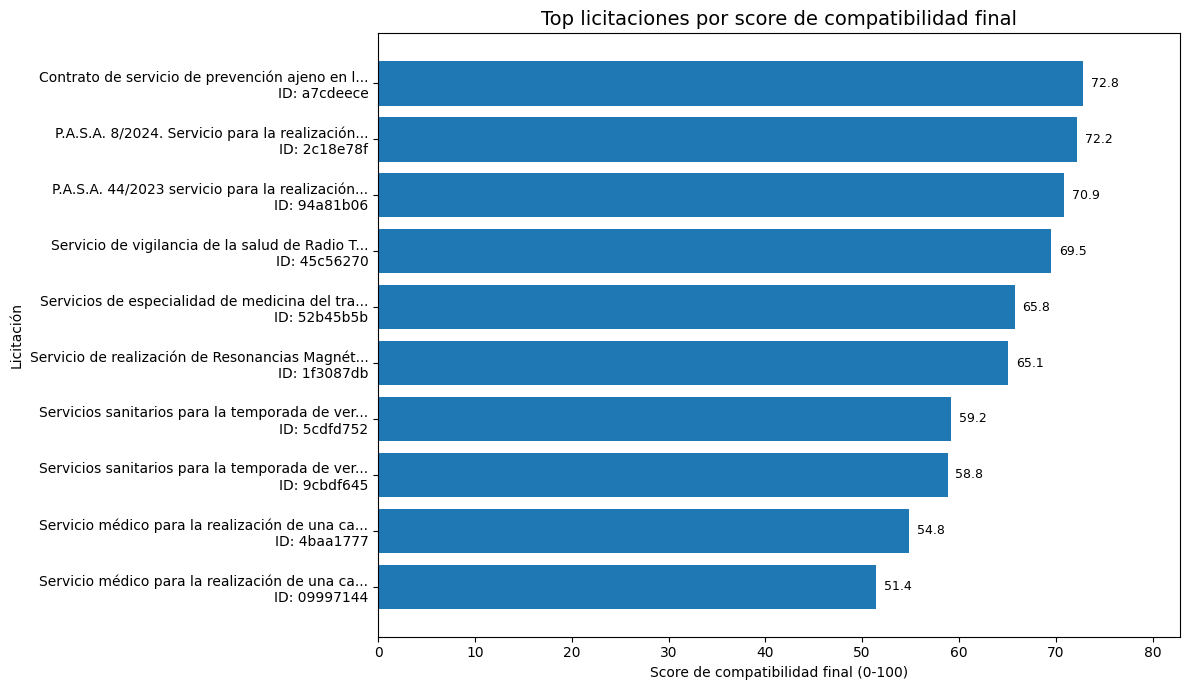

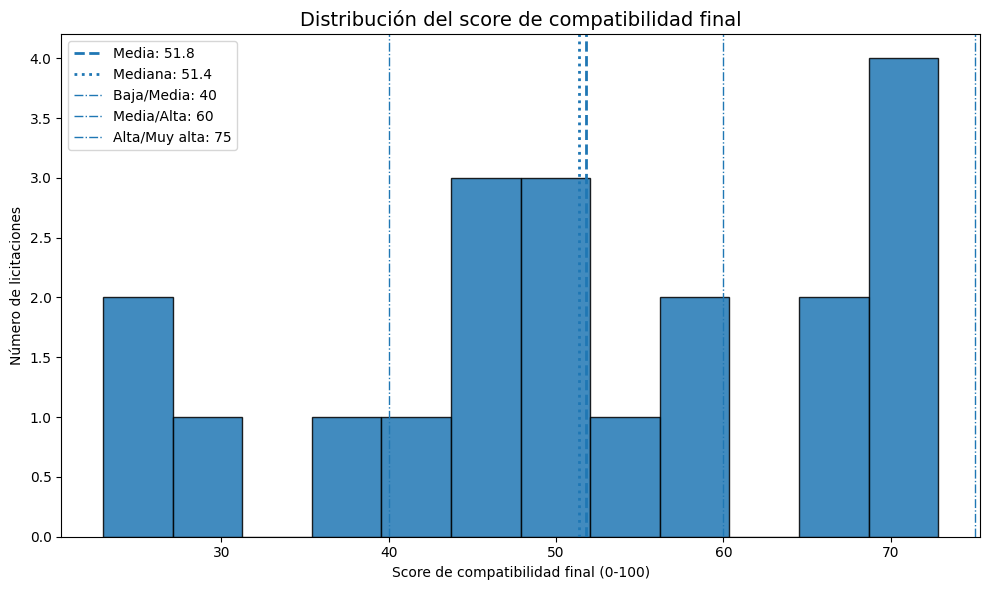

Resumen del score final:


,score_final_0_100
count,20.00
mean,51.82
std,15.41
min,22.94
25%,43.44
50%,51.40
75%,65.27
max,72.83


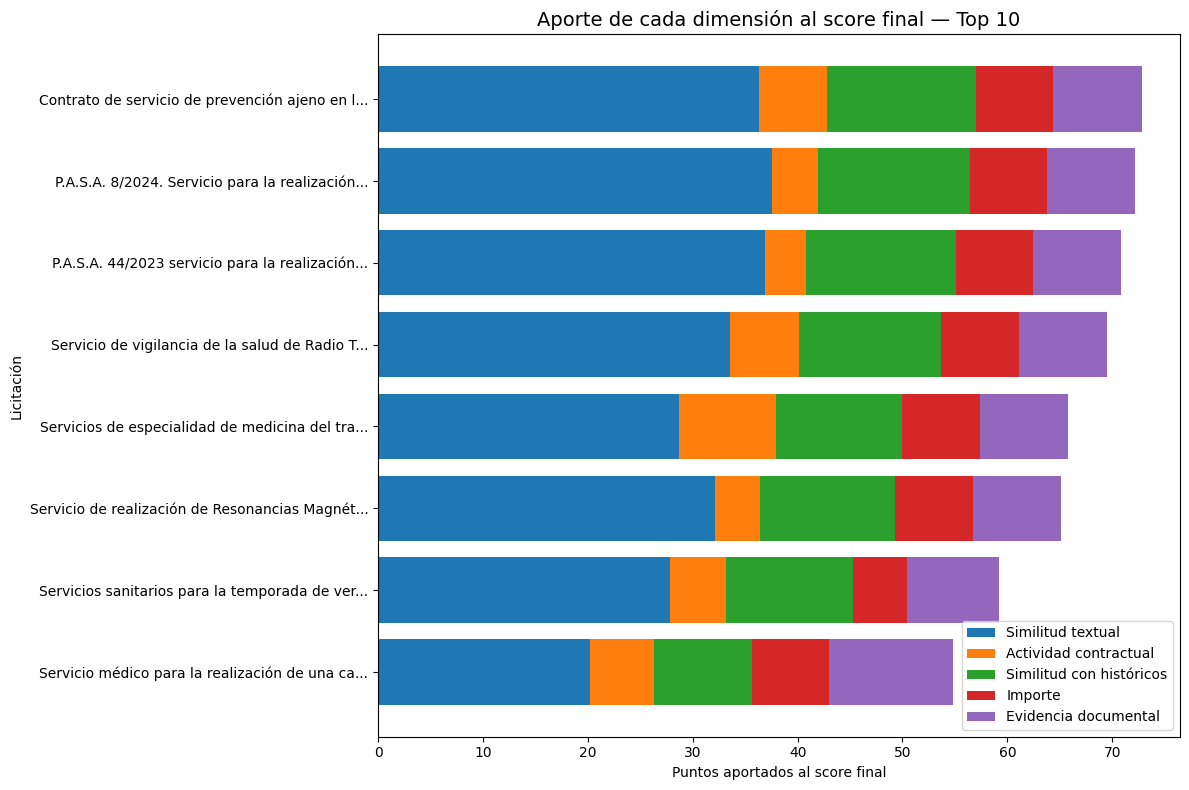

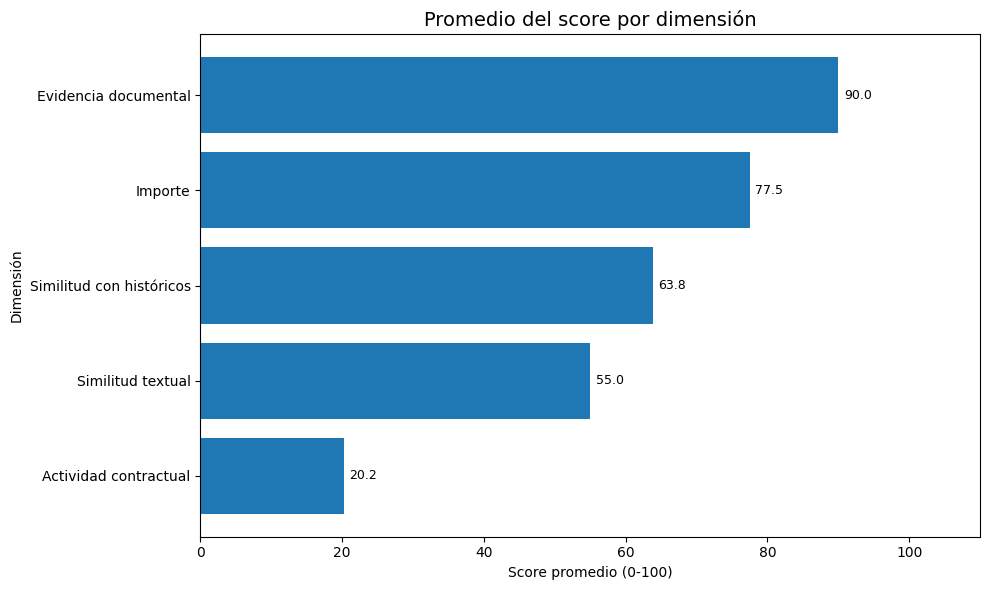

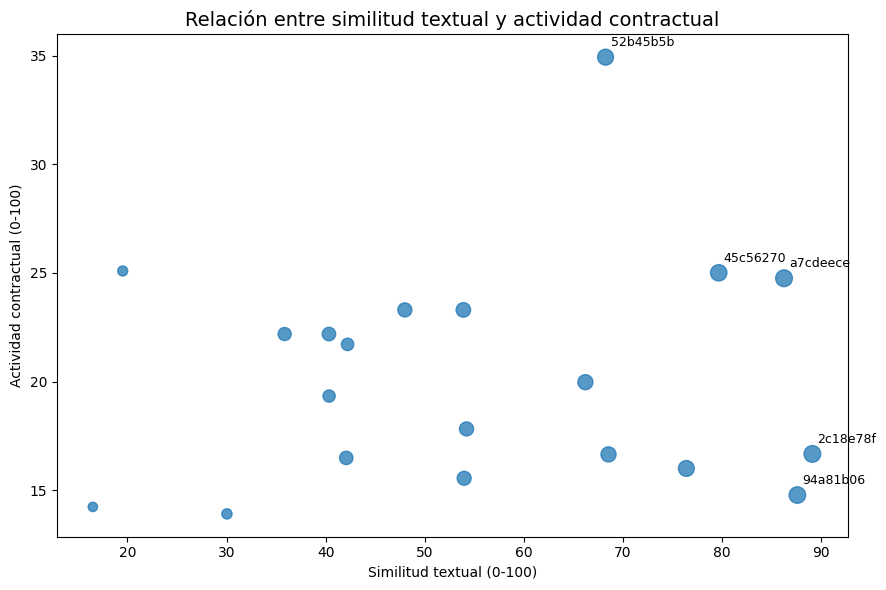

LECTURA METODOLÓGICA PARA EL TFM
El resultado debe interpretarse como un score de compatibilidad documental, no como una probabilidad de adjudicación. El ranking prioriza licitaciones para revisión manual según similitud textual, actividad contractual, importe y evidencia documental disponible.

Figuras exportadas en: C:\Users\Usuario\TFM\TFM_scraping_contratacion_estado\data\Silver\figuras_scoring_final_tfm
Tablas finales exportadas en: C:\Users\Usuario\TFM\TFM_scraping_contratacion_estado\data\Silver\scoring_final_presentacion_tfm.xlsx


In [28]:
# ============================================================
# BLOQUE FINAL TFM
# Score final, tablas y gráficas para presentación
# ============================================================

import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# ============================================================
# 1. Configuración metodológica final
# ============================================================
# Este score no es una probabilidad estadística.
# Es un índice de compatibilidad documental entre cada licitación
# candidata y la información histórica/documental de Los Tilos.

MAX_NOMBRE_TABLA = 85
MAX_NOMBRE_GRAFICA = 45
TOP_N = 10

FIGURES_DIR_FINAL = SILVER_DIR / "figuras_scoring_final_tfm"
FIGURES_DIR_FINAL.mkdir(parents=True, exist_ok=True)

OUTPUT_PRESENTACION_FINAL_EXCEL = SILVER_DIR / "scoring_final_presentacion_tfm.xlsx"
OUTPUT_PRESENTACION_FINAL_PARQUET = SILVER_DIR / "scoring_final_presentacion_tfm.parquet"

# Nombres legibles para presentación.
DIMENSION_LABELS = {
    "score_texto_completo": "Similitud textual",
    "score_actividad": "Actividad contractual",
    "score_mejores_historicos": "Similitud con históricos",
    "score_importe": "Importe",
    "score_territorio_organo": "Territorio/órgano",
    "score_evidencia_documental": "Evidencia documental",
}

# Pesos finales para presentación del TFM.
# Justificación:
# - Se mantiene el scoring base porque la dimensión de actividad todavía es conservadora
#   con TF-IDF y no debe penalizar en exceso el ranking.
# - La similitud textual y con históricos sostienen la recomendación documental.
# - La evidencia documental queda como soporte, no como variable principal.
# - Territorio/órgano se conserva en la definición, pero se excluye automáticamente
#   si no tiene datos disponibles.
FINAL_WEIGHTS_RAW = {
    "score_texto_completo": 0.40,
    "score_actividad": 0.25,
    "score_mejores_historicos": 0.15,
    "score_importe": 0.07,
    "score_territorio_organo": 0.05,
    "score_evidencia_documental": 0.08,
}


# ============================================================
# 2. Funciones auxiliares
# ============================================================

def shorten_text(value, max_chars: int = 85) -> str:
    """Recorta texto para que sea legible en tablas y gráficas."""
    if pd.isna(value):
        return ""

    text = str(value).strip()
    text = re.sub(r"\s+", " ", text)

    if len(text) <= max_chars:
        return text

    return text[:max_chars].rstrip() + "..."



def get_first_valid_text(row: pd.Series, columns: list[str]) -> str:
    """Devuelve el primer texto no vacío de una lista de columnas."""
    for column in columns:
        if column in row.index:
            value = row[column]
            if pd.notna(value) and str(value).strip() != "":
                return str(value)

    return ""



def get_available_weights(df: pd.DataFrame, weights: dict[str, float]) -> dict[str, float]:
    """Excluye dimensiones inexistentes o totalmente vacías."""
    available_weights = {}

    for column, weight in weights.items():
        if column in df.columns and df[column].notna().any():
            available_weights[column] = weight

    return available_weights



def weighted_score_final(row: pd.Series, weights: dict[str, float]) -> float:
    """Calcula score ponderado renormalizando pesos disponibles por fila."""
    numerator = 0.0
    denominator = 0.0

    for column, weight in weights.items():
        value = row.get(column, np.nan)

        if pd.notna(value):
            numerator += value * weight
            denominator += weight

    if denominator == 0:
        return np.nan

    return numerator / denominator



def calcular_aportes_final(row: pd.Series, weights: dict[str, float]) -> pd.Series:
    """Calcula el aporte en puntos de cada dimensión al score final."""
    peso_disponible = 0.0

    for column, weight in weights.items():
        if column in row.index and pd.notna(row[column]):
            peso_disponible += weight

    aportes = {}

    for column, weight in weights.items():
        label = DIMENSION_LABELS.get(column, column)
        aporte_column = f"aporte_{label}"

        if column in row.index and pd.notna(row[column]) and peso_disponible > 0:
            aportes[aporte_column] = row[column] * weight / peso_disponible * 100
        else:
            aportes[aporte_column] = np.nan

    return pd.Series(aportes)



def add_bar_labels_horizontal(bars, offset: float = 0.8):
    """Agrega valores al final de barras horizontales."""
    for bar in bars:
        width = bar.get_width()
        plt.text(
            width + offset,
            bar.get_y() + bar.get_height() / 2,
            f"{width:.1f}",
            va="center",
            fontsize=9,
        )



def add_bar_labels_vertical(bars, offset: float = 1.0):
    """Agrega valores encima de barras verticales."""
    for bar in bars:
        height = bar.get_height()
        plt.text(
            bar.get_x() + bar.get_width() / 2,
            height + offset,
            f"{height:.1f}",
            ha="center",
            va="bottom",
            fontsize=9,
        )


# ============================================================
# 3. Construcción de nombres interpretables
# ============================================================
# Para la presentación, el ID se conserva, pero el lector necesita
# una descripción corta de la licitación.

possible_label_columns = []

for key in ["titulo", "actividad", "cpv", "procedimiento"]:
    column = cols_candidates.get(key)
    if column is not None and column in score_df.columns:
        possible_label_columns.append(column)

possible_label_columns += [
    "texto_actividad",
    "texto_scoring",
]

possible_label_columns = list(dict.fromkeys(possible_label_columns))

score_df["nombre_licitacion"] = score_df.apply(
    lambda row: shorten_text(
        get_first_valid_text(row, possible_label_columns),
        max_chars=MAX_NOMBRE_TABLA,
    ),
    axis=1,
)

score_df.loc[
    score_df["nombre_licitacion"].str.len() == 0,
    "nombre_licitacion",
] = score_df["id_licitacion_norm"]

score_df["nombre_corto"] = score_df["nombre_licitacion"].apply(
    lambda value: shorten_text(value, MAX_NOMBRE_GRAFICA)
)

score_df["label_grafica"] = (
    score_df["nombre_corto"]
    + "\nID: "
    + score_df["id_licitacion_norm"].astype(str).str.slice(0, 8)
)


# ============================================================
# 4. Recalcular score final TFM
# ============================================================
# Se excluyen automáticamente dimensiones sin datos, como territorio/órgano
# cuando aparece completamente en NaN.

FINAL_WEIGHTS = get_available_weights(score_df, FINAL_WEIGHTS_RAW)

score_df["score_final"] = score_df.apply(
    lambda row: weighted_score_final(row, FINAL_WEIGHTS),
    axis=1,
)

score_df["score_final_0_100"] = score_df["score_final"] * 100

score_df["nivel_final"] = pd.cut(
    score_df["score_final_0_100"],
    bins=[-np.inf, 40, 60, 75, np.inf],
    labels=["Baja", "Media", "Alta", "Muy alta"],
)

score_df["n_dimensiones_finales"] = score_df[list(FINAL_WEIGHTS.keys())].notna().sum(axis=1)

print("Pesos finales usados:")
display(pd.Series(FINAL_WEIGHTS, name="peso").to_frame())

print("Dimensiones excluidas por falta total de datos:")
excluded_dimensions = [
    col for col in FINAL_WEIGHTS_RAW
    if col not in FINAL_WEIGHTS
]
print(excluded_dimensions)


# ============================================================
# 5. Tabla final de ranking
# ============================================================

cols_presentacion = [
    "nombre_licitacion",
    "id_licitacion_norm",
    "score_final_0_100",
    "nivel_final",
    "score_texto_completo",
    "score_actividad",
    "score_mejores_historicos",
    "score_importe",
    "score_territorio_organo",
    "score_evidencia_documental",
    "n_documentos_candidata",
    "n_dimensiones_finales",
    "id_tilos_mas_similar_texto",
    "id_tilos_mas_similar_actividad",
]

cols_presentacion = [
    col for col in cols_presentacion
    if col in score_df.columns
]

df_presentacion_final = (
    score_df[cols_presentacion]
    .sort_values("score_final_0_100", ascending=False)
    .reset_index(drop=True)
)

numeric_cols = df_presentacion_final.select_dtypes(include="number").columns
df_presentacion_final[numeric_cols] = df_presentacion_final[numeric_cols].round(3)

print("Ranking final para presentación:")
display(df_presentacion_final)


# ============================================================
# 6. Resumen por nivel de compatibilidad final
# ============================================================

tabla_resumen_nivel_final = (
    score_df
    .groupby("nivel_final", dropna=False)
    .agg(
        n_licitaciones=("id_licitacion_norm", "count"),
        score_promedio=("score_final_0_100", "mean"),
        score_mediana=("score_final_0_100", "median"),
        score_min=("score_final_0_100", "min"),
        score_max=("score_final_0_100", "max"),
        documentos_promedio=("n_documentos_candidata", "mean"),
        dimensiones_promedio=("n_dimensiones_finales", "mean"),
    )
    .reset_index()
)

numeric_cols = tabla_resumen_nivel_final.select_dtypes(include="number").columns
tabla_resumen_nivel_final[numeric_cols] = tabla_resumen_nivel_final[numeric_cols].round(2)

print("Resumen por nivel de compatibilidad final:")
display(tabla_resumen_nivel_final)


# ============================================================
# 7. Resumen por dimensión final
# ============================================================

tabla_dimensiones_final = pd.DataFrame(
    {
        "dimension": list(FINAL_WEIGHTS.keys()),
        "nombre_dimension": [
            DIMENSION_LABELS.get(col, col)
            for col in FINAL_WEIGHTS.keys()
        ],
        "peso": [
            FINAL_WEIGHTS[col]
            for col in FINAL_WEIGHTS.keys()
        ],
        "n_no_nulos": [
            score_df[col].notna().sum()
            for col in FINAL_WEIGHTS.keys()
        ],
        "porcentaje_no_nulo": [
            score_df[col].notna().mean() * 100
            for col in FINAL_WEIGHTS.keys()
        ],
        "promedio_0_100": [
            score_df[col].mean(skipna=True) * 100
            for col in FINAL_WEIGHTS.keys()
        ],
        "mediana_0_100": [
            score_df[col].median(skipna=True) * 100
            for col in FINAL_WEIGHTS.keys()
        ],
        "min_0_100": [
            score_df[col].min(skipna=True) * 100
            for col in FINAL_WEIGHTS.keys()
        ],
        "max_0_100": [
            score_df[col].max(skipna=True) * 100
            for col in FINAL_WEIGHTS.keys()
        ],
    }
)

tabla_dimensiones_final = tabla_dimensiones_final.sort_values(
    "peso",
    ascending=False,
).reset_index(drop=True)

numeric_cols = tabla_dimensiones_final.select_dtypes(include="number").columns
tabla_dimensiones_final[numeric_cols] = tabla_dimensiones_final[numeric_cols].round(3)

print("Resumen por dimensión final:")
display(tabla_dimensiones_final)


# ============================================================
# 8. Aportes por dimensión
# ============================================================

aportes_df_final = score_df.apply(
    lambda row: calcular_aportes_final(row, FINAL_WEIGHTS),
    axis=1,
)

df_aportes_final = pd.concat(
    [
        score_df[
            [
                "nombre_licitacion",
                "id_licitacion_norm",
                "score_final_0_100",
                "nivel_final",
            ]
        ],
        aportes_df_final,
    ],
    axis=1,
).sort_values("score_final_0_100", ascending=False)

numeric_cols = df_aportes_final.select_dtypes(include="number").columns
df_aportes_final[numeric_cols] = df_aportes_final[numeric_cols].round(2)

print("Aportes al score final:")
display(df_aportes_final.head(20))


# ============================================================
# 9. Exportación de tablas finales
# ============================================================

with pd.ExcelWriter(OUTPUT_PRESENTACION_FINAL_EXCEL) as writer:
    df_presentacion_final.to_excel(writer, sheet_name="ranking_final", index=False)
    tabla_resumen_nivel_final.to_excel(writer, sheet_name="resumen_nivel", index=False)
    tabla_dimensiones_final.to_excel(writer, sheet_name="resumen_dimension", index=False)
    df_aportes_final.to_excel(writer, sheet_name="aportes", index=False)

# Exportar ranking final también en parquet para trazabilidad.
df_presentacion_final.to_parquet(OUTPUT_PRESENTACION_FINAL_PARQUET, index=False)

print("Excel final exportado:", OUTPUT_PRESENTACION_FINAL_EXCEL)
print("Parquet final exportado:", OUTPUT_PRESENTACION_FINAL_PARQUET)


# ============================================================
# 10. Gráfica 1: Top licitaciones por score final
# ============================================================

plot_df = (
    score_df
    .sort_values("score_final_0_100", ascending=False)
    .head(TOP_N)
    .sort_values("score_final_0_100", ascending=True)
)

plt.figure(figsize=(12, 7))

bars = plt.barh(
    plot_df["label_grafica"],
    plot_df["score_final_0_100"],
)

plt.title("Top licitaciones por score de compatibilidad final", fontsize=14)
plt.xlabel("Score de compatibilidad final (0-100)")
plt.ylabel("Licitación")

add_bar_labels_horizontal(bars)

plt.xlim(0, max(plot_df["score_final_0_100"]) + 10)
plt.tight_layout()
plt.savefig(FIGURES_DIR_FINAL / "01_top_licitaciones_score_final.png", dpi=200, bbox_inches="tight")
plt.show()


# ============================================================
# 11. Gráfica 2: Distribución del score final
# ============================================================

valid_scores = score_df["score_final_0_100"].dropna()

plt.figure(figsize=(10, 6))

plt.hist(
    valid_scores,
    bins=min(12, max(4, len(valid_scores))),
    edgecolor="black",
    alpha=0.85,
)

mean_score = valid_scores.mean()
median_score = valid_scores.median()

plt.axvline(mean_score, linestyle="--", linewidth=2, label=f"Media: {mean_score:.1f}")
plt.axvline(median_score, linestyle=":", linewidth=2, label=f"Mediana: {median_score:.1f}")
plt.axvline(40, linestyle="-.", linewidth=1, label="Baja/Media: 40")
plt.axvline(60, linestyle="-.", linewidth=1, label="Media/Alta: 60")
plt.axvline(75, linestyle="-.", linewidth=1, label="Alta/Muy alta: 75")

plt.title("Distribución del score de compatibilidad final", fontsize=14)
plt.xlabel("Score de compatibilidad final (0-100)")
plt.ylabel("Número de licitaciones")
plt.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR_FINAL / "02_distribucion_score_final.png", dpi=200, bbox_inches="tight")
plt.show()

print("Resumen del score final:")
display(valid_scores.describe().to_frame(name="score_final_0_100").round(2))


# ============================================================
# 12. Gráfica 3: Aporte por dimensión en el top 10
# ============================================================

aporte_columns = [
    col for col in df_aportes_final.columns
    if col.startswith("aporte_")
]

top_aportes = (
    df_aportes_final
    .head(TOP_N)
    .copy()
    .sort_values("score_final_0_100", ascending=True)
)

labels = top_aportes["nombre_licitacion"].apply(
    lambda value: shorten_text(value, MAX_NOMBRE_GRAFICA)
)

plt.figure(figsize=(12, 8))

left = np.zeros(len(top_aportes))

for column in aporte_columns:
    values = top_aportes[column].fillna(0).values

    plt.barh(
        labels,
        values,
        left=left,
        label=column.replace("aporte_", ""),
    )

    left += values

plt.title("Aporte de cada dimensión al score final — Top 10", fontsize=14)
plt.xlabel("Puntos aportados al score final")
plt.ylabel("Licitación")
plt.legend(loc="lower right")
plt.tight_layout()
plt.savefig(FIGURES_DIR_FINAL / "03_aportes_dimension_top10_final.png", dpi=200, bbox_inches="tight")
plt.show()


# ============================================================
# 13. Gráfica 4: Promedio por dimensión final
# ============================================================

tabla_dimensiones_plot = (
    tabla_dimensiones_final
    .dropna(subset=["promedio_0_100"])
    .sort_values("promedio_0_100", ascending=True)
)

plt.figure(figsize=(10, 6))

bars = plt.barh(
    tabla_dimensiones_plot["nombre_dimension"],
    tabla_dimensiones_plot["promedio_0_100"],
)

plt.title("Promedio del score por dimensión", fontsize=14)
plt.xlabel("Score promedio (0-100)")
plt.ylabel("Dimensión")

add_bar_labels_horizontal(bars)

plt.xlim(0, 110)
plt.tight_layout()
plt.savefig(FIGURES_DIR_FINAL / "04_promedio_dimension_final.png", dpi=200, bbox_inches="tight")
plt.show()


# ============================================================
# 14. Gráfica 5: Similitud textual vs actividad contractual
# ============================================================

scatter_cols = [
    "nombre_licitacion",
    "id_licitacion_norm",
    "score_texto_completo",
    "score_actividad",
    "score_final_0_100",
]

scatter_cols = [col for col in scatter_cols if col in score_df.columns]
scatter_df = score_df[scatter_cols].dropna()

if scatter_df.empty:
    print("No hay datos suficientes para graficar texto completo vs actividad.")
else:
    plt.figure(figsize=(9, 6))

    plt.scatter(
        scatter_df["score_texto_completo"] * 100,
        scatter_df["score_actividad"] * 100,
        s=scatter_df["score_final_0_100"] * 2,
        alpha=0.75,
    )

    plt.title("Relación entre similitud textual y actividad contractual", fontsize=14)
    plt.xlabel("Similitud textual (0-100)")
    plt.ylabel("Actividad contractual (0-100)")

    top_labels = scatter_df.sort_values(
        "score_final_0_100",
        ascending=False,
    ).head(5)

    for _, row in top_labels.iterrows():
        plt.text(
            row["score_texto_completo"] * 100 + 0.5,
            row["score_actividad"] * 100 + 0.5,
            row["id_licitacion_norm"][:8],
            fontsize=9,
        )

    plt.tight_layout()
    plt.savefig(FIGURES_DIR_FINAL / "05_texto_vs_actividad_final.png", dpi=200, bbox_inches="tight")
    plt.show()


# ============================================================
# 15. Texto metodológico para el TFM
# ============================================================

print("=" * 100)
print("LECTURA METODOLÓGICA PARA EL TFM")
print("=" * 100)
print(
    "El resultado debe interpretarse como un score de compatibilidad documental, "
    "no como una probabilidad de adjudicación. El ranking prioriza licitaciones "
    "para revisión manual según similitud textual, actividad contractual, importe "
    "y evidencia documental disponible."
)
print("\nFiguras exportadas en:", FIGURES_DIR_FINAL)
print("Tablas finales exportadas en:", OUTPUT_PRESENTACION_FINAL_EXCEL)



---

# PARTE 2 — Modelo semántico y clustering

A partir de este punto se ejecuta el componente de Data Science adicional para robustecer el scoring:

1. Modelo de embeddings.
2. Score híbrido base + embeddings.
3. Clustering sobre representaciones vectoriales.
4. Comparación y exportación de resultados.

Esta segunda parte usa los objetos calculados en la Parte 1: `df_candidatas`, `df_tilos_hist` y `score_df`.


# Modelo semántico no supervisado para robustecer el scoring

Este bloque toma el score base ya calculado y lo complementa con embeddings y kNN semántico. La finalidad no es reemplazar el score base, sino agregar evidencia semántica basada en el histórico documental de Los Tilos.


## 0. Requisitos de ejecución

Este bloque espera que ya existan en memoria los siguientes objetos del notebook anterior:

- `df_candidatas`: licitaciones candidatas consolidadas.
- `df_tilos_hist`: histórico documental de Los Tilos.
- `score_df`: tabla con el score base ya calculado.

Si se ejecuta desde un notebook nuevo, primero debe correrse el notebook de scoring multifuente hasta terminar el cálculo de `score_df`.

In [29]:
# ============================================================
# 0. Validación de objetos requeridos
# ============================================================

required_objects = [
    "df_candidatas",
    "df_tilos_hist",
    "score_df",
]

missing_objects = [
    name for name in required_objects
    if name not in globals()
]

if missing_objects:
    raise NameError(
        "Faltan objetos requeridos en memoria: "
        + ", ".join(missing_objects)
        + ". Ejecuta primero el notebook de scoring multifuente hasta calcular score_df."
    )

print("Objetos requeridos disponibles.")
print("df_candidatas:", df_candidatas.shape)
print("df_tilos_hist:", df_tilos_hist.shape)
print("score_df:", score_df.shape)

Objetos requeridos disponibles.
df_candidatas: (20, 101)
df_tilos_hist: (270, 35)
score_df: (20, 121)


## 1. Configuración del modelo

Se usa un modelo multilingüe de `sentence-transformers`, adecuado para textos en español. La primera ejecución puede tardar porque descarga el modelo. Después, el proceso se acelera mediante caché local de embeddings.

El modelo recomendado es:

`paraphrase-multilingual-MiniLM-L12-v2`

Es un modelo liviano, multilingüe y suficiente para un prototipo de TFM. Si el equipo quiere mayor precisión, puede sustituirse por un modelo más grande, con mayor costo computacional.

In [30]:
# ============================================================
# 1. Imports y configuración
# ============================================================

import os
import re
import json
import pickle
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics.pairwise import cosine_similarity
from sklearn.neighbors import NearestNeighbors
from sklearn.decomposition import PCA
from sklearn.feature_extraction.text import TfidfVectorizer

warnings.filterwarnings("ignore")

# Ruta base del proyecto. Se asume ejecución desde Notebooks.
ruta_silver = Path("../data/Silver")
if not ruta_silver.exists():
    ruta_silver = Path("data/Silver")
if not ruta_silver.exists():
    ruta_silver = Path(".")

cache_dir = ruta_silver / "_cache_scoring"
fig_dir = ruta_silver / "figuras_scoring_modelos"
out_dir = ruta_silver / "outputs_scoring_modelos_knn_entrega"

cache_dir.mkdir(parents=True, exist_ok=True)
fig_dir.mkdir(parents=True, exist_ok=True)
out_dir.mkdir(parents=True, exist_ok=True)

EMBEDDING_MODEL_NAME = "sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2"
FORZAR_RECALCULO_EMBEDDINGS = False
CACHE_VERSION = "texto_limpio_v1"
RANDOM_STATE = 42

print("ruta_silver:", ruta_silver.resolve())
print("cache_dir:", cache_dir.resolve())
print("fig_dir:", fig_dir.resolve())
print("out_dir:", out_dir.resolve())

ruta_silver: C:\Users\Usuario\TFM\TFM_scraping_contratacion_estado\data\Silver
cache_dir: C:\Users\Usuario\TFM\TFM_scraping_contratacion_estado\data\Silver\_cache_scoring
fig_dir: C:\Users\Usuario\TFM\TFM_scraping_contratacion_estado\data\Silver\figuras_scoring_modelos
out_dir: C:\Users\Usuario\TFM\TFM_scraping_contratacion_estado\data\Silver\outputs_scoring_modelos_knn_entrega


## 2. Preparación del texto para embeddings

Para embeddings se usa el texto más completo disponible. El orden de prioridad es:

1. `texto_scoring`: consolidado de información estructurada, HTML y documentos.
2. `texto_actividad`: descripción enfocada en actividad contractual.
3. columnas alternativas si existieran.

Se aplica un límite de caracteres para evitar que documentos muy largos dominen el costo de procesamiento. Este límite no elimina la licitación; solo controla el tamaño del texto enviado al modelo.

In [31]:
# ============================================================
# 2. Preparación del texto para embeddings
# ============================================================

MAX_CHARS_EMBEDDING = 12000

ERROR_PATTERNS_EMBEDDING = [
    r"__ERROR_LECTURA_[A-Z]+__",
    r"modulenotfounderror",
    r"no module named",
    r"winerror",
    r"traceback",
    r"error lectura",
    r"error_lectura",
]


def normalize_text_for_embedding(value: object, max_chars: int = MAX_CHARS_EMBEDDING) -> str:
    """Limpia texto para el modelo de embeddings.

    Nota metodológica:
    - Se eliminan patrones técnicos de error de lectura.
    - Esos errores no representan contenido real de la licitación.
    - Si no se limpian, los embeddings pueden agrupar errores en vez de temas.
    """
    if pd.isna(value):
        return ""

    text = str(value)
    text = re.sub(r"\s+", " ", text).strip()

    lower_text = text.lower()
    for pattern in ERROR_PATTERNS_EMBEDDING:
        lower_text = re.sub(pattern, " ", lower_text, flags=re.IGNORECASE)

    text = re.sub(r"\s+", " ", lower_text).strip()

    if len(text) > max_chars:
        text = text[:max_chars]

    return text


def build_embedding_text(df: pd.DataFrame) -> pd.Series:
    """Construye el texto que será vectorizado por embeddings."""
    candidate_cols = [
        "texto_scoring",
        "texto_actividad",
        "descripcion",
        "titulo",
        "objeto",
    ]

    existing_cols = [col for col in candidate_cols if col in df.columns]

    if not existing_cols:
        raise ValueError(
            "No se encontraron columnas textuales para construir embeddings."
        )

    text = (
        df[existing_cols]
        .fillna("")
        .astype(str)
        .agg(" ".join, axis=1)
        .map(normalize_text_for_embedding)
    )

    return text


df_candidatas = df_candidatas.copy()
df_tilos_hist = df_tilos_hist.copy()
score_df = score_df.copy()

df_candidatas["texto_embedding"] = build_embedding_text(df_candidatas)
df_tilos_hist["texto_embedding"] = build_embedding_text(df_tilos_hist)

print("Candidatas con texto embedding:", (df_candidatas["texto_embedding"].str.len() > 0).sum(), "de", len(df_candidatas))
print("Histórico Tilos con texto embedding:", (df_tilos_hist["texto_embedding"].str.len() > 0).sum(), "de", len(df_tilos_hist))

print("Ejemplo texto candidata:")
print(df_candidatas["texto_embedding"].head(1).to_string(index=False)[:1500])


Candidatas con texto embedding: 20 de 20
Histórico Tilos con texto embedding: 267 de 270
Ejemplo texto candidata:
09997144df2170de servicio medico para la realizacion de una campana de prevencion de cancer ginecologico y de mama en trabajadoras de metro de madrid 2023 09 08 6012300268 servi...


## 3. Carga del modelo de embeddings

Si `sentence-transformers` no está instalado, se debe instalar en el entorno:

```python
%pip install sentence-transformers
```

La instalación se deja comentada para no modificar automáticamente el entorno.

In [32]:
# ============================================================
# 3. Carga del modelo de embeddings
# ============================================================

# Si hace falta instalar, descomentar esta línea:
# %pip install sentence-transformers

try:
    from sentence_transformers import SentenceTransformer
except ImportError as exc:
    raise ImportError(
        "No está instalado sentence-transformers. Ejecuta: %pip install sentence-transformers"
    ) from exc

embedding_model = SentenceTransformer(EMBEDDING_MODEL_NAME)
print("Modelo cargado:", EMBEDDING_MODEL_NAME)

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 3583.92it/s]


Modelo cargado: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2


## 4. Generación y caché de embeddings

Los embeddings se guardan en archivos `.pkl` para no recalcularlos cada vez. La caché depende de:

- tipo de base: candidatas o histórico;
- número de registros;
- modelo usado.

Si se cambian textos de origen o se quiere recalcular todo, cambiar:

`FORZAR_RECALCULO_EMBEDDINGS = True`

In [33]:
# ============================================================
# 4. Generación y caché de embeddings
# ============================================================


def get_cache_path(prefix: str, n_rows: int, model_name: str) -> Path:
    """Crea una ruta de caché para embeddings.

    La versión de caché evita reutilizar embeddings antiguos si cambia la limpieza
    del texto o la metodología de construcción del corpus.
    """
    clean_model_name = re.sub(r"[^A-Za-z0-9_]+", "_", model_name)
    filename = f"{prefix}_{CACHE_VERSION}_{n_rows}_{clean_model_name}.pkl"
    return cache_dir / filename


def compute_or_load_embeddings(
    texts: list[str],
    prefix: str,
    model,
    model_name: str,
    force: bool = False,
) -> np.ndarray:
    """Carga embeddings desde caché o los calcula si no existen."""
    cache_path = get_cache_path(prefix, len(texts), model_name)

    if cache_path.exists() and not force:
        print(f"Cargando embeddings desde caché: {cache_path.name}")
        with open(cache_path, "rb") as file:
            embeddings = pickle.load(file)
        return embeddings

    print(f"Calculando embeddings para {prefix}: {len(texts)} textos")
    embeddings = model.encode(
        texts,
        batch_size=16,
        show_progress_bar=True,
        normalize_embeddings=True,
    )

    with open(cache_path, "wb") as file:
        pickle.dump(embeddings, file)

    print(f"Embeddings guardados en caché: {cache_path.name}")
    return embeddings


candidate_texts = df_candidatas["texto_embedding"].fillna("").tolist()
history_texts = df_tilos_hist["texto_embedding"].fillna("").tolist()

emb_candidatas = compute_or_load_embeddings(
    candidate_texts,
    prefix="emb_candidatas",
    model=embedding_model,
    model_name=EMBEDDING_MODEL_NAME,
    force=FORZAR_RECALCULO_EMBEDDINGS,
)

emb_tilos = compute_or_load_embeddings(
    history_texts,
    prefix="emb_tilos",
    model=embedding_model,
    model_name=EMBEDDING_MODEL_NAME,
    force=FORZAR_RECALCULO_EMBEDDINGS,
)

print("Shape emb_candidatas:", emb_candidatas.shape)
print("Shape emb_tilos:", emb_tilos.shape)

Calculando embeddings para emb_candidatas: 20 textos


Batches: 100%|██████████| 2/2 [00:01<00:00,  1.11it/s]


Embeddings guardados en caché: emb_candidatas_texto_limpio_v1_20_sentence_transformers_paraphrase_multilingual_MiniLM_L12_v2.pkl
Calculando embeddings para emb_tilos: 270 textos


Batches: 100%|██████████| 17/17 [00:20<00:00,  1.21s/it]

Embeddings guardados en caché: emb_tilos_texto_limpio_v1_270_sentence_transformers_paraphrase_multilingual_MiniLM_L12_v2.pkl
Shape emb_candidatas: (20, 384)
Shape emb_tilos: (270, 384)


## 5. Método no supervisado: kNN semántico

El método kNN se utiliza como recuperación semántica: para cada licitación candidata se buscan las licitaciones históricas de Los Tilos más cercanas en el espacio vectorial de embeddings.

En este contexto, `k` no representa número de clusters. Representa el número de vecinos históricos recuperados por candidata.


### Justificación del enfoque

El objetivo práctico del modelo es responder: **¿esta licitación nueva se parece a algo que Los Tilos ya ha trabajado históricamente?**

Por esta razón, kNN semántico es más adecuado que clustering. El clustering busca grupos globales; kNN busca evidencia local para cada candidata, que es lo que se necesita para construir un ranking defendible.


In [34]:
# ============================================================
# 5. kNN semántico candidata vs histórico Los Tilos
# ============================================================

# Se recuperan los 5 históricos más cercanos por candidata.
# Si la base histórica tiene menos de 5 registros, se usa el máximo disponible.
K_VECINOS = min(5, len(df_tilos_hist))

if K_VECINOS < 1:
    raise ValueError("No hay registros históricos de Los Tilos para calcular vecinos semánticos.")


def get_first_existing_column(df: pd.DataFrame, possible_cols: list[str]) -> str | None:
    """Devuelve la primera columna existente dentro de una lista de candidatas."""
    for col in possible_cols:
        if col in df.columns:
            return col
    return None


def build_short_extract(value: object, max_chars: int = 260) -> str:
    """Construye un extracto legible para sustentar los vecinos semánticos."""
    if pd.isna(value):
        return ""
    text = re.sub(r"\s+", " ", str(value)).strip()
    return text[:max_chars]


# IDs históricos disponibles.
if "id_licitacion_norm" in df_tilos_hist.columns:
    tilos_ids = df_tilos_hist["id_licitacion_norm"].astype(str).tolist()
else:
    tilos_ids = [f"tilos_{i}" for i in range(len(df_tilos_hist))]

# Etiqueta histórica para lectura humana.
tilos_label_col = get_first_existing_column(
    df_tilos_hist,
    ["nombre_licitacion", "titulo", "objeto", "descripcion"],
)

if tilos_label_col is not None:
    tilos_labels = df_tilos_hist[tilos_label_col].fillna("").astype(str).tolist()
else:
    tilos_labels = tilos_ids

# Extracto histórico.
# Si no hay nombre/descripción, se usa el texto de embedding como respaldo.
if "texto_embedding" in df_tilos_hist.columns:
    tilos_extracts = df_tilos_hist["texto_embedding"].map(build_short_extract).tolist()
elif tilos_label_col is not None:
    tilos_extracts = df_tilos_hist[tilos_label_col].map(build_short_extract).tolist()
else:
    tilos_extracts = tilos_ids

# kNN no supervisado con distancia coseno.
# Como los embeddings se calculan normalizados, la distancia coseno es coherente
# con la similitud semántica usada por sentence-transformers.
knn_model = NearestNeighbors(
    n_neighbors=K_VECINOS,
    metric="cosine",
)

knn_model.fit(emb_tilos)

distancias_knn, indices_knn = knn_model.kneighbors(emb_candidatas)

# Convertir distancia coseno a similitud coseno.
# Valores más altos indican mayor similitud semántica.
similitudes_knn = 1 - distancias_knn

# Métricas top-k.
top1_score = similitudes_knn[:, 0]
top3_k = min(3, K_VECINOS)
top5_k = min(5, K_VECINOS)

top3_score = similitudes_knn[:, :top3_k].mean(axis=1)
top5_score = similitudes_knn[:, :top5_k].mean(axis=1)
top5_std = similitudes_knn[:, :top5_k].std(axis=1)

top1_id = [tilos_ids[i] for i in indices_knn[:, 0]]
top1_label = [tilos_labels[i] for i in indices_knn[:, 0]]
top1_extract = [tilos_extracts[i] for i in indices_knn[:, 0]]

top3_ids = [
    ", ".join([tilos_ids[j] for j in row[:top3_k]])
    for row in indices_knn
]

top5_ids = [
    ", ".join([tilos_ids[j] for j in row[:top5_k]])
    for row in indices_knn
]

# Perfil global de Los Tilos.
# Sirve como referencia adicional, pero no reemplaza los vecinos top-k.
tilos_global_embedding = emb_tilos.mean(axis=0, keepdims=True)
tilos_global_embedding = tilos_global_embedding / np.linalg.norm(tilos_global_embedding)
global_score = cosine_similarity(emb_candidatas, tilos_global_embedding).ravel()

# Agregar métricas semánticas al score.
# Se asume que score_df conserva el mismo orden que df_candidatas.
score_df["score_embedding_top1"] = top1_score
score_df["score_embedding_top3"] = top3_score
score_df["score_embedding_top5"] = top5_score
score_df["std_embedding_top5"] = top5_std
score_df["score_embedding_global"] = global_score

score_df["id_tilos_embedding_top1"] = top1_id
score_df["nombre_tilos_embedding_top1"] = top1_label
score_df["extracto_tilos_embedding_top1"] = top1_extract
score_df["ids_tilos_embedding_top3"] = top3_ids
score_df["ids_tilos_embedding_top5"] = top5_ids

# Novelty score:
# Es la distancia semántica frente a los 3 vecinos más cercanos.
# No es una variable independiente: es la lectura inversa de la similitud top-3.
score_df["novelty_score"] = 1 - score_df["score_embedding_top3"]

print("k vecinos usado:", K_VECINOS)
print("Resumen similitud kNN semántico:")
display(
    score_df[
        [
            "id_licitacion_norm",
            "score_embedding_top1",
            "score_embedding_top3",
            "score_embedding_top5",
            "std_embedding_top5",
            "novelty_score",
            "id_tilos_embedding_top1",
            "ids_tilos_embedding_top3",
        ]
    ]
    .sort_values("score_embedding_top3", ascending=False)
    .round(4)
    .head(20)
)


k vecinos usado: 5
Resumen similitud kNN semántico:


,id_licitacion_norm,score_embedding_top1,score_embedding_top3,score_embedding_top5,std_embedding_top5,novelty_score,id_tilos_embedding_top1,ids_tilos_embedding_top3
19,fea34b2f0dca44ca,0.7543,0.7528,0.7494,0.0058,0.2472,doc_tilos_sin_id_60,"doc_tilos_sin_id_60, doc_tilos_sin_id_170, doc_tilos_sin_id_21"
6,52b45b5b3037f962,0.7550,0.7290,0.7150,0.0230,0.2710,doc_tilos_sin_id_100,"doc_tilos_sin_id_100, lict_99_139_2021_0127, lict_99_139_2022_0206"
18,f4fbd4358dc91e02,0.7319,0.7201,0.7124,0.0120,0.2799,doc_tilos_sin_id_137,"doc_tilos_sin_id_137, doc_tilos_sin_id_106, doc_tilos_sin_id_131"
8,69f1c717a376311d,0.7591,0.7120,0.6975,0.0318,0.2880,2020016585,"2020016585, 6301-631-1-2023-13598, 6301-631-1-2025-15479"
10,94a81b068981bfd1,0.7050,0.7016,0.7005,0.0024,0.2984,doc_tilos_sin_id_181,"doc_tilos_sin_id_181, doc_tilos_sin_id_177, doc_tilos_sin_id_172"
1,1f3087dbf11096cb,0.7083,0.7003,0.6940,0.0104,0.2997,doc_tilos_sin_id_87,"doc_tilos_sin_id_87, 2020016585, doc_tilos_sin_id_71"
15,b7ffdb3305a3816c,0.7086,0.6994,0.6931,0.0094,0.3006,doc_tilos_sin_id_63,"doc_tilos_sin_id_63, doc_tilos_sin_id_227, doc_tilos_sin_id_21"
11,974ece9fc0483c8e,0.7010,0.6938,0.6848,0.0135,0.3062,doc_tilos_sin_id_70,"doc_tilos_sin_id_70, doc_tilos_sin_id_65, doc_tilos_sin_id_178"
2,232fe0822fec79be,0.7001,0.6912,0.6814,0.0131,0.3088,doc_tilos_sin_id_178,"doc_tilos_sin_id_178, doc_tilos_sin_id_227, doc_tilos_sin_id_21"
7,5cdfd7522b148081,0.6719,0.6603,0.6456,0.0203,0.3397,lict_99_139_2021_0127,"lict_99_139_2021_0127, doc_tilos_sin_id_137, doc_tilos_sin_id_131"


## 6. Score final con kNN semántico

El score final combina:

| Componente | Peso | Justificación |
|---|---:|---|
| Score base interpretable | 70 % | Contiene reglas explícitas, variables estructuradas y evidencia documental |
| Similitud semántica top-3 | 30 % | Complementa el score base con cercanía textual frente al histórico Tilos |

No se usa clustering en el score final.


In [35]:
# ============================================================
# 6. Score final: base interpretable + kNN semántico
# ============================================================

# Ponderación metodológica:
# - 70 % score base: conserva interpretabilidad y criterios explícitos.
# - 30 % similitud semántica top-3: agrega evidencia no supervisada.
#
# Esta ponderación evita que una coincidencia semántica aislada domine el ranking.


def find_base_score_column(df: pd.DataFrame) -> str:
    """Detecta la columna de score base en escala 0-100."""
    candidates = [
        "score_final_0_100",
        "score_total_0_100",
        "score_total_final_0_100",
        "score_hibrido_0_100",
    ]

    for col in candidates:
        if col in df.columns:
            return col

    raise ValueError(
        "No se encontró columna de score base en escala 0-100."
    )


def classify_score(value: float) -> str:
    """Clasifica el score en niveles interpretables."""
    if pd.isna(value):
        return "Sin dato"
    if value < 40:
        return "Baja"
    if value < 60:
        return "Media"
    if value < 75:
        return "Alta"
    return "Muy alta"


def classify_novelty(value: float) -> str:
    """Clasifica la novedad semántica frente al histórico."""
    if pd.isna(value):
        return "Sin dato"
    if value < 0.25:
        return "Baja novedad"
    if value < 0.40:
        return "Novedad media"
    return "Alta novedad"


base_score_col = find_base_score_column(score_df)
print("Columna de score base detectada:", base_score_col)

score_df["score_base_norm"] = score_df[base_score_col] / 100

PESO_BASE = 0.70
PESO_SEMANTICO = 0.30

score_df["score_final_knn"] = (
    PESO_BASE * score_df["score_base_norm"]
    + PESO_SEMANTICO * score_df["score_embedding_top3"]
)

score_df["score_final_knn_0_100"] = score_df["score_final_knn"] * 100

score_df["nivel_score_final_knn"] = score_df[
    "score_final_knn_0_100"
].apply(classify_score)

score_df["nivel_novedad"] = score_df["novelty_score"].apply(classify_novelty)

cols_ranking_knn = [
    "id_licitacion_norm",
    base_score_col,
    "score_embedding_top3",
    "novelty_score",
    "score_final_knn_0_100",
    "nivel_score_final_knn",
    "nivel_novedad",
    "id_tilos_embedding_top1",
]

if "nombre_licitacion" in score_df.columns:
    cols_ranking_knn.insert(0, "nombre_licitacion")

print("Ranking final con kNN semántico:")
display(
    score_df[cols_ranking_knn]
    .sort_values("score_final_knn_0_100", ascending=False)
    .round(3)
    .head(20)
)


Columna de score base detectada: score_final_0_100
Ranking final con kNN semántico:


,nombre_licitacion,id_licitacion_norm,score_final_0_100,score_embedding_top3,novelty_score,score_final_knn_0_100,nivel_score_final_knn,nivel_novedad,id_tilos_embedding_top1
10,P.A.S.A. 44/2023 servicio para la realización de pruebas de diagnóstico oftalmológico...,94a81b068981bfd1,70.881,0.702,0.298,70.665,Alta,Novedad media,doc_tilos_sin_id_181
14,Contrato de servicio de prevención ajeno en las especialidades de vigilancia de la sa...,a7cdeece28ca4b5a,72.827,0.643,0.357,70.268,Alta,Novedad media,6301-631-1-2024-14896
3,P.A.S.A. 8/2024. Servicio para la realización de pruebas de diagnóstico oftalmológico...,2c18e78f636b0802,72.189,0.658,0.342,70.266,Alta,Novedad media,cs-2022_4002_0004
4,"Servicio de vigilancia de la salud de Radio Televisión Madrid, S.A.U.",45c562700448b4d5,69.495,0.657,0.343,68.350,Alta,Novedad media,doc_tilos_sin_id_93
6,Servicios de especialidad de medicina del trabajo con un servicio de prevención ajeno...,52b45b5b3037f962,65.769,0.729,0.271,67.908,Alta,Novedad media,doc_tilos_sin_id_100
1,Servicio de realización de Resonancias Magnéticas para el Servicio de Psiquiatría del...,1f3087dbf11096cb,65.101,0.700,0.300,66.579,Alta,Novedad media,doc_tilos_sin_id_87
7,Servicios sanitarios para la temporada de verano 2023 en las instalaciones deportivas...,5cdfd7522b148081,59.221,0.660,0.340,61.263,Alta,Novedad media,lict_99_139_2021_0127
12,Servicios sanitarios para la temporada de verano 2024 en las instalaciones deportivas...,9cbdf64556b6a65a,58.817,0.659,0.341,60.941,Alta,Novedad media,doc_tilos_sin_id_137
5,Servicio médico para la realización de una campaña de prevención de cáncer ginecológi...,4baa1777d8d98739,54.815,0.647,0.353,57.783,Media,Novedad media,doc_tilos_sin_id_136
18,Servicio de asistencia sanitaria en régimen hospitalario para trabajadores de Metro d...,f4fbd4358dc91e02,51.348,0.720,0.280,57.547,Media,Novedad media,doc_tilos_sin_id_137


In [36]:
# ============================================================
# 7. Comparación de rankings
# ============================================================

comparison_df = score_df.copy()

comparison_df["rank_base"] = comparison_df[base_score_col].rank(
    ascending=False,
    method="min",
)

comparison_df["rank_final_knn"] = comparison_df[
    "score_final_knn_0_100"
].rank(
    ascending=False,
    method="min",
)

comparison_df["cambio_rank"] = (
    comparison_df["rank_base"]
    - comparison_df["rank_final_knn"]
)

cols_comparison = [
    "id_licitacion_norm",
    base_score_col,
    "rank_base",
    "score_embedding_top3",
    "novelty_score",
    "score_final_knn_0_100",
    "rank_final_knn",
    "cambio_rank",
]

if "nombre_licitacion" in comparison_df.columns:
    cols_comparison.insert(0, "nombre_licitacion")

print("Comparación ranking base vs ranking final kNN:")
display(
    comparison_df[cols_comparison]
    .sort_values("rank_final_knn")
    .round(3)
    .head(20)
)

print("Correlación entre score base y score final kNN:")
display(
    comparison_df[[base_score_col, "score_embedding_top3", "score_final_knn_0_100", "novelty_score"]]
    .corr()
    .round(3)
)


Comparación ranking base vs ranking final kNN:


,nombre_licitacion,id_licitacion_norm,score_final_0_100,rank_base,score_embedding_top3,novelty_score,score_final_knn_0_100,rank_final_knn,cambio_rank
10,P.A.S.A. 44/2023 servicio para la realización de pruebas de diagnóstico oftalmológico...,94a81b068981bfd1,70.881,3.0,0.702,0.298,70.665,1.0,2.0
14,Contrato de servicio de prevención ajeno en las especialidades de vigilancia de la sa...,a7cdeece28ca4b5a,72.827,1.0,0.643,0.357,70.268,2.0,-1.0
3,P.A.S.A. 8/2024. Servicio para la realización de pruebas de diagnóstico oftalmológico...,2c18e78f636b0802,72.189,2.0,0.658,0.342,70.266,3.0,-1.0
4,"Servicio de vigilancia de la salud de Radio Televisión Madrid, S.A.U.",45c562700448b4d5,69.495,4.0,0.657,0.343,68.350,4.0,0.0
6,Servicios de especialidad de medicina del trabajo con un servicio de prevención ajeno...,52b45b5b3037f962,65.769,5.0,0.729,0.271,67.908,5.0,0.0
1,Servicio de realización de Resonancias Magnéticas para el Servicio de Psiquiatría del...,1f3087dbf11096cb,65.101,6.0,0.700,0.300,66.579,6.0,0.0
7,Servicios sanitarios para la temporada de verano 2023 en las instalaciones deportivas...,5cdfd7522b148081,59.221,7.0,0.660,0.340,61.263,7.0,0.0
12,Servicios sanitarios para la temporada de verano 2024 en las instalaciones deportivas...,9cbdf64556b6a65a,58.817,8.0,0.659,0.341,60.941,8.0,0.0
5,Servicio médico para la realización de una campaña de prevención de cáncer ginecológi...,4baa1777d8d98739,54.815,9.0,0.647,0.353,57.783,9.0,0.0
18,Servicio de asistencia sanitaria en régimen hospitalario para trabajadores de Metro d...,f4fbd4358dc91e02,51.348,11.0,0.720,0.280,57.547,10.0,1.0


Correlación entre score base y score final kNN:


,score_final_0_100,score_embedding_top3,score_final_knn_0_100,novelty_score
score_final_0_100,1.000,-0.149,0.995,0.149
score_embedding_top3,-0.149,1.000,-0.053,-1.000
score_final_knn_0_100,0.995,-0.053,1.000,0.053
novelty_score,0.149,-1.000,0.053,1.000


In [37]:
# ============================================================
# 8. Diagnóstico semántico no supervisado
# ============================================================

diagnostico_knn = pd.DataFrame(
    {
        "metrica": [
            "score_embedding_top1",
            "score_embedding_top3",
            "score_embedding_top5",
            "std_embedding_top5",
            "novelty_score",
            "score_final_knn_0_100",
        ],
        "min": [
            score_df["score_embedding_top1"].min(),
            score_df["score_embedding_top3"].min(),
            score_df["score_embedding_top5"].min(),
            score_df["std_embedding_top5"].min(),
            score_df["novelty_score"].min(),
            score_df["score_final_knn_0_100"].min(),
        ],
        "q25": [
            score_df["score_embedding_top1"].quantile(0.25),
            score_df["score_embedding_top3"].quantile(0.25),
            score_df["score_embedding_top5"].quantile(0.25),
            score_df["std_embedding_top5"].quantile(0.25),
            score_df["novelty_score"].quantile(0.25),
            score_df["score_final_knn_0_100"].quantile(0.25),
        ],
        "mediana": [
            score_df["score_embedding_top1"].median(),
            score_df["score_embedding_top3"].median(),
            score_df["score_embedding_top5"].median(),
            score_df["std_embedding_top5"].median(),
            score_df["novelty_score"].median(),
            score_df["score_final_knn_0_100"].median(),
        ],
        "q75": [
            score_df["score_embedding_top1"].quantile(0.75),
            score_df["score_embedding_top3"].quantile(0.75),
            score_df["score_embedding_top5"].quantile(0.75),
            score_df["std_embedding_top5"].quantile(0.75),
            score_df["novelty_score"].quantile(0.75),
            score_df["score_final_knn_0_100"].quantile(0.75),
        ],
        "max": [
            score_df["score_embedding_top1"].max(),
            score_df["score_embedding_top3"].max(),
            score_df["score_embedding_top5"].max(),
            score_df["std_embedding_top5"].max(),
            score_df["novelty_score"].max(),
            score_df["score_final_knn_0_100"].max(),
        ],
    }
)

print("Diagnóstico de métricas kNN:")
display(diagnostico_knn.round(4))

# Marcadores interpretables.
q75_sem = score_df["score_embedding_top3"].quantile(0.75)
q25_nov = score_df["novelty_score"].quantile(0.25)
median_std = score_df["std_embedding_top5"].median()

score_df["alta_similitud_semantica"] = score_df["score_embedding_top3"] >= q75_sem
score_df["baja_novedad_semantica"] = score_df["novelty_score"] <= q25_nov
score_df["vecinos_consistentes"] = score_df["std_embedding_top5"] <= median_std

score_df["diagnostico_semantico"] = np.select(
    [
        score_df["alta_similitud_semantica"] & score_df["vecinos_consistentes"],
        score_df["alta_similitud_semantica"] & ~score_df["vecinos_consistentes"],
        score_df["baja_novedad_semantica"],
    ],
    [
        "Alta similitud y vecinos consistentes",
        "Alta similitud, pero vecinos dispersos",
        "Baja novedad frente al histórico",
    ],
    default="Revisar con score base",
)

display(
    score_df[
        [
            "id_licitacion_norm",
            "score_embedding_top3",
            "std_embedding_top5",
            "novelty_score",
            "diagnostico_semantico",
        ]
    ]
    .sort_values("score_embedding_top3", ascending=False)
    .round(4)
    .head(20)
)


Diagnóstico de métricas kNN:


,metrica,min,q25,mediana,q75,max
0,score_embedding_top1,0.6457,0.6556,0.6703,0.7084,0.7591
1,score_embedding_top3,0.6331,0.6462,0.6596,0.7006,0.7528
2,score_embedding_top5,0.6238,0.6437,0.6528,0.6949,0.7494
3,std_embedding_top5,0.0024,0.0059,0.0107,0.0161,0.0318
4,novelty_score,0.2472,0.2994,0.3404,0.3538,0.3669
5,score_final_knn_0_100,36.7966,50.6015,56.6175,66.9115,70.6653


,id_licitacion_norm,score_embedding_top3,std_embedding_top5,novelty_score,diagnostico_semantico
19,fea34b2f0dca44ca,0.7528,0.0058,0.2472,Alta similitud y vecinos consistentes
6,52b45b5b3037f962,0.7290,0.0230,0.2710,"Alta similitud, pero vecinos dispersos"
18,f4fbd4358dc91e02,0.7201,0.0120,0.2799,"Alta similitud, pero vecinos dispersos"
8,69f1c717a376311d,0.7120,0.0318,0.2880,"Alta similitud, pero vecinos dispersos"
10,94a81b068981bfd1,0.7016,0.0024,0.2984,Alta similitud y vecinos consistentes
1,1f3087dbf11096cb,0.7003,0.0104,0.2997,Revisar con score base
15,b7ffdb3305a3816c,0.6994,0.0094,0.3006,Revisar con score base
11,974ece9fc0483c8e,0.6938,0.0135,0.3062,Revisar con score base
2,232fe0822fec79be,0.6912,0.0131,0.3088,Revisar con score base
7,5cdfd7522b148081,0.6603,0.0203,0.3397,Revisar con score base


In [38]:
# ============================================================
# 9. Tabla detalle de vecinos más cercanos
# ============================================================

# Esta tabla es clave para defensa del TFM:
# permite explicar qué históricos sustentan la similitud semántica
# de cada licitación candidata.

candidate_label_col = get_first_existing_column(
    score_df,
    ["nombre_licitacion", "titulo", "objeto", "descripcion"],
)

neighbor_records = []

for i in range(len(df_candidatas)):
    candidate_id = str(score_df.iloc[i]["id_licitacion_norm"])
    candidate_label = (
        str(score_df.iloc[i][candidate_label_col])
        if candidate_label_col is not None
        else candidate_id
    )

    for rank_neighbor in range(K_VECINOS):
        hist_idx = int(indices_knn[i, rank_neighbor])

        neighbor_records.append(
            {
                "id_licitacion_candidata": candidate_id,
                "nombre_licitacion_candidata": candidate_label,
                "rank_vecino": rank_neighbor + 1,
                "id_tilos_vecino": tilos_ids[hist_idx],
                "nombre_tilos_vecino": tilos_labels[hist_idx],
                "extracto_tilos_vecino": tilos_extracts[hist_idx],
                "similitud_coseno": similitudes_knn[i, rank_neighbor],
            }
        )

vecinos_knn_df = pd.DataFrame(neighbor_records)

print("Detalle de vecinos semánticos top-k:")
display(
    vecinos_knn_df
    .sort_values(["id_licitacion_candidata", "rank_vecino"])
    .round(4)
    .head(50)
)


Detalle de vecinos semánticos top-k:


,id_licitacion_candidata,nombre_licitacion_candidata,rank_vecino,id_tilos_vecino,nombre_tilos_vecino,extracto_tilos_vecino,similitud_coseno
0,09997144df2170de,Servicio médico para la realización de una campaña de prevención de cáncer ginecológi...,1,doc_tilos_sin_id_148,,contacto telefono 34 921419100 correo electronico mmiguelanez saludcastillayleon es direccion postal c luis erik claveria neurologo s n 40002 segovia espana es416 anuncio de ad...,0.6564
1,09997144df2170de,Servicio médico para la realización de una campaña de prevención de cáncer ginecológi...,2,doc_tilos_sin_id_149,,contacto telefono 34 921419100 correo electronico mmiguelanez saludcastillayleon es direccion postal c luis erik claveria neurologo s n 40002 segovia espana es416 anuncio de ad...,0.6562
2,09997144df2170de,Servicio médico para la realización de una campaña de prevención de cáncer ginecológi...,3,doc_tilos_sin_id_136,,contacto telefono 34 932286500 correo electronico consultalicitaciones asepeyo es direccion postal via augusta 36 08006 barcelona espana es511 anuncio de adjudicacion numero de...,0.6553
3,09997144df2170de,Servicio médico para la realización de una campaña de prevención de cáncer ginecológi...,4,doc_tilos_sin_id_150,,contacto telefono 34 921419100 correo electronico mmiguelanez saludcastillayleon es direccion postal c luis erik claveria neurologo s n 40002 segovia espana es416 anuncio de ad...,0.6533
4,09997144df2170de,Servicio médico para la realización de una campaña de prevención de cáncer ginecológi...,5,doc_tilos_sin_id_173,,contacto telefono 34 921419100 correo electronico mmiguelanez saludcastillayleon es direccion postal c luis erik claveria neurologo s n 40002 segovia espana es416 anuncio de ad...,0.6472
5,1f3087dbf11096cb,Servicio de realización de Resonancias Magnéticas para el Servicio de Psiquiatría del...,1,doc_tilos_sin_id_87,,029 2022 0605 avda tibidabo no 17 19 08022 barcelona pagina 1 de 53 pliego de condiciones particulares que ha de regir la contratacion mediante licitacion publica procedimiento...,0.7083
6,1f3087dbf11096cb,Servicio de realización de Resonancias Magnéticas para el Servicio de Psiquiatría del...,2,2020016585,Contratación para la prestación sanitaria para la realización de procedimientos de lectura de resonancia magnética y TAC y emisión del correspondiente informe del a beneficiari...,24 2020016585 2026 contratacion para la prestacion sanitaria para la realizacion de procedimientos de lectura de resonancia magnetica y tac y emision del correspondiente inform...,0.7048
7,1f3087dbf11096cb,Servicio de realización de Resonancias Magnéticas para el Servicio de Psiquiatría del...,3,doc_tilos_sin_id_71,,c luis erik claveria neurologo s n 40002 segovia p a g i n a 1 2 resolucion del gerente de asistencia sanitaria de s egovia de aprobacion del expediente para la contratacion de...,0.6877
8,1f3087dbf11096cb,Servicio de realización de Resonancias Magnéticas para el Servicio de Psiquiatría del...,4,doc_tilos_sin_id_181,,c luis erik claveria neurologo s n 40002 segovia p a g i n a 1 2 resolucion del gerente de asistencia sanitaria de s egovia de aprobacion del expediente para servicio realizaci...,0.6866
9,1f3087dbf11096cb,Servicio de realización de Resonancias Magnéticas para el Servicio de Psiquiatría del...,5,doc_tilos_sin_id_178,,c luis erik claveria neurologo s n 40002 segovia p a g i n a 1 18 memoria justificativa expediente 6301 631 1 2025 15479 procedimiento abierto servicios para realizacion de pro...,0.6827


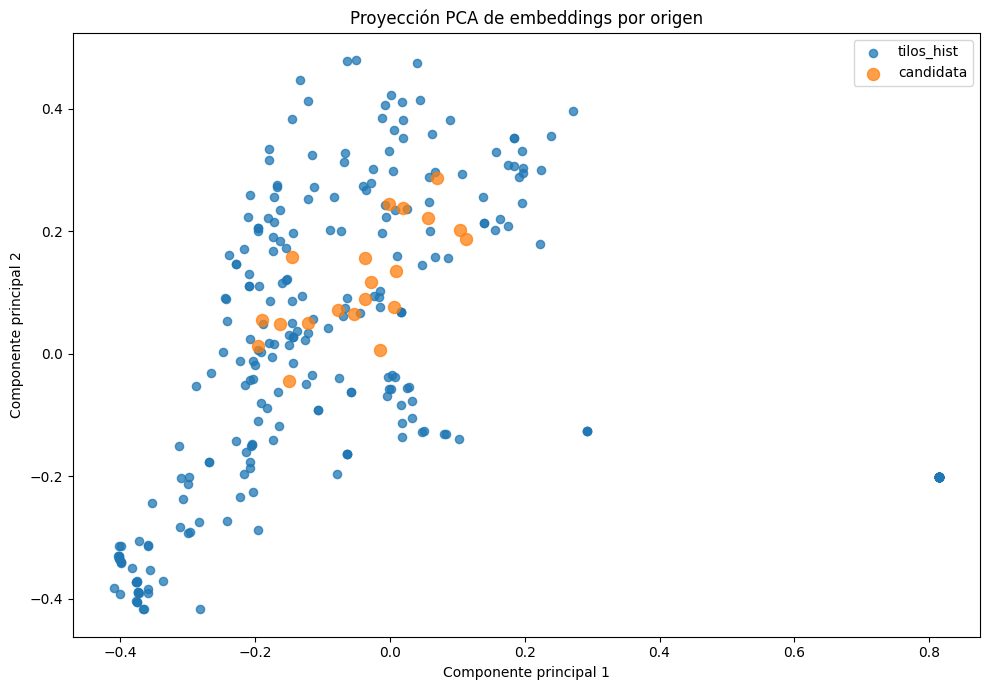

Figura guardada en: ..\data\Silver\figuras_scoring_modelos\pca_embeddings_origen_knn.png


In [39]:
# ============================================================
# 10. Visualización 2D con PCA
# ============================================================

combined_embeddings = np.vstack([emb_candidatas, emb_tilos])
combined_source = (
    ["candidata"] * len(df_candidatas)
    + ["tilos_hist"] * len(df_tilos_hist)
)

combined_ids = (
    score_df["id_licitacion_norm"].astype(str).tolist()
    + tilos_ids
)

pca = PCA(n_components=2, random_state=RANDOM_STATE)
coords = pca.fit_transform(combined_embeddings)

plot_pca_df = pd.DataFrame(
    {
        "id_licitacion_norm": combined_ids,
        "origen": combined_source,
        "pc1": coords[:, 0],
        "pc2": coords[:, 1],
    }
)

plt.figure(figsize=(10, 7))

for origin in ["tilos_hist", "candidata"]:
    subset = plot_pca_df[plot_pca_df["origen"] == origin]
    plt.scatter(
        subset["pc1"],
        subset["pc2"],
        label=origin,
        alpha=0.75,
        s=75 if origin == "candidata" else 35,
    )

plt.title("Proyección PCA de embeddings por origen")
plt.xlabel("Componente principal 1")
plt.ylabel("Componente principal 2")
plt.legend()
plt.tight_layout()

pca_path = fig_dir / "pca_embeddings_origen_knn.png"
plt.savefig(pca_path, dpi=160, bbox_inches="tight")
plt.show()

print("Figura guardada en:", pca_path)


In [40]:
# ============================================================
# 11. Ranking final
# ============================================================

cols_final_modelo = [
    "id_licitacion_norm",
    base_score_col,
    "score_embedding_top1",
    "score_embedding_top3",
    "score_embedding_top5",
    "std_embedding_top5",
    "novelty_score",
    "nivel_novedad",
    "score_final_knn_0_100",
    "nivel_score_final_knn",
    "diagnostico_semantico",
    "id_tilos_embedding_top1",
    "nombre_tilos_embedding_top1",
    "extracto_tilos_embedding_top1",
    "ids_tilos_embedding_top3",
    "ids_tilos_embedding_top5",
]

if "nombre_licitacion" in score_df.columns:
    cols_final_modelo.insert(0, "nombre_licitacion")

cols_final_modelo = [
    col for col in cols_final_modelo
    if col in score_df.columns
]

ranking_modelo_df = (
    score_df[cols_final_modelo]
    .sort_values("score_final_knn_0_100", ascending=False)
    .reset_index(drop=True)
)

numeric_cols = ranking_modelo_df.select_dtypes(include="number").columns
ranking_modelo_df[numeric_cols] = ranking_modelo_df[numeric_cols].round(3)

print("Ranking final con score base + kNN semántico:")
display(ranking_modelo_df.head(20))


Ranking final con score base + kNN semántico:


,nombre_licitacion,id_licitacion_norm,score_final_0_100,score_embedding_top1,score_embedding_top3,score_embedding_top5,std_embedding_top5,novelty_score,nivel_novedad,score_final_knn_0_100,nivel_score_final_knn,diagnostico_semantico,id_tilos_embedding_top1,nombre_tilos_embedding_top1,extracto_tilos_embedding_top1,ids_tilos_embedding_top3,ids_tilos_embedding_top5
0,P.A.S.A. 44/2023 servicio para la realización de pruebas de diagnóstico oftalmológico...,94a81b068981bfd1,70.881,0.705,0.702,0.701,0.002,0.298,Novedad media,70.665,Alta,Alta similitud y vecinos consistentes,doc_tilos_sin_id_181,,c luis erik claveria neurologo s n 40002 segovia p a g i n a 1 2 resolucion del gerente de asistencia sanitaria de s egovia de aprobacion del expediente para servicio realizaci...,"doc_tilos_sin_id_181, doc_tilos_sin_id_177, doc_tilos_sin_id_172","doc_tilos_sin_id_181, doc_tilos_sin_id_177, doc_tilos_sin_id_172, doc_tilos_sin_id_65, doc_tilos_sin_id_178"
1,Contrato de servicio de prevención ajeno en las especialidades de vigilancia de la sa...,a7cdeece28ca4b5a,72.827,0.665,0.643,0.635,0.016,0.357,Novedad media,70.268,Alta,Revisar con score base,6301-631-1-2024-14896,El contrato tiene por objeto la realización de procedimientos quirúrgicos y procedimientos diagnósticos para pacientes con derecho a prestación de asistencia sanitaria pública ...,18 si 6301 631 1 2024 14896 85111100 servicios hospitalarios de cirugia 85121200 servicios de medicos especialistas 2024 09 09 00 00 00 el contrato tiene por objeto la realizac...,"6301-631-1-2024-14896, doc_tilos_sin_id_104, doc_tilos_sin_id_111","6301-631-1-2024-14896, doc_tilos_sin_id_104, doc_tilos_sin_id_111, doc_tilos_sin_id_173, doc_tilos_sin_id_150"
2,P.A.S.A. 8/2024. Servicio para la realización de pruebas de diagnóstico oftalmológico...,2c18e78f636b0802,72.189,0.669,0.658,0.650,0.011,0.342,Novedad media,70.266,Alta,Revisar con score base,cs-2022_4002_0004,servicio de asistencia sanitaria especializada en pruebas de diagnóstico por imagen en régimen ambulatorio en la localidad de Segovia.,8 cs 2022 4002 0004 2022 09 16 00 00 00 servicio de asistencia sanitaria especializada en pruebas de diagnostico por imagen en regimen ambulatorio en la localidad de segovia se...,"cs-2022_4002_0004, doc_tilos_sin_id_181, doc_tilos_sin_id_177","cs-2022_4002_0004, doc_tilos_sin_id_181, doc_tilos_sin_id_177, doc_tilos_sin_id_65, doc_tilos_sin_id_172"
3,"Servicio de vigilancia de la salud de Radio Televisión Madrid, S.A.U.",45c562700448b4d5,69.495,0.660,0.657,0.652,0.007,0.343,Novedad media,68.350,Alta,Revisar con score base,doc_tilos_sin_id_93,,contacto telefono 034 914188364 fax 034 915564904 correo electronico contrataciones umivaleactiva es direccion postal paseo de la castellana 135 28046 madrid espana es300 anunc...,"doc_tilos_sin_id_93, doc_tilos_sin_id_131, doc_tilos_sin_id_94","doc_tilos_sin_id_93, doc_tilos_sin_id_131, doc_tilos_sin_id_94, doc_tilos_sin_id_136, doc_tilos_sin_id_137"
4,Servicios de especialidad de medicina del trabajo con un servicio de prevención ajeno...,52b45b5b3037f962,65.769,0.755,0.729,0.715,0.023,0.271,Novedad media,67.908,Alta,"Alta similitud, pero vecinos dispersos",doc_tilos_sin_id_100,,centros sanitarios 1 1 informe de insuficiencia de medios solicitud no 2023 0183000273 objeto contrato de servicios de asistencia ambulatoria y fisioterapia en centro ambulator...,"doc_tilos_sin_id_100, lict_99_139_2021_0127, lict_99_139_2022_0206","doc_tilos_sin_id_100, lict_99_139_2021_0127, lict_99_139_2022_0206, doc_tilos_sin_id_60, doc_tilos_sin_id_148"
5,Servicio de realización de Resonancias Magnéticas para el Servicio de Psiquiatría del...,1f3087dbf11096cb,65.101,0.708,0.700,0.694,0.010,0.300,Novedad media,66.579,Alta,Revisar con score base,doc_tilos_sin_id_87,,029 2022 0605 avda tibidabo no 17 19 08022 barcelona pagina 1 de 53 pliego de condiciones particulares que ha de regir la contratacion mediante licitacion publica procedimiento...,"doc_tilos_sin_id_87, 2020016585, doc_tilos_sin_id_7

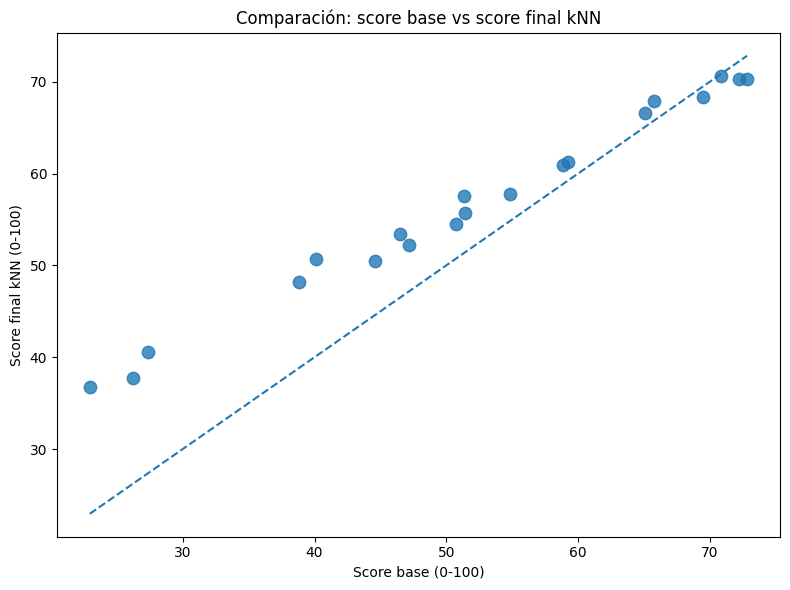

Figura guardada en: ..\data\Silver\figuras_scoring_modelos\score_base_vs_score_final_knn.png


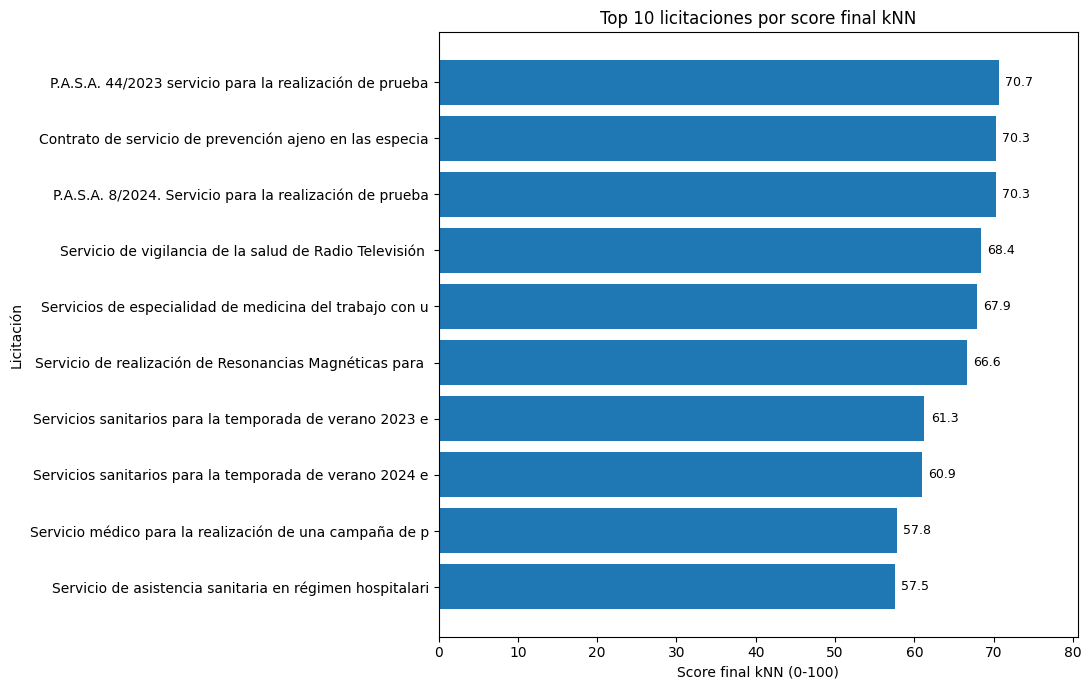

Figura guardada en: ..\data\Silver\figuras_scoring_modelos\top10_score_final_knn.png


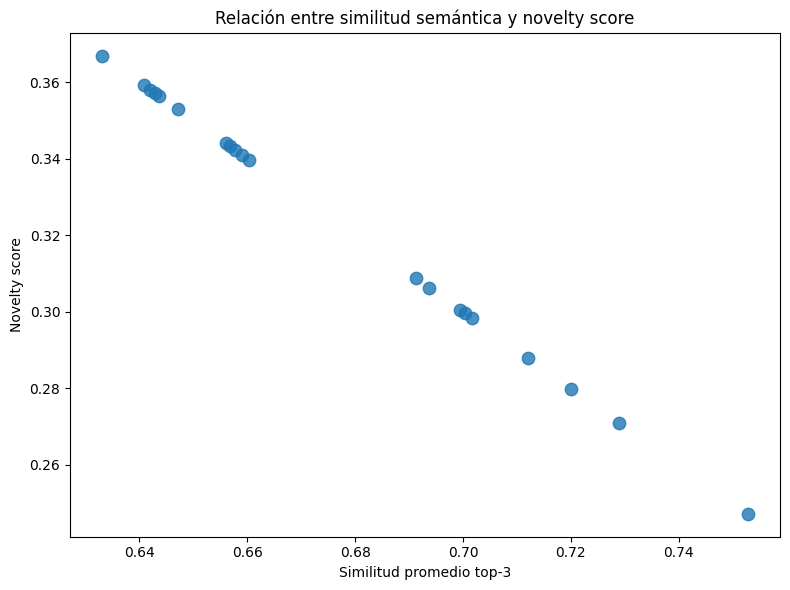

Figura guardada en: ..\data\Silver\figuras_scoring_modelos\similitud_vs_novelty_knn.png


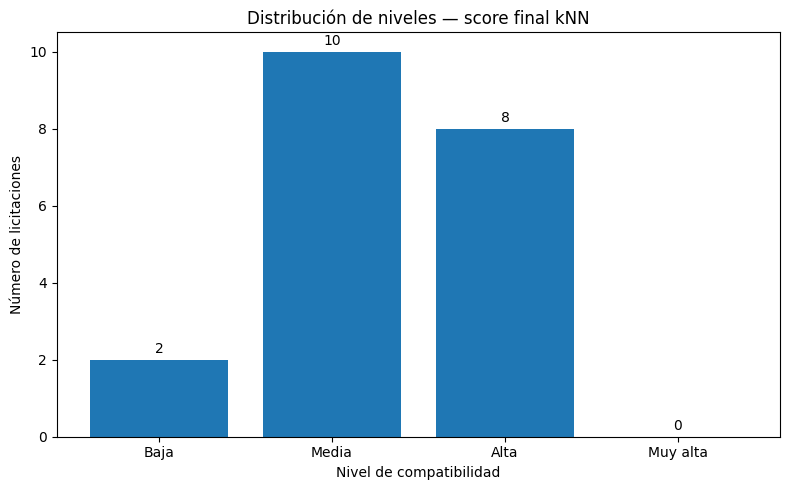

Figura guardada en: ..\data\Silver\figuras_scoring_modelos\niveles_score_final_knn.png


In [41]:
# ============================================================
# 12. Gráficas finales
# ============================================================

# ---------- Gráfica 1: score base vs score final kNN ----------
plot_df = comparison_df.copy()

plt.figure(figsize=(8, 6))
plt.scatter(
    plot_df[base_score_col],
    plot_df["score_final_knn_0_100"],
    alpha=0.8,
    s=80,
)

min_val = min(plot_df[base_score_col].min(), plot_df["score_final_knn_0_100"].min())
max_val = max(plot_df[base_score_col].max(), plot_df["score_final_knn_0_100"].max())
plt.plot([min_val, max_val], [min_val, max_val], linestyle="--")

plt.title("Comparación: score base vs score final kNN")
plt.xlabel("Score base (0-100)")
plt.ylabel("Score final kNN (0-100)")
plt.tight_layout()

fig_path = fig_dir / "score_base_vs_score_final_knn.png"
plt.savefig(fig_path, dpi=160, bbox_inches="tight")
plt.show()
print("Figura guardada en:", fig_path)

# ---------- Gráfica 2: top 10 por score final ----------
if "nombre_licitacion" in score_df.columns:
    label_col = "nombre_licitacion"
else:
    label_col = "id_licitacion_norm"

top_plot = (
    score_df
    .sort_values("score_final_knn_0_100", ascending=False)
    .head(10)
    .copy()
)

top_plot["label_plot"] = top_plot[label_col].astype(str).str.slice(0, 55)
top_plot = top_plot.sort_values("score_final_knn_0_100", ascending=True)

plt.figure(figsize=(11, 7))
bars = plt.barh(
    top_plot["label_plot"],
    top_plot["score_final_knn_0_100"],
)

for bar in bars:
    width = bar.get_width()
    plt.text(
        width + 0.8,
        bar.get_y() + bar.get_height() / 2,
        f"{width:.1f}",
        va="center",
        fontsize=9,
    )

plt.title("Top 10 licitaciones por score final kNN")
plt.xlabel("Score final kNN (0-100)")
plt.ylabel("Licitación")
plt.xlim(0, max(top_plot["score_final_knn_0_100"]) + 10)
plt.tight_layout()

fig_path = fig_dir / "top10_score_final_knn.png"
plt.savefig(fig_path, dpi=160, bbox_inches="tight")
plt.show()
print("Figura guardada en:", fig_path)

# ---------- Gráfica 3: similitud semántica vs novedad ----------
plt.figure(figsize=(8, 6))
plt.scatter(
    score_df["score_embedding_top3"],
    score_df["novelty_score"],
    alpha=0.8,
    s=80,
)

plt.title("Relación entre similitud semántica y novelty score")
plt.xlabel("Similitud promedio top-3")
plt.ylabel("Novelty score")
plt.tight_layout()

fig_path = fig_dir / "similitud_vs_novelty_knn.png"
plt.savefig(fig_path, dpi=160, bbox_inches="tight")
plt.show()
print("Figura guardada en:", fig_path)

# ---------- Gráfica 4: distribución por nivel final ----------
nivel_counts = (
    score_df["nivel_score_final_knn"]
    .value_counts()
    .reindex(["Baja", "Media", "Alta", "Muy alta"], fill_value=0)
)

plt.figure(figsize=(8, 5))
bars = plt.bar(nivel_counts.index, nivel_counts.values)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + 0.1,
        f"{int(height)}",
        ha="center",
        va="bottom",
        fontsize=10,
    )

plt.title("Distribución de niveles — score final kNN")
plt.xlabel("Nivel de compatibilidad")
plt.ylabel("Número de licitaciones")
plt.tight_layout()

fig_path = fig_dir / "niveles_score_final_knn.png"
plt.savefig(fig_path, dpi=160, bbox_inches="tight")
plt.show()
print("Figura guardada en:", fig_path)


In [42]:
# ============================================================
# 13. Exportación de resultados
# ============================================================

output_excel = out_dir / "scoring_knn_semantico_resultados.xlsx"
output_parquet = out_dir / "scoring_knn_semantico_resultados.parquet"

with pd.ExcelWriter(output_excel, engine="openpyxl") as writer:
    ranking_modelo_df.to_excel(writer, sheet_name="ranking_final_knn", index=False)
    comparison_df[cols_comparison].to_excel(writer, sheet_name="comparacion_scores", index=False)
    vecinos_knn_df.to_excel(writer, sheet_name="vecinos_top_k", index=False)
    diagnostico_knn.to_excel(writer, sheet_name="diagnostico_knn", index=False)

score_df.to_parquet(output_parquet, index=False)

print("Excel exportado:", output_excel.resolve())
print("Parquet exportado:", output_parquet.resolve())


Excel exportado: C:\Users\Usuario\TFM\TFM_scraping_contratacion_estado\data\Silver\outputs_scoring_modelos_knn_entrega\scoring_knn_semantico_resultados.xlsx
Parquet exportado: C:\Users\Usuario\TFM\TFM_scraping_contratacion_estado\data\Silver\outputs_scoring_modelos_knn_entrega\scoring_knn_semantico_resultados.parquet


## 14. Conclusión metodológica para la entrega

El modelo final no usa clustering. El clustering fue descartado porque no produjo agrupamientos temáticos útiles para las licitaciones candidatas.

La versión final se basa en:

1. **Score base interpretable:** integra similitud textual, actividad contractual, históricos, evidencia documental e importe.
2. **Embeddings multilingües:** representan cada licitación como vector semántico.
3. **kNN semántico:** recupera históricos similares de Los Tilos para cada candidata.
4. **Novelty score:** mide distancia semántica frente al histórico; se usa para lectura interpretativa, no como variable independiente adicional.
5. **Ranking final:** combina score base y similitud semántica top-3.

El resultado debe interpretarse como un sistema de apoyo a la decisión. Las licitaciones con mayor score son candidatas prioritarias para revisión manual, no adjudicaciones garantizadas.


## 15. Limitaciones y trabajo futuro

- El modelo no estima probabilidad de ganar una licitación.
- La ponderación 70/30 es metodológica e interpretable, pero puede calibrarse con etiquetas futuras si se registra retrospectivamente qué licitaciones fueron revisadas, aceptadas o descartadas.
- El score semántico depende de la calidad del texto extraído desde HTML, PDFs y documentos asociados.
- Los registros históricos sin identificador explícito se mantienen, pero se incluye un extracto textual para mejorar la trazabilidad.
- Con más datos históricos etiquetados, el siguiente paso natural sería evaluar modelos supervisados o aprendizaje de ranking.
